<a href="https://colab.research.google.com/github/dyarparvar/Accelerating-Clinical-Codelist-Generation-for-NICE-using-AI/blob/main/Clinical_Codelist_Generation_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💡 Project Overview & Business Context

**The Business Problem and its Significance:**

The National Institute for Health and Care Excellence (NICE) requires highly accurate, consistent, and auditable clinical codelists, typically SNOMED CT codes, to identify patient populations for healthcare research and quality indicators. Currently, this process is manual, time-consuming, inconsistent across analysts, difficult to audit, and prone to obsolescence due to terminology changes. This inefficiency hinders timely and robust healthcare research.

**How this Project Aims to Provide a Meaningful Solution for NICE:**

Our project introduces an automated, Agentic Retrieval-Augmented Generation (RAG) pipeline as an AI co-pilot for clinical analysts. Its primary goal is to streamline codelist creation by enhancing efficiency, consistency, accuracy, and adaptability to evolving terminologies, addressing the shortcomings of the manual process.

**Currently Available Solutions and Our Value Proposition:**

Existing methods are limited to manual expert curation, basic keyword searches, or rudimentary rule-based systems. Our solution offers significant advantages:

* Iteratively refines searches, mimicking human expert thought.
* Combines keyword and semantic search for comprehensive results.
*Leverages SNOMED CT's taxonomy to broaden searches intelligently.
* Provides granular relevance scores, clinical justifications, and confidence levels for human review.
* Ensures data governance, security, transparency, and reproducibility crucial for NHS data.

In essence, our solution transforms codelist generation into an efficient, consistent, and intelligent process, significantly empowering NICE's clinical analysts.

## Suggested Solution

We built an Agentic Retrieval-Augmented Generation (RAG) pipeline that acts as an AI co-pilot for clinical analysts. Given a research question, the system:

1. **Classifies** the query type (`diagnosis`, `laboratory_test`, `medication`, `procedure`, `composite`) using a lightweight router.
2. **Reasons** iteratively through the research question, decomposing it into targeted sub-queries using a ReAct (Reason + Act) loop.
3. **Retrieves** relevant clusters from a purpose-built knowledge base - the NHS PCD Reference Set enriched with SNOMED CT metadata - using hybrid sparse-dense retrieval.
4. **Generates** a justified, structured codelist, assigning each code a confidence flag (`include`, `uncertain`, `flag_for_review`) for human specialist review.

The system is fully local, open-weight, and audit-ready, satisfying NICE's data governance requirements.

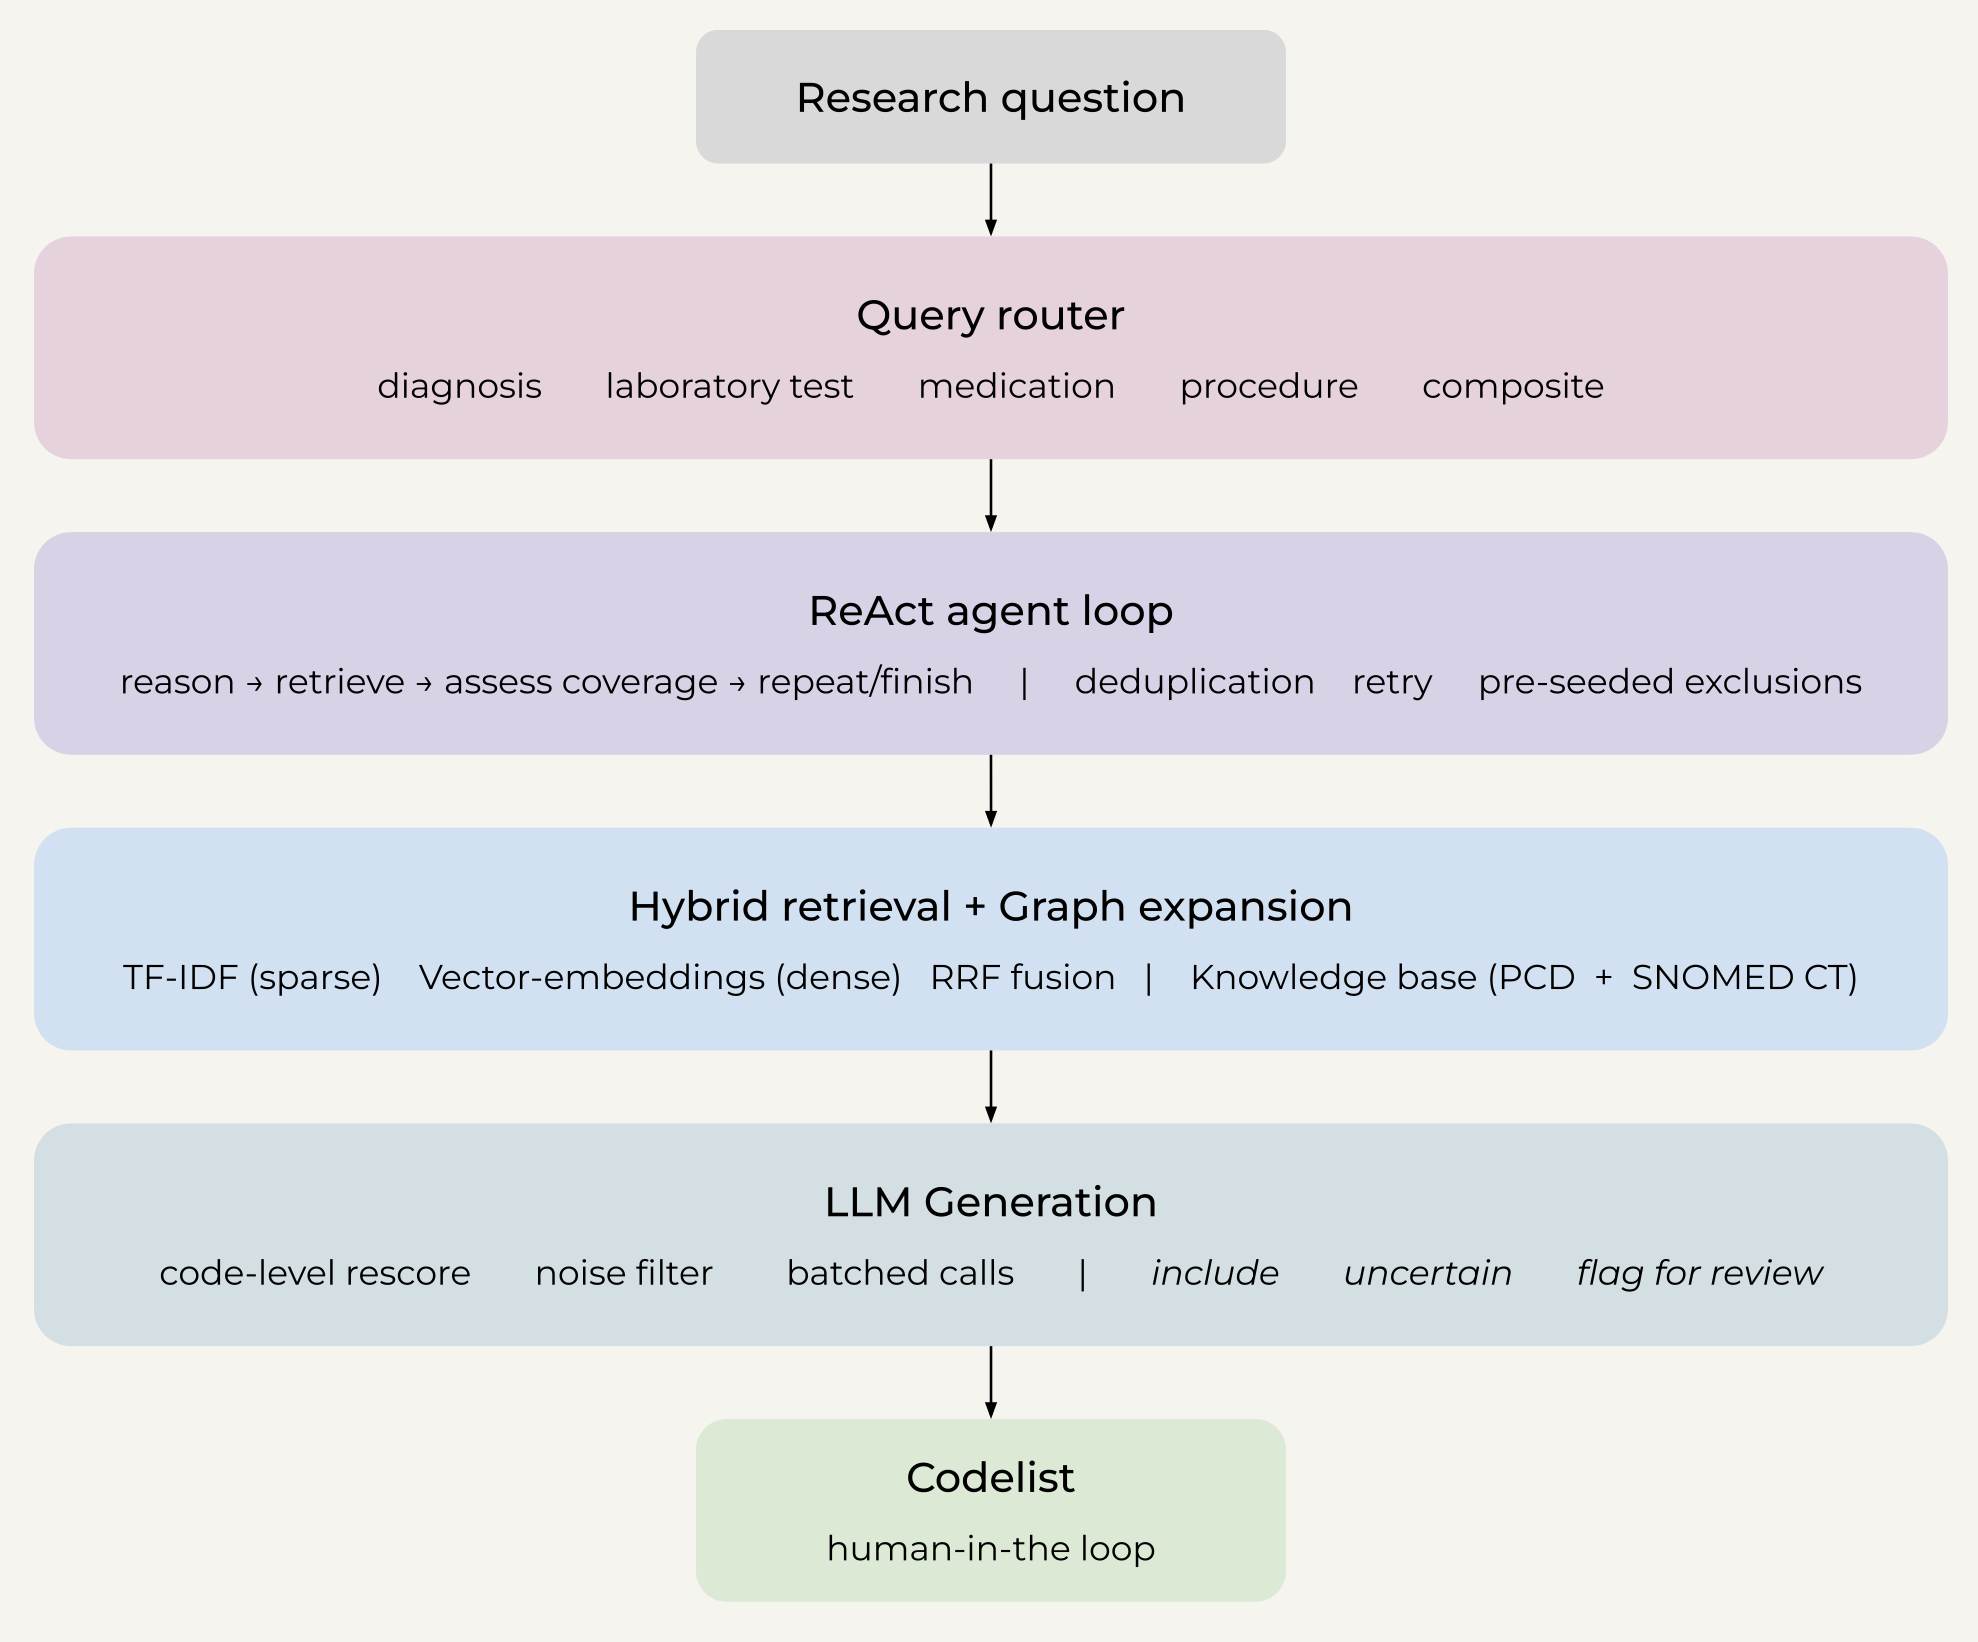

# 📌 Setup
The notebook is structured to be self-contained and reproducible — one could clone the repo, run top to bottom, and get the same codelist every time.

Setting up the notebook environment:
- installing and importing the required libraries
- configuring formatting, styles, and display options
- suppressing warnings to keep outputs clean

All dependencies are pinned in `requirements.txt` to ensure reproducibility across runs.

In [ ]:
# --- Clone the GitHub repo and set identity to ensure traceability ---
import os
from getpass import getpass


# Change to content directory
os.chdir('/content')

REPO_OWNER = "dyarparvar"
REPO_NAME = "NICE_Employer_Project"

user_email = "d.yarparvar@email.com" # Replace with your GitHub email
user_name = "dyarparvar"        # Replace with your GitHub username
os.system(f"git config --global user.email '{user_email}'")
os.system(f"git config --global user.name '{user_name}'")


token = getpass("Enter your GitHub token: ")

repo_url = f"https://{token}@github.com/{REPO_OWNER}/{REPO_NAME}.git"

!git clone {repo_url}


In [ ]:
# Navigate to the repo
%cd /content/NICE_Employer_Project/
!git status
# Set the parent directory to the repo root directory
PARENT_DIR = os.getcwd()
print(f"\n Parent directory: {PARENT_DIR}")

In [ ]:
# # Branching setup
# BRANCH_NAME = "improved-pipeline" # change this your repo name
# current_branch = !git rev-parse --abbrev-ref HEAD
# if current_branch[0] == BRANCH_NAME:
#   print(f"Already on branch: {BRANCH_NAME}")
# else:
#   !git checkout -b {BRANCH_NAME}
#   !git push -u origin {BRANCH_NAME}
#   print(f"Branch '{BRANCH_NAME}' created and synced with GitHub.")

In [ ]:
# Branching setup
BRANCH_NAME = "improved-pipeline" # change this your repo name
!git checkout improved-pipeline

In [ ]:
# Set the merge strategy & pull
!git config --global pull.rebase false
!git pull origin {BRANCH_NAME}

In [ ]:
# !git add improved_GitHub_NICE_Employer_Project.ipynb
# !git commit -m "Updated Notebook"
# !git push origin improved-pipeline

In [ ]:
# Define the data directory
DATA_DIR = PARENT_DIR + "/data"
print(f"\n Data directory: {DATA_DIR}")

# Define the results directory
RESULTS_DIR = PARENT_DIR + "/results"
print(f"\n Results directory: {RESULTS_DIR}")

# Define the embeddings directory
EMBDNG_DIR = RESULTS_DIR + "/embeddings"
print(f"\n Embeddings directory: {EMBDNG_DIR}")

# Define the models directory
MODELS_DIR = RESULTS_DIR + "/models"
print(f"\n Models directory: {MODELS_DIR}")

In [ ]:
# --- Mount the drive (for datasets that are large) ---
from google.colab import drive
# Mount the drive
drive.mount('/content/drive')
DRIVE_DIR = '/content/drive/My Drive/Career Accelerator/Employer_Project/GitHub'
print(f"\n Drive directory: {DRIVE_DIR}")
# Define the data directory on the Drive
DRIVE_DATA_DIR = '/content/drive/My Drive/Career Accelerator/Employer_Project/GitHub/data'
print(f"\n Data directory on drive: {DRIVE_DATA_DIR}")

In [ ]:
# --- Terminal in Colab ---
!apt-get update --quiet -qq
!apt-get install --quiet -y zstd
!pip install --quiet colab-xterm

In [ ]:
%load_ext colabxterm
%xterm

In the terminal, install and launch the local LLM inference server:

1. **Download Ollama** ([Ollama](https://ollama.com/download/linux)):  
   `curl -fsSL https://ollama.com/install.sh | sh`

2. **Start the server** in the background:  
   `ollama serve > /dev/null 2>&1 &`

3. **Pull the model** — Phi-4 (14B, 9.1 GB):  
   `ollama run phi4`  
   

4. Exit the interactive shell: `/bye`

5. Inspect model metadata: `ollama show phi4`

*Why run locally?* NICE operates under strict NHS data governance. Running inference locally on the Colab GPU ensures no data leaves the compute environment. This is consistent with NHS Digital data security standards (DSP Toolkit).

In [ ]:
# --- Ollama ---
!pip install --quiet ollama
import ollama

from transformers import AutoTokenizer

In [ ]:
# --- SentenceTransformer ---
!pip install --quiet sentence-transformers

from sentence_transformers import SentenceTransformer

In [ ]:
# --- Embedding ---
!pip install --quiet sentence-transformers

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# --- Libraries ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px

import random
from umap import UMAP
import torch
import warnings


import string
import re

import math

import json
import yaml

import hashlib
from datetime import datetime

In [ ]:
# --- Display Options for Pandas ---
# Show all columns and rows in a DataFrame
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# Format floats to consistent decimal places
pd.set_option("display.float_format", lambda x: f'{x:.2f}')



# --- Print Options for NumPy ---
# Suppress the scientific notation and set a consistent number of digits
np.set_printoptions(suppress=True, precision=2)



# --- Styling for Matplotlib and Seaborn ---
# A clean, whitegrid style and a categorical Color Brewer palette
sns.set_theme(style="ticks", palette="Set2")
# sns.despine()

# Font size and styling for the notebook
sns.set_context("notebook", font_scale=0.8)



# --- Warnings ---
# Suppress warnings to keep the output clean
warnings.filterwarnings("ignore")
# Ignore warnings to keep the output clean
warnings.filterwarnings("ignore", category=DeprecationWarning)

Visualising the chosen colour palettes for reference — applied consistently across all plots in this notebook.

`Set2` is a colourblind-friendly categorical palette (Brewer, 2003), chosen to ensure figures are accessible in both print and digital formats.

In [ ]:
palette_set2 = sns.color_palette("Set2")
palette_set2

In [ ]:
# # Get all dependencies
# !pip freeze > /content/NICE_Employer_Project/requirements.txt

In [ ]:
# # Push to Github
# !git add requirements.txt
# !git commit -m "Update dependencies"

# !git push origin improved-pipeline

# 📌 Configuration

All runtime parameters are centralised in a single `CONFIGURATION` dictionary. This is the single source of truth for the pipeline.

*Key design choice:* centralising configuration makes the pipeline reproducible and auditable. Every run can be traced back to an exact configuration snapshot.

In [ ]:
# CONFIGURATION = {
#     "randomness_strategy": {
#         "seed": 42
#     },


#     "data": {
#         "source": "20250912_PCD_Refset_Content",
#         "paths": {
#             "pcd_input": f"{DRIVE_DATA_DIR}/raw/20250912_PCD_Refset_Content.txt",
#             "snomed_desc_input": f"{DRIVE_DATA_DIR}/raw/sct2_Description_MONOSnapshot-en_GB_20250924.txt",
#             "snomed_rel_input": f"{DRIVE_DATA_DIR}/raw/sct2_Relationship_MONOSnapshot_GB_20250924.txt",
#             "snomed_code_usage": f"{DRIVE_DATA_DIR}/usage/SNOMED_code_usage_2024-25.txt",
#         },
#         "source_label": {
#             "pcd_input": "NHS Primary Care Domain Reference Set (September 2025)",
#             "snomed_input": "SnomedCT Monolith RF2 PRODUCTION (September 2025) T120000Z",
#         },
#         "chunking": {
#             "max_chars": 28672,   # considering a safety buffer of ~1000 tokens before hitting the absolute ceiling of the embedding model
#             "codes_per_subchunk": 50,
#             "relationships": {
#                 "116680003": "is_a",
#                 "363698007": "finding_site",
#                 "363704007": "procedure_site",
#                 "246075003": "causative_agent",
#                 "363714003": "investigation",
#                 "260686004": "method",
#                 "272741003": "laterality",
#                 "127489000": "ingredient",
#                 "263502005": "course",
#                 "370135005": "pathological_process",
#                 "47429007": "associated_with",
#             },
#         },
#         "check": {
#             "keyword": "flu ",   # an example to check cluster descriptions
#             "n_preview": 10,  # number of matching clusters to print
#         },
#     },

#     "retrieval": {
#         "tf_idf": {
#             "ngram_range": (1,5), # keep n-grams up to 5 to capture multi-word clinical terms
#             "max_df": 0.85, # ignore terms that appear in >85% of chunks (too common to be distinctive)
#             "min_df": 2, # ignore terms that appear in <2 chunks (likely noise)
#             "sublinear_tf": True, # dampen the effect of very high term frequencies
#         },

#         "embedding": {
#             "model": "nomic-ai/nomic-embed-text-v1.5",
#             "backend": "sentence_transformers",
#             "batch_size": 32,
#             "progress_every": 100,  # print progress every n chunks
#             "num_ctx": 8192,        # full context window
#             "prefix": "search_document",
#             "trust_remote_code": True,
#             "device": "cuda", # "cpu",
#             "normalize_embeddings": True,
#             "show_progress_bar": False,
#         },

#         "retrieving": {
#             "model": "nomic-ai/nomic-embed-text-v1.5",
#             "backend": "sentence_transformers",
#             "batch_size": 32,
#             "progress_every": 100,  # print progress every n chunks
#             "num_ctx": 8192,        # full context window
#             "prefix": "search_query",
#             "trust_remote_code": True,
#             "device": "cuda", #"cpu",
#             "normalize_embeddings": True,
#             "show_progress_bar": False,
#             # Sparse TF-IDF cosine similarity
#             "sparse_min_score": 0.05,   # minimum score to include — cuts noise
#             "sparse_top_k": 30,     # upper bound
#             # Dense embedding cosine similarity
#             "dense_min_score": 0.60,   # minimum score to include — cuts noise
#             "dense_top_k": 30,     # upper bound
#             # Hybrid
#             "rrf_min_ratio": 0.80, # dynamic threshold to drop a candidate when score drops below min_ratio * best_score
#             "rrf_top_k": 30,
#             "rrf_k": 60,     # smoothing constant (standard value)
#         },
#         "graph_expansion": {
#             "enabled": True,
#             "expansion_top_k": 10,      # chunks per expansion query (to control noise)
#             "expansion_min_score": 0.70,  # tighter bar than primary retrieval
#             "expansion_rrf_weight": 0.5,  # downweight expansion vs seed in final merge
#         },
#         "code_rescore": {
#             "chunk_weight": 0.5,   # how much the parent cluster's RRF score contributes
#             "code_weight": 0.5,   # how much the individual code's hybrid score contributes
#             # Increase code_weight if clusters tend to be heterogeneous with many unrelated codes in one cluster.
#         },
#         "test_queries": [
#             "Patients who have cardiovascular disease.",
#         ],
#     },


#     "llm": {
#         "model": "phi4",
#         "temperature": 0,  # deterministic because clinical codelists must be reproducible
#         "num_ctx": 16384,    # full context window for the LLM
#         "num_predict": 2048,   # max tokens in response
#         "max_codes_to_llm":  200, # absolute ceiling regardless of token budget
#     },

#     "agent": {
#         "model": "phi4",
#         "temperature": 0,
#         "num_ctx": 16384,
#         "num_predict": 2048,
#         "min_rrf_score": 0.015,    # retrieval loop noise threshold (more permissive)
#         "min_blended_score": 0.15, # code-level rescore threshold before LLM batching - higher than retrieval threshold
#         "min_new_chunks": 1,  # stop if retrieval adds fewer than this
#         "max_steps": {  # dynamic ceiling driven by router complexity
#             "simple":   50,
#             "moderate": 100,
#             "complex":  200,
#             "default":  100,     # fallback if routing failed or complexity unknown
#         },
#     },

#     "query_router": {
#         "model": "phi4",
#         "temperature": 0,
#         "num_ctx": 4096,
#         "num_predict": 512,
#         "types": {
#             "diagnosis": {
#                 "primary_axes": ["is_a", "finding_site", "causative_agent",
#                                 "course", "associated_with"],
#             },
#             "laboratory_test": {
#                 "primary_axes": ["investigation", "finding_site",
#                                 "associated_with"],
#             },
#             "medication": {
#                 "primary_axes": ["ingredient", "associated_with"],
#             },
#             "procedure": {
#                 "primary_axes": ["procedure_site", "method",
#                                 "laterality", "associated_with"],
#             },
#             "composite": {
#                 "primary_axes": ["is_a", "finding_site", "investigation",
#                                 "ingredient", "associated_with"],
#             },
#         },
#     },

#     "evaluation": {
#         "benchmark_code_col": "code",
#         "benchmark_description_col": "term",
#         "normalize_embeddings": True,
#         "show_progress_bar": False,
#     },

# }

In [ ]:
# # Save the configuration as .yaml file
# with open("config.yaml", "w") as f:
#     yaml.dump(CONFIGURATION, f, default_flow_style=False, sort_keys=False)

In [ ]:
# # Push to Github
# !git add config.yaml
# !git commit -m "Update configuration file"
# !git push origin improved-pipeline

In [ ]:
# Load configuration from Github
config_path = "/content/NICE_Employer_Project/config.yaml"

with open(config_path, "r") as file:
    config = yaml.unsafe_load(file)

In [ ]:
config = dict(CONFIGURATION)

In [ ]:
# config

In [ ]:
# Data source registry for reporting and auditability
DATA_SOURCE_REGISTRY = {
    "pcd_reference_set": {
        "name": "NHS Primary Care Domain Reference Set",
        "source_label": config["data"]["source_label"]["pcd_input"],
        "path": config["data"]["paths"]["pcd_input"],
        "format": "TSV / tab-separated text",
        "licence": "NHS Digital / NICE (restricted use)",
        "role": "Base layer of clinically grouped SNOMED codes used to construct the knowledge base",
        "justification": "Chosen because it reflects real NHS primary care coding practices and provides clinically validated clusters rather than isolated codes.",
        "fields_used": [
            "Cluster_ID",
            "Cluster_description",
            "SNOMED_code",
            "SNOMED_code_description",
            "Service_and_Ruleset",
            "PCD Refset ID",
        ],
    },
    "snomed_description": {
        "name": "SNOMED CT UK Description Snapshot",
        "source_label": config["data"]["source_label"]["snomed_input"],
        "path": config["data"]["paths"]["snomed_desc_input"],
        "format": "RF2 TSV",
        "licence": "SNOMED International / NHS UK",
        "role": "Enrichment layer for preferred terms and synonyms",
        "justification": "Used to expand each SNOMED concept with synonyms and preferred terms, improving recall and handling variation in clinical language.",
        "fields_used": [
            "conceptId",
            "term",
            "active",
        ],
    },
    "snomed_relationship": {
        "name": "SNOMED CT UK Relationship Snapshot",
        "source_label": config["data"]["source_label"]["snomed_input"],
        "path": config["data"]["paths"]["snomed_rel_input"],
        "format": "RF2 TSV",
        "licence": "SNOMED International / NHS UK",
        "role": "Enrichment layer for hierarchical and clinically relevant concept relationships",
        "justification": "Used to introduce structured clinical relationships such as hierarchy, anatomy, investigation type, method, and ingredient, enabling context-aware retrieval.",
        "fields_used": [
            "sourceId",
            "destinationId",
            "typeId",
            "active",
        ],
    },
    "benchmark": {
        "name": "OpenCodelists benchmark",
        "source_label": "OpenCodelists benchmark CSV",
        "path": "OpenCodelists benchmark (see evaluation section)",
        "format": "CSV",
        "licence": "OpenSAFELY / OpenCodelists (open access)",
        "role": "Evaluation benchmark against expert-curated codelists",
        "justification": "Used as a proxy ground truth because it contains clinically validated codelists from real-world research studies.",
        "fields_used": [
            "code",
            "term",
        ],
    },
}


# 📌 Helper Functions

### Reproducibility

Fixing all random seeds across Python, NumPy, and PyTorch ensures that every run of this notebook produces identical results — a prerequisite for scientific reproducibility and for clinical defensibility of the output.

`seed = 42` is set globally via `CONFIGURATION` and applied before any stochastic operation.

In [ ]:
def set_seed(seed=42):
    # Python randomness
    random.seed(seed)
    # Python hash randomness
    os.environ["PYTHONHASHSEED"] = str(seed)
    # NumPy randomness
    np.random.seed(seed)
    # Torch and T4 GPU
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Torch deterministic operations for embedding model on GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

In [ ]:
SEED = config["randomness_strategy"]["seed"]

In [ ]:
set_seed(SEED)

### Save & Sync

`sync_work()` wraps `git add`, `commit`, `pull --rebase`, and `push` in a single call, ensuring the working branch is always up to date with the remote before pushing. This prevents merge conflicts during collaborative development.

In [ ]:
# A function to save, commit, and push everything in one go.
def sync_work(message):
    !git add .
    !git commit -m "{message}"
    !git pull --rebase origin $(git branch --show-current)
    !git push origin $(git branch --show-current)
    print("Changes successfully synced to GitHub.")

In [ ]:
# # Save & sync once a task is done
# sync_work(" ...  ")

### Release Detection

SNOMED CT and the PCD Reference Set are updated on a release cycle. If the source files change between runs, the knowledge base and all downstream embeddings must be regenerated; using stale embeddings against a new release would silently corrupt retrieval quality.

The `build_release_manifest()` function records the SHA-256 hash and file size of each source file at runtime. `compare_manifests()` diffs the current snapshot against the previously saved one and flags any file that has changed, been added, or gone missing.

In [ ]:
def print_data_source_registry(registry):
    for _, meta in registry.items():
        print("=" * 80)
        print(f"{meta['name']}")
        print("-" * 80)
        print(f"Source label : {meta['source_label']}")
        print(f"Path         : {meta['path']}")
        print(f"Format       : {meta['format']}")
        print(f"Licence      : {meta['licence']}")
        print(f"Role         : {meta['role']}")
        print(f"Justification: {meta['justification']}")
        print(f"Fields used  : {', '.join(meta['fields_used'])}")
        print()

In [ ]:
def file_sha256(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

In [ ]:
def build_release_manifest():
    tracked_files = {
        "pcd_input": config["data"]["paths"]["pcd_input"],
        "snomed_desc_input": config["data"]["paths"]["snomed_desc_input"],
        "snomed_rel_input": config["data"]["paths"]["snomed_rel_input"],
    }

    manifest = {
        "created_at": datetime.utcnow().isoformat(),
        "files": {}
    }

    for key, path in tracked_files.items():
        if not os.path.exists(path):
            manifest["files"][key] = {
                "path": path,
                "exists": False
            }
        else:
            manifest["files"][key] = {
                "path": path,
                "exists": True,
                "filename": os.path.basename(path),
                "size_bytes": os.path.getsize(path),
                "sha256": file_sha256(path),
                "modified_time": datetime.utcfromtimestamp(os.path.getmtime(path)).isoformat()
            }
    return manifest

In [ ]:
def compare_manifests(old_manifest, new_manifest):
    changes = {}

    old_files = old_manifest.get("files", {}) if old_manifest else {}
    new_files = new_manifest.get("files", {})

    for key, new_meta in new_files.items():
        old_meta = old_files.get(key)

        if old_meta is None:
            changes[key] = {"status": "new_file_tracked", "new": new_meta}
            continue

        if not old_meta.get("exists", False) and new_meta.get("exists", False):
            changes[key] = {"status": "now_exists", "new": new_meta}
            continue

        if old_meta.get("exists", False) and not new_meta.get("exists", False):
            changes[key] = {"status": "missing_now", "old": old_meta}
            continue

        if old_meta.get("sha256") != new_meta.get("sha256"):
            changes[key] = {
                "status": "changed",
                "old_filename": old_meta.get("filename"),
                "new_filename": new_meta.get("filename"),
                "old_size_bytes": old_meta.get("size_bytes"),
                "new_size_bytes": new_meta.get("size_bytes"),
                "old_sha256": old_meta.get("sha256"),
                "new_sha256": new_meta.get("sha256"),
            }
        else:
            changes[key] = {"status": "unchanged"}

    return changes

### Building Chunks

Helper functions that construct the knowledge base from the enriched PCD + SNOMED data:

- `clean_description()` — strips SNOMED semantic tags that add noise to retrieval.
- `get_filtered_synonyms()` — selects shorter, meaningfully distinct synonyms per code; long near-duplicate synonyms add tokens without retrieval benefit.
- `get_code_relationships()` — maps each code to its SNOMED relationship targets (e.g., `finding_site: Liver structure`), translating concept IDs to human-readable preferred terms.
- `build_chunk_text()` — assembles the final chunk string. Two versions are produced per chunk: `text` (full, for sparse TF-IDF) and `text_dense` (relationship-rich, for dense embedding), following dual-encoder best practice.
- `generate_chunks()` — iterates over PCD clusters and calls `build_chunk_text()`, splitting oversized clusters into sub-chunks to respect the embedding model's context window.

The SNOMED CT relationship file contains 169 unique relationship type IDs in this release. Of these, 11 axes are selected for the knowledge base (`CONFIGURATION >> data >> chunking >> relationships`) based on the SNOMED CT defined attributes most relevant to NHS primary care coding.

The full `text` (used for sparse TF-IDF) includes all 11 axes to maximise term coverage. (CONFIGURATION >> data >> chunking >> relationships)

For embedding-based retrieval, `text_dense `is restricted to the 6 axes that carry the most semantically distinctive signal — axes that describe *what* a concept is and *where/why* it occurs. The remaining axes tend to encode modifiers rather than core clinical identity.

Each of the 6 is a defined SNOMED CT attribute:

  **is_a** — subtype hierarchy; links a concept to its parent(s)

  **finding_site** — body structure affected by a clinical finding

  **causative_agent** — direct causative agent (organism, substance, or physical force)

  **ingredient** — active substance in a medicinal product

  **investigation** — investigation associated with a clinical finding

  **associated_with** — clinically relevant association without asserting causality

These six axes span the four main retrieval dimensions for clinical coding: hierarchy (is_a), anatomy (finding_site), aetiology (causative_agent, associated_with), and clinical action (investigation, ingredient).

In [ ]:
# Used by graph_expansion to decide which relationship axes to follow when expanding seed chunks
DENSE_RELATIONSHIPS = {"is_a", "finding_site", "causative_agent", "ingredient", "investigation", "associated_with"}

In [ ]:
def clean_description(text):
    # Remove SNOMED suffixes like (disorder), (finding), (procedure)
    pattern = r'\s*\((procedure|disorder|finding|situation|medicinal product|product)\)[.]?'
    return re.sub(pattern, '', text, flags=re.IGNORECASE).strip()

In [ ]:
# Extract short synonyms
def get_filtered_synonyms(snomed_code, description, synonyms_dict):
    if not synonyms_dict or snomed_code not in synonyms_dict:
        return []

    # Add short synonyms and skip synonyms that are longer than or similar to the description
    short_synonyms = sorted([
        s for s in synonyms_dict[snomed_code]
        if clean_description(s) != clean_description(description)
        and len(s) < len(description) * 0.5   # meaningfully shorter only
    ], key=len)

    return short_synonyms

In [ ]:
# Build relationship metadata for each code
def get_code_relationships(snomed_code, rel_dicts, rel_type_names, preferred_terms):
    rels = {}
    if rel_dicts:
        for rel_name in rel_type_names:
            if rel_name in rel_dicts and snomed_code in rel_dicts[rel_name]:
                target_ids = rel_dicts[rel_name][snomed_code]

                # Translate snomed_codes to preferred_terms
                if preferred_terms:
                    target_desc = [
                        clean_description(preferred_terms.get(str(t_id), str(t_id)))
                        for t_id in target_ids
                    ]
                    rels[rel_name] = target_desc
                else:
                    rels[rel_name] = target_ids

    return rels

In [ ]:
def build_preprocessing_metrics(
    pcd_data,
    snomed_desc_data,
    snomed_desc_data_active,
    snomed_rel_data,
    snomed_rel_filtered,
    synonyms_dict,
    preferred_terms,
    chunks_df,
    data_config,
):
    metrics = {
        #PCD
        "pcd_rows": int(len(pcd_data)),
        "pcd_unique_clusters": int(pcd_data["Cluster_ID"].nunique()),
        "pcd_unique_codes": int(pcd_data["SNOMED_code"].nunique()),
        "pcd_unique_rulesets": int(pcd_data["Service_and_Ruleset"].nunique()),

        #descriptions from Snomed
        "snomed_desc_rows_raw": int(len(snomed_desc_data)),
        "snomed_desc_rows_active": int(len(snomed_desc_data_active)),
        "snomed_desc_active_retention_pct": round(
            100 * len(snomed_desc_data_active) / len(snomed_desc_data), 2
        ) if len(snomed_desc_data) else 0.0,
        "snomed_unique_codes_active": int(snomed_desc_data_active["SNOMED_code"].nunique()),

        #Synonyms and preferred terms
        "preferred_term_count": int(len(preferred_terms)),
        "synonym_code_count": int(len(synonyms_dict)),
        "avg_terms_per_code": round(
            snomed_desc_data_active.groupby("SNOMED_code")["SNOMED_code_description"].nunique().mean(), 2
        ),

        #Relationships
        "snomed_rel_rows_raw": int(len(snomed_rel_data)),
        "snomed_rel_rows_filtered": int(len(snomed_rel_filtered)),
        "snomed_rel_unique_source_codes": int(snomed_rel_filtered["SNOMED_code"].nunique()),
        "snomed_rel_unique_target_codes": int(snomed_rel_filtered["target_SNOMED_code"].nunique()),
        "relationship_types_used": list(data_config["chunking"]["relationships"].values()),
        "relationship_type_count": int(len(data_config["chunking"]["relationships"])),

        #Chunking
        "chunk_count_total": int(len(chunks_df)),
        "chunk_count_standard": int((~chunks_df["is_subchunk"]).sum()),
        "chunk_count_subchunks": int(chunks_df["is_subchunk"].sum()),
        "chunk_max_text_length": int(chunks_df["text_length"].max()),
        "chunk_mean_text_length": round(float(chunks_df["text_length"].mean()), 2),
        "chunk_median_code_count": round(float(chunks_df["code_count"].median()), 2),
        "chunk_max_code_count": int(chunks_df["code_count"].max()),

        #Configurations
        "codes_per_subchunk_config": int(data_config["chunking"]["codes_per_subchunk"]),
        "chunk_char_limit_config": int(data_config["chunking"]["max_chars"]),
    }

    return metrics



In [ ]:
def build_chunk_text(cluster_id, cluster_desc, services, codes_enriched,
                     part=None, total_parts=None,
                     synonyms_dict=None, rel_dicts=None):
    # Keep clinical context attached to every code — important for retrieval
    # part and total_parts are only set for sub-chunks of oversized clusters
    services_str = " | ".join(sorted(set(services)))

    # Add part label to cluster ID if this is a sub-chunk
    if part is not None:
        id_line = f"Cluster ID: {cluster_id} (part {part} of {total_parts})"
    else:
        id_line = f"Cluster ID: {cluster_id}"


    lines = [
        id_line,
        f" {cluster_desc};",
        f" {services_str};",
        "",
    ]

    for code in codes_enriched:
        snomed_code = code["snomed_code"]
        description = code["description"]
        code_line = f"| {snomed_code}: {description}"

        enrichments = []

        # Add synonyms
        syns = code.get("synonyms", [])
        if syns:
            enrichments.append(f"; Synonym: {'; '.join(syns)}")


        # Add relationship
        rels = code.get("relationships", {})
        for rel_name, targets in rels.items():
            # Format nicely
            formatted_rel_name = rel_name.replace("_", " ").capitalize()
            enrichments.append(f"; {formatted_rel_name}: {', '.join(targets)}")

        if enrichments:
            code_line += " ".join(enrichments)

        lines.append(code_line)

    text = " ".join(lines)

    clean_text = clean_description(text)

    return clean_text

In [ ]:
def generate_chunks(pcd_data, config, preferred_terms,
                    synonyms_dict=None, rel_dicts=None): # data_config
    chunks = []
    n_split = 0   # count of clusters that were split
    source_label = list(config["source_label"].values())
    max_chars = config["chunking"]["max_chars"]
    codes_per_subchunk = config["chunking"]["codes_per_subchunk"]

    # Relationship type names
    rel_type_names = list(config["chunking"].get("relationships", {}).values())

    for cluster_id, group in pcd_data.groupby("Cluster_ID"):
        cluster_desc = group["Cluster_description"].iloc[0]

        # Collect unique codes — a code may appear in multiple service rows
        codes_df = (
            group[["SNOMED_code", "SNOMED_code_description"]]
            .drop_duplicates(subset=["SNOMED_code"])
            .sort_values("SNOMED_code")
        )

        codes = [
            {"snomed_code": row["SNOMED_code"], "description": row["SNOMED_code_description"]}
            for _, row in codes_df.iterrows()
        ]

        services = sorted(group["Service_and_Ruleset"].unique().tolist())
        refset_ids = sorted(group["PCD Refset ID"].unique().tolist())



        # Enrich codes with relationship metadata
        codes_enriched = [
            {
                **code,
                "relationships": get_code_relationships(code["snomed_code"], rel_dicts, rel_type_names, preferred_terms),
                "synonyms": get_filtered_synonyms(code["snomed_code"], code["description"], synonyms_dict),
            }
            for code in codes
        ]



        # Build the full chunk first to check its size
        full_text = build_chunk_text(
            cluster_id, cluster_desc, services, codes_enriched
        )


        # Build dense text with restricted relationships only
        codes_for_dense = [
            {**code, "relationships": {k: v for k, v in code["relationships"].items()
                                       if k in DENSE_RELATIONSHIPS}}
            for code in codes_enriched
        ]
        full_text_dense = build_chunk_text(cluster_id, cluster_desc, services, codes_for_dense)



        if len(full_text) <= max_chars:
            # Chunk is within limit — keep as a single chunk
            chunks.append({
                "chunk_id": cluster_id,
                "cluster_id": cluster_id,
                "cluster_desc": cluster_desc,
                "part": None,
                "total_parts": None,
                "is_subchunk": False,
                "services": services,
                "refset_ids": refset_ids,
                "codes": codes_enriched,
                "code_count": len(codes),
                "text": full_text,
                "text_dense": full_text_dense,
                "source": source_label,
            })

        else:
            # Split the oversized chunks into sub-chunks
            n_split += 1
            total_parts = math.ceil(len(codes) / codes_per_subchunk)

            for part, start in enumerate(range(0, len(codes), codes_per_subchunk), start=1):
                sub_codes = codes[start : start + codes_per_subchunk]


                # Enrich codes with relationship metadata
                sub_codes_enriched = [
                    {
                        **code,
                        "relationships": get_code_relationships(code["snomed_code"], rel_dicts, rel_type_names, preferred_terms),
                        "synonyms": get_filtered_synonyms(code["snomed_code"], code["description"], synonyms_dict),
                    }
                    for code in sub_codes
                ]

                sub_text = build_chunk_text(
                    cluster_id, cluster_desc, services, sub_codes_enriched,
                    part=part, total_parts=total_parts,
                )

                # Build dense text for sub-chunkNEW
                sub_codes_for_dense = [
                    {**code, "relationships": {k: v for k, v in code["relationships"].items()
                                               if k in DENSE_RELATIONSHIPS}}
                    for code in sub_codes_enriched
                ]
                sub_text_dense = build_chunk_text(cluster_id, cluster_desc, services,
                                                   sub_codes_for_dense, part=part, total_parts=total_parts)


                chunks.append({
                    # chunk_id includes part number so each sub-chunk is uniquely identifiable
                    "chunk_id": f"{cluster_id}_part{part}",
                    "cluster_id": cluster_id,
                    "cluster_desc": cluster_desc,
                    "part": part,
                    "total_parts": total_parts,
                    "is_subchunk": True,
                    "services": services,
                    "refset_ids": refset_ids,
                    "codes": sub_codes_enriched,
                    "code_count": len(sub_codes),
                    "text": sub_text,
                    "text_dense": sub_text_dense,
                    "source": source_label,
                })

    print(f"Clusters split into sub-chunks: {n_split}")
    return chunks

### Retrieval System

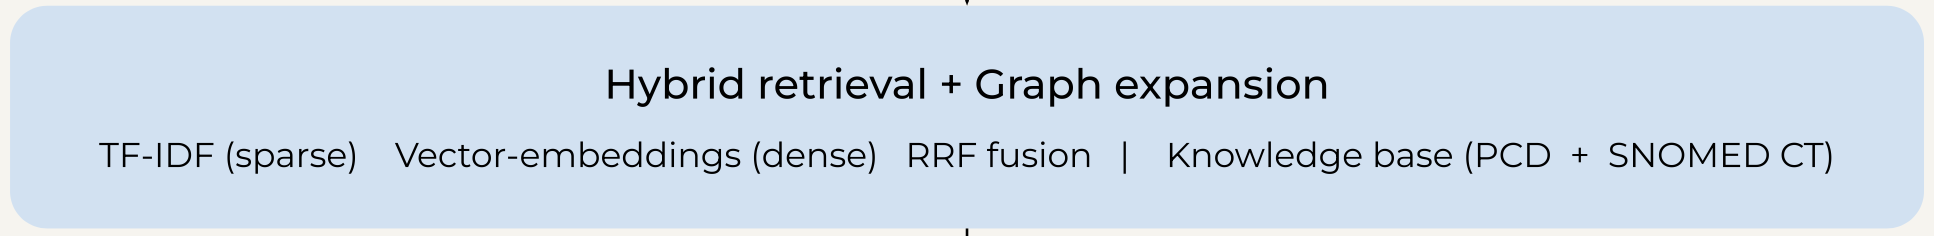

The retrieval layer implements three complementary strategies, each available as a standalone function:

- `retrieve_sparse()` — TF-IDF cosine similarity against all chunk texts. Fast and exact-match-strong.
- `retrieve_dense()` — embedding cosine similarity using `nomic-embed-text-v1.5`. Captures semantic synonymy.
- `retrieve_hybrid()` — Reciprocal Rank Fusion (RRF) over the sparse and dense ranked lists.
- `retrieve_with_graph_expansion()` — extends the hybrid result by following SNOMED relationships (e.g., `finding_site`, `causative_agent`) to retrieve semantically adjacent clusters that the query alone may not surface.


| Method | Strength | Limitation |
|--------|----------|------------|
| **Sparse (TF-IDF)** | Exact keyword match; fast and deterministic | Misses synonyms and paraphrases |
| **Dense (Embeddings)** | Captures semantic similarity; handles synonyms | Can miss rare, precise clinical terms |
| **Hybrid (RRF)** | Combines both signals; robust across query types | Slightly higher computational cost |



We use **Reciprocal Rank Fusion (RRF)** to combine the rankings — rather than combining raw scores (which are on incomparable scales), we combine ranks. This is simple, well-established, and works well in practice.

RRF combines sparse and dense rankings.
A chunk scores highly if it ranks well in either or both lists.

$ RRF score = 1/(k + sparse rank) + 1/(k + dense rank) $

$ k=60 $ is a standard smoothing constant.

This avoids the problem of TF-IDF and cosine similarity scores being on incomparable scales as ranks are always comparable.

In [ ]:
def retrieve_sparse(research_question, config, chunk_lookup, tfidf_vectorizer, tfidf_matrix): #retrieval_config["retrieving"]
    # Embed the research_question using the same TF-IDF vocabulary
    research_question_vec = tfidf_vectorizer.transform([research_question])

    # Cosine similarity between research_question and all chunks
    scores = cosine_similarity(research_question_vec, tfidf_matrix).flatten()

    # Return top_k chunk indices ranked by score (highest first)
    top_k = config["sparse_top_k"]
    min_score = config["sparse_min_score"]

    # All chunks above threshold, up to top_k
    ranked_indices = np.argsort(scores)[::-1][:top_k]

    return [
        {
            "rank": int(rank + 1),
            "chunk_id": all_ids[i],
            "cluster_id": chunk_lookup[all_ids[i]]["cluster_id"],
            "cluster_desc": chunk_lookup[all_ids[i]]["cluster_desc"],
            "code_count": chunk_lookup[all_ids[i]]["code_count"],
            "score": round(float(scores[i]), 4),
            "retrieval": "sparse",
        }
        for rank, i in enumerate(ranked_indices)
        if scores[i] >= min_score
    ]


In [ ]:
def get_embedding(text, config, embedding_model):
    # Add task prefix — required for nomic-embed-text to work as designed
    prefixed_text = f"{config["prefix"]}: {text}"

    response = embedding_model.encode(
        prefixed_text,
        normalize_embeddings=config["normalize_embeddings"]
    )

    return response

In [ ]:
def build_dense_index(texts, chunk_ids, config, embedding_model): #retrieval_config["embedding"]
    # chunk_ids passed in so we can report which chunk failed by name
    dense_vectors = []
    skipped = []
    progress_every = config["progress_every"]


    # Batch encoding — sentence-transformers processes multiple chunks at once
    batch_size = config["batch_size"]
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        batch_ids = chunk_ids[i : i + batch_size]
        try:
            prefixed_text = [f"{config["prefix"]}: {t}" for t in batch_texts]
            batch_vectors = embedding_model.encode(
                prefixed_text,
                normalize_embeddings=config["normalize_embeddings"],
                show_progress_bar=config["show_progress_bar"],
            )
            dense_vectors.extend(batch_vectors)
        except Exception as e:
            for chunk_id in batch_ids:
                skipped.append({"chunk_id": chunk_id, "reason": str(e)})
        done = min(i + batch_size, len(texts))
        if done % progress_every == 0 or done == len(texts):
            print(f"Embedded {done} / {len(texts)}  |  skipped: {len(skipped)}")

    if skipped:
        print(f"Skipped {len(skipped)} chunks during embedding:")
        for s in skipped[:10]:   # show first 10
            print(f"{s['chunk_id']:<35} {s['reason'][:60]}\n")
        if len(skipped) > 10:
            print(f" ... and {len(skipped)-10} more.")


    skipped_ids = {s["chunk_id"] for s in skipped}
    dense_ids = [c_id for c_id in chunk_ids if c_id not in skipped_ids]


    return np.array(dense_vectors), dense_ids

In [ ]:
def retrieve_dense(research_question, config, chunk_lookup, dense_index, dense_ids, embedding_model): # retrieval_config["retrieving"]
    # Embed the research_question using the same model
    research_question_vec = get_embedding(research_question, config, embedding_model).reshape(1, -1)

    # Cosine similarity between research_question and all chunk embeddings
    scores = cosine_similarity(research_question_vec, dense_index).flatten()


    # Return top_k chunk indices ranked by score (highest first)
    top_k = config["dense_top_k"]
    min_score = config["dense_min_score"]

    # All chunks above threshold, up to top_k
    ranked_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for rank, i in enumerate(ranked_indices):
        score = round(float(scores[i]), 4)

        # Check the threshold
        if score >= min_score:
            chunk_data = {
                "rank": int(rank + 1),
                "chunk_id": dense_ids[i],
                "cluster_id": chunk_lookup[dense_ids[i]]["cluster_id"],
                "cluster_desc": chunk_lookup[dense_ids[i]]["cluster_desc"],
                "code_count": chunk_lookup[dense_ids[i]]["code_count"],
                "score": score,
                "retrieval": "dense",
            }
            results.append(chunk_data)

    return results



In [ ]:
# Hybrid Retrieval
def retrieve_hybrid(research_question, config, chunk_lookup, tfidf_vectorizer, tfidf_matrix, dense_index, dense_ids, embedding_model): # retrieval_config["retrieving"]
    top_k = config["rrf_top_k"]
    min_ratio = config["rrf_min_ratio"]
    rrf_k = config["rrf_k"]

    # Get full ranking lists from both methods
    n_candidates = min(len(chunks), top_k * 5)

    # Retrieve
    sparse_results = retrieve_sparse(research_question, config, chunk_lookup, tfidf_vectorizer, tfidf_matrix)
    dense_results = retrieve_dense(research_question, config, chunk_lookup, dense_index, dense_ids, embedding_model)

    # Build rank lookup: cluster_id >> rank
    sparse_ranks = {r["chunk_id"]: r["rank"] for r in sparse_results}
    dense_ranks = {r["chunk_id"]: r["rank"] for r in dense_results}

    # All candidates' cluster_id from either list
    all_chunk_ids = set(sparse_ranks) | set(dense_ranks)

    # Compute RRF score for each candidate
    rrf_scores = {}
    max_penalty = n_candidates + 1 # absent chunks get the worst possible rank

    for chunk_id in all_chunk_ids:
        # Extract ranks
        s_rank = sparse_ranks.get(chunk_id, max_penalty)
        d_rank = dense_ranks.get(chunk_id, max_penalty)

        # Calculate the reciprocal components
        sparse_component = 1 / (rrf_k + s_rank)
        dense_component = 1 / (rrf_k + d_rank)

        rrf_scores[chunk_id] = sparse_component + dense_component

    # Sort the ranks
    ranked = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    # If no chunks were retrieved, return an empty list
    if not ranked:
        return []


    # Dynamic threshold to drop a candidate when score drops below min_ratio * best_score
    best_score = ranked[0][1]
    threshold = best_score * min_ratio


    # Build result dicts — look up metadata from chunks_df
    results = []
    for rank, (chunk_id, score) in enumerate(ranked[:top_k]):
        if score < threshold:
            break
        chunk = chunk_lookup[chunk_id]
        results.append({
            "rank": rank + 1,
            "chunk_id": chunk_id,
            "cluster_id": chunk["cluster_id"],
            "cluster_desc": chunk["cluster_desc"],
            "services": chunk["services"],
            "refset_ids": chunk["refset_ids"],
            "codes": chunk["codes"],
            "code_count": chunk["code_count"],
            "rrf_score": round(score, 6),
            "rank_sparse": sparse_ranks.get(chunk_id, None),
            "rank_dense": dense_ranks.get(chunk_id,  None),
            "retrieval": "hybrid",
        })

    return results

In [ ]:
# Extract unique relationship target terms
def extract_expansion_targets(seed_chunks, relationships_to_follow):
    targets = {}
    seen = set()  # deduplicate across all chunks

    for chunk in seed_chunks:
        for code in chunk.get("codes", []):
            rels = code.get("relationships", {})
            for rel_name, rel_values in rels.items():
                if rel_name not in relationships_to_follow:
                    continue
                for term in rel_values:
                    key = (rel_name, term.lower().strip())
                    if key not in seen:
                        seen.add(key)
                        targets.setdefault(rel_name, []).append(term)

    return targets

In [ ]:
def retrieve_with_graph_expansion(query, retrieval_config, chunk_lookup,
                                  tfidf_vectorizer, tfidf_matrix, dense_index,
                                  dense_ids, embedding_model, routing_plan=None,
                                  current_concept=None, verbose=True):

    expansion_config = retrieval_config.get("graph_expansion", {})

    # --- Seed retrieval (existing retrieve_hybrid — unchanged) ---
    seed_chunks = retrieve_hybrid(query, retrieval_config, chunk_lookup, tfidf_vectorizer, tfidf_matrix, dense_index, dense_ids, embedding_model)

    if not expansion_config.get("enabled", False) or not seed_chunks:
        return seed_chunks

    expansion_top_k = expansion_config["expansion_top_k"]
    expansion_min_score = expansion_config["expansion_min_score"]
    expansion_rrf_weight = expansion_config["expansion_rrf_weight"]
    rrf_k = retrieval_config["rrf_k"]

    # --- Resolve relationships_to_follow dynamically from router ---
    if routing_plan and not isinstance(routing_plan, str):
        matched_axes = None
        if current_concept:
            for sub in routing_plan.get("sub_concepts", []):
                if sub["concept"].lower().strip() == current_concept.lower().strip():
                    matched_axes = sub["primary_axes"]
                    break

        if not matched_axes:  # fallback: union all axes across all sub-concepts
            matched_axes = list({
                axis
                for sub in routing_plan.get("sub_concepts", [])
                for axis in sub.get("primary_axes", [])
            })
        relationships_to_follow = matched_axes

    else:  # if routing failed
        relationships_to_follow = ["is_a", "finding_site", "causative_agent",
                                   "ingredient", "investigation", "associated_with"]

    # --- Extract expansion targets from seed results ---
    expansion_targets = extract_expansion_targets(seed_chunks, relationships_to_follow)

    if verbose:
        print(f"  Expansion targets found: {sum(len(v) for v in expansion_targets.values())} terms across {len(expansion_targets)} axes")
        for rel, terms in expansion_targets.items():
            print(f"    {rel}: {terms[:5]}")
        if not expansion_targets:
            print(f"  No expansion targets found — seed chunks may have no matching relationships")

    # --- Run retrieval per unique expansion target ---
    expansion_chunks_by_id = {}
    for rel_name, terms in expansion_targets.items():
        for term in terms:
            exp_results = retrieve_hybrid(term, retrieval_config, chunk_lookup)
            for r in exp_results[:expansion_top_k]:
                if r["score"] < expansion_min_score:
                    continue
                c_id = r["chunk_id"]
                if c_id not in expansion_chunks_by_id or r["score"] > expansion_chunks_by_id[c_id]["score"]:
                    expansion_chunks_by_id[c_id] = {**r, "expansion_source_rel": rel_name,
                                                    "expansion_source_term": term}

    if not expansion_chunks_by_id:
        return seed_chunks

    # --- Merge seed and expansion results via RRF ---
    seed_ranks = {chunk["chunk_id"]: rank + 1 for rank, chunk in enumerate(seed_chunks)}
    expansion_ranked = sorted(expansion_chunks_by_id.values(), key=lambda x: x["score"], reverse=True)
    expansion_ranks = {chunk["chunk_id"]: rank + 1 for rank, chunk in enumerate(expansion_ranked)}
    all_chunk_ids = set(seed_ranks) | set(expansion_ranks)
    max_penalty = len(all_chunk_ids) + 1

    rrf_scores = {}
    for chunk_id in all_chunk_ids:
        s_rank = seed_ranks.get(chunk_id, max_penalty)
        e_rank = expansion_ranks.get(chunk_id, max_penalty)
        rrf_scores[chunk_id] = (1 / (rrf_k + s_rank)) + (expansion_rrf_weight / (rrf_k + e_rank))

    ranked = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    threshold = ranked[0][1] * retrieval_config["rrf_min_ratio"]

    results = []
    for rank, (chunk_id, score) in enumerate(ranked[:retrieval_config["rrf_top_k"]]):
        if score < threshold:
            break
        if chunk_id not in chunk_lookup:
            continue
        chunk   = chunk_lookup[chunk_id]
        exp_inf = expansion_chunks_by_id.get(chunk_id, {})
        results.append({
            "rank":                  rank + 1,
            "chunk_id":              chunk_id,
            "cluster_id":            chunk["cluster_id"],
            "cluster_desc":          chunk["cluster_desc"],
            "services":              chunk["services"],
            "refset_ids":            chunk["refset_ids"],
            "codes":                 chunk["codes"],
            "code_count":            chunk["code_count"],
            "rrf_score":             round(score, 6),
            "rank_sparse":           seed_ranks.get(chunk_id),
            "rank_dense":            expansion_ranks.get(chunk_id),
            "retrieval":             "graph_expanded" if chunk_id in expansion_chunks_by_id else "hybrid",
            "expansion_source_rel":  exp_inf.get("expansion_source_rel"),
            "expansion_source_term": exp_inf.get("expansion_source_term"),
        })

    return results

In [ ]:
# Print Hybrid Retrieval Results
def print_results(research_question, results):
    print(f"Research question: '{research_question}'")
    print(f"{'─' * 70}")
    print(f"{'Rank':<5} {'Cluster ID':<25} {'Codes':<6} {'Score':<10} {'Cluster Description'}")
    print(f"{'─' * 70}")
    for r in results:
        score_key = "rrf_score" if r["retrieval"] == "hybrid" else "score"
        print(
            f"{r['rank']:<5} "
            f"{r['cluster_id']:<25} "
            f"{r['code_count']:<6} "
            f"{r[score_key]:<10} "
            f"{r['cluster_desc']}"
        )


### LLM

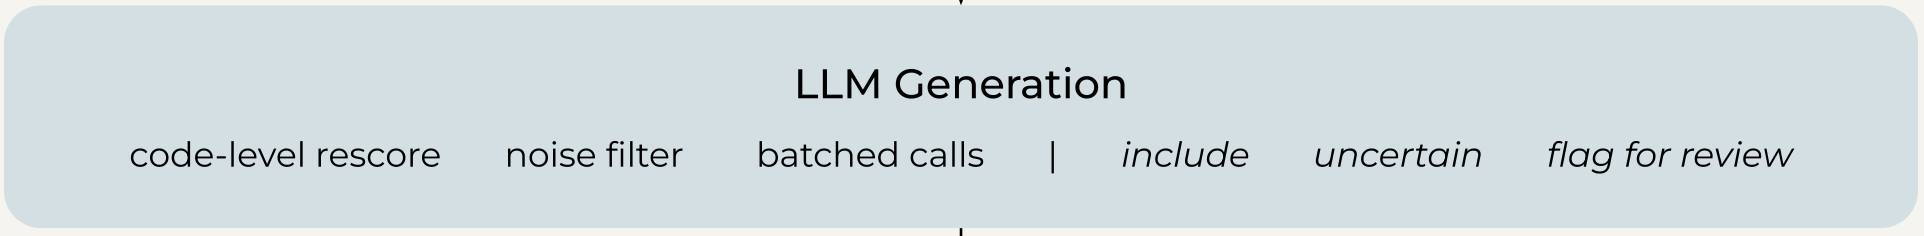

Four functions implement the generation layer:

- `SYSTEM_PROMPT` — the Reviewer prompt. Positions the model as a senior clinical analyst who may only use codes that appear verbatim in the retrieved candidate list. Contains all anti-hallucination constraints, confidence flag definitions, and the required JSON output schema.
- `rescore_codes()` / `extract_and_rank_codes()` — re-scores individual SNOMED codes within the retrieved chunks at the **code level**, not the chunk level. Each code's description and synonyms are scored against the research question using both TF-IDF cosine similarity and dense embedding similarity, fused via RRF. The resulting per-code RRF score is normalised to [0, 1] and blended with the parent chunk's normalised RRF score using `chunk_weight` and `code_weight` from `CONFIGURATION`. This ensures that a highly relevant individual code inside a lower-ranked chunk can still surface to the top of the candidate list.
- `build_user_prompt()` — iterates through the blended-score-ranked codes and adds each to the prompt until the next code would exceed the token budget. Lower-ranked codes are dropped (only applies to the non-agentic RAG pipeline. The agentic loop uses `build_batches()` instead, which packs all codes above the noise threshold into multiple LLM calls so no code is dropped.) Each code's profile includes its SNOMED code and description, cluster relevance score and blended code relevance score, source cluster, synonyms, and relationship taxonomy.
- `get_codelist()` — a single `ollama.chat()` call with `temperature=0`
- `parse_codelist_response()` — strips markdown fences, extracts the first `{...}` JSON object, and attempts to repair truncated JSON caused by the LLM hitting the token limit mid-response by counting unclosed brackets and braces, trimming to the last complete entry (`},`), and closing open structures before re-parsing.

In [ ]:
SYSTEM_PROMPT = """You are an expert clinical coding reviewer helping NICE (National Institute for Health and Care Excellence) define accurate, defensible clinical codelists for healthcare research.

CRITICAL CONSTRAINT — READ BEFORE ANYTHING ELSE:
You must ONLY use SNOMED CT codes that appear verbatim in the provided knowledge base.
Copy the exact numeric snomed_code value. Do not generate, infer, or paraphrase codes.
If no relevant codes exist in the provided clusters, say so in the notes field. Do not invent alternatives.
Be exhaustive — recommend every code from the clusters that could plausibly be used to identify patients matching the research question.
It is better to include too many codes marked 'uncertain' or 'flag_for_review' than to miss relevant codes entirely. A human expert will review and filter.
EXPLICIT EXCLUSIONS: If the prompt contains an 'EXPLICIT EXCLUSIONS DETECTED' warning, you MUST flag any code as "flag_for_review" ONLY if that specific code directly
identifies a patient as having the excluded condition. Do not flag an entire cluster based on its name — evaluate each code individually.
A code about monitoring or procedures related to an excluded condition is NOT itself excluded.
BEWARE THE "CONTEXT" TRAP: Carefully check if a code represents an active diagnosis versus a "history of", "suspected", "referral for", or "fear of" the condition. Exception: if the research question explicitly asks for vaccination or immunisation
records, vaccination codes ARE the target and should be included, not flagged.
BEWARE CLUSTER NAME TRAPS: A cluster's name describes its primary purpose but may not reflect every code it contains. Never exclude a candidate code solely because its source cluster name seems unrelated to the research question.
Always evaluate each code on its own description. For example, a general-purpose cluster may contain codes that are a perfect match for a specific research question even if the cluster name does not suggest it.
CODE RELEVANCE SCORES: Each candidate includes a 'Code Relevance Score' between 0 and 1. This score reflects how closely the individual code's description and synonyms match the research question, computed using both keyword and semantic similarity.
Use 'Code Relevance Score' as a prior — not as a decision: codes above 0.7 are strong lexical and semantic matches and should be carefully evaluated for 'include'. Codes below 0.3 are weak matches — scrutinise them carefully before including, and prefer 'uncertain' or 'flag_for_review' unless your clinical reasoning clearly overrides the score. Never exclude a code on score alone; always apply clinical judgement.

A deterministic retrieval system has already searched the knowledge base of NHS SNOMED code clusters and provided you with a highly-curated, ranked list of clusters based on mathematical and semantic similarity to the research question.

Your job is NOT to search for codes. Your job is to act as a senior clinical analyst: review these top candidates, determine their exact clinical relevance to the user's research question, and provide a clear, human-readable justification for their inclusion or exclusion.

For each candidate code provided in the prompt:
1. Analyze its description, source cluster, and taxonomy.
2. Determine if it directly answers the research question.
3. Write a concise, clinical justification explaining WHY it is relevant (or why it should be excluded).
4. Assign a strict confidence flag.

Confidence flags:
- "include": The specific code perfectly and unambiguously matches the research question.
- "uncertain": The specific code is related, but its relevance depends on clinical context.
- "flag_for_review": The source cluster had a high relevance score, but this specific code is a mismatch, false positive, or out of scope.


CRITICAL CONSTRAINTS:
- You MUST ONLY use the exact SNOMED codes and descriptions provided in the candidate list. Do not invent, paraphrase, or hallucinate codes.
- Evaluate the codes strictly against the provided research question. Do not assume broader context.

Respond ONLY with a valid JSON object matching this exact schema. Do not output markdown fences (```json) or explanatory text outside the JSON.

{
  "research_question": "<the original research question>",
  "summary": "<One short paragraph summarizing the overall quality of the candidate codes and any clinical themes observed>",
  "recommended_codes": [
    {
      "snomed_code": "<exact numeric snomed_code>",
      "code_description": "<exact code_description>",
      "code_relationships": "<exact code_relationships>",
      "synonyms": "<exact synonyms>",
      "cluster_id": "<exact cluster_id>",
      "cluster_description": "<exact cluster_description>",
      "cluster_relevance_score": "<exact cluster_relevance_score>",
      "clinical_justification": "<why this code should be included>",
      "confidence": "<include | uncertain | flag_for_review>"
    }
  ],
  "flagged_for_exclusion": [
    {
      "cluster_id": "<cluster_id>",
      "clinical_justification": "<Explanation of why this ENTIRE cluster is a false positive and should be excluded from the final codelist. If only SOME codes in a cluster are excluded, do NOT list the cluster here — use 'flag_for_review' on those individual codes instead, with a justification explaining the partial exclusion.>"
    }
  ],
"notes": "<Required. Address all of:
(1) any clinical concepts from the research question that had NO relevant codes in the candidates — name the missing concept explicitly;
(2) any clusters that appeared highly relevant by name but whose individual codes did not match — explain why;
(3) any confidence calls you were uncertain about.
If none of these apply, write 'Coverage appears complete for the provided candidates.'>"}"""

In [ ]:
# Flattens retrieved chunks into a deduplicated, ranked list of unique SNOMED codes.
 # gives every code inside a chunk the same inherited chunk RRF score
def extract_and_rank_codes(retrieved_chunks, chunk_lookup):
    code_candidates = {}

    for chunk in retrieved_chunks:

        chunk_score = chunk.get("rrf_score", 0)

        codes = chunk["codes"]

        for code in codes:
            snomed_code = code["snomed_code"]

            # Update the score if new code or better score found
            if snomed_code not in code_candidates or chunk_score > code_candidates[snomed_code]["cluster_relevance_score"]:
                code_candidates[snomed_code] = {
                    "snomed_code": snomed_code,
                    "code_description": code.get("description", []),
                    "code_relationships": code.get("relationships", {}),
                    "synonyms": code.get("synonyms", []),
                    "cluster_id": chunk["cluster_id"],
                    "cluster_description": chunk["cluster_desc"],
                    "cluster_relevance_score": round(float(chunk_score), 4)
                }

    # Sort the final unique codes by their inherited retrieval score (highest first)
    ranked_codes = sorted(code_candidates.values(), key=lambda x: x["cluster_relevance_score"], reverse=True)

    return ranked_codes

In [ ]:
# Re-scores individual SNOMED codes within already-retrieved chunks using
# a hybrid (sparse + dense) similarity against the research question.
# Blends code-level score with parent chunk RRF score

def rescore_codes(research_question, retrieved_chunks, chunk_lookup,
                  tfidf_vectorizer, embedding_model, retrieval_config):

    rrf_k = retrieval_config["retrieving"]["rrf_k"]
    chunk_weight = retrieval_config["code_rescore"]["chunk_weight"]
    code_weight = retrieval_config["code_rescore"]["code_weight"]

    # Fatten all unique codes, inheriting parent chunk score
    flat_codes = extract_and_rank_codes(retrieved_chunks, chunk_lookup)

    if not flat_codes:
        return []

    # build one short document per code (description + synonyms)
    code_texts = []
    for code in flat_codes:
        parts = [code["code_description"]]
        syns = code.get("synonyms", [])
        if syns:
            parts.append(" ".join(syns))
        code_texts.append(" ".join(parts))

    # parse similarity (TF-IDF) for all codes at once
    query_sparse_vec = tfidf_vectorizer.transform([research_question])
    code_sparse_matrix = tfidf_vectorizer.transform(code_texts)
    sparse_scores = cosine_similarity(query_sparse_vec, code_sparse_matrix).flatten()

    # dense similarity for all codes at once
    prefixed_query = f"search_query: {research_question}"
    query_dense_vec = embedding_model.encode(
        prefixed_query,
        normalize_embeddings=retrieval_config["retrieving"]["normalize_embeddings"]
    ).reshape(1, -1)

    prefixed_codes = [f"search_document: {t}" for t in code_texts]
    code_dense_matrix = embedding_model.encode(
        prefixed_codes,
        normalize_embeddings=retrieval_config["retrieving"]["normalize_embeddings"],
        show_progress_bar=False,
        batch_size=retrieval_config["retrieving"]["batch_size"],
    )
    dense_scores = cosine_similarity(query_dense_vec, code_dense_matrix).flatten()

    # RRF fusion of sparse + dense code-level scores
    n = len(flat_codes)
    sparse_ranks = np.argsort(sparse_scores)[::-1]   # indices sorted best to worst
    dense_ranks  = np.argsort(dense_scores)[::-1]

    # Build rank lookup: index to rank position
    sparse_rank_of = np.empty(n, dtype=int)
    dense_rank_of  = np.empty(n, dtype=int)
    for rank, idx in enumerate(sparse_ranks):
        sparse_rank_of[idx] = rank + 1
    for rank, idx in enumerate(dense_ranks):
        dense_rank_of[idx] = rank + 1

    code_rrf_scores = (1 / (rrf_k + sparse_rank_of)) + (1 / (rrf_k + dense_rank_of))

    # Normalise code RRF scores to [0, 1] so they are on the same scale as the chunk RRF scores before blending
    max_rrf = code_rrf_scores.max()
    if max_rrf > 0:
        code_rrf_scores_norm = code_rrf_scores / max_rrf
    else:
        code_rrf_scores_norm = code_rrf_scores

    # normalise chunk RRF scores across this set of codes
    chunk_scores = np.array([c["cluster_relevance_score"] for c in flat_codes], dtype=float)
    max_chunk = chunk_scores.max()
    if max_chunk > 0:
        chunk_scores_norm = chunk_scores / max_chunk
    else:
        chunk_scores_norm = chunk_scores

    # blend and attach scores back to each code
    rescored = []
    for i, code in enumerate(flat_codes):
        blended = chunk_weight * chunk_scores_norm[i] + code_weight * code_rrf_scores_norm[i]
        rescored.append({
            **code,
            "code_sparse_score": round(float(sparse_scores[i]), 4),
            "code_dense_score": round(float(dense_scores[i]), 4),
            "code_rrf_score": round(float(code_rrf_scores[i]), 6),
            "blended_score": round(float(blended), 6),
        })

    # Sort by blended score, highest first
    rescored.sort(key=lambda x: x["blended_score"], reverse=True)
    return rescored

In [ ]:
def estimate_tokens(text, llm_tokeniser):
    return len(llm_tokeniser.encode(text, add_special_tokens=False))

In [ ]:
def build_user_prompt(research_question, retrieved_chunks, llm_config, chunk_lookup, retrieval_config, exclusions=None):
    # Flatten and rank the retrieved codes
    ranked_codes = rescore_codes(research_question, retrieved_chunks, chunk_lookup,
                                 tfidf_vectorizer, embedding_model, retrieval_config)

    # Token budget — leave room for system prompt, question, and output
    token_budget = llm_config["num_ctx"] - llm_config["num_predict"] - estimate_tokens(SYSTEM_PROMPT, llm_tokeniser) - 200  # buffer for system + question
    tokens_used = 0
    top_codes = []

    for code in ranked_codes:
        # Build the profile text to measure its size
        profile_parts = [
            f"Candidate {len(top_codes)+1}: {code['snomed_code']} | {code['code_description']}",
            f"Cluster Relevance Score: {code['cluster_relevance_score']} | Code Relevance Score: {code.get('blended_score', code['cluster_relevance_score'])}",
            f"Source Cluster: {code['cluster_id']} — {code['cluster_description']}",
        ]
        synonyms = code.get("synonyms", [])
        if synonyms:
            profile_parts.append(f"Synonyms: {'; '.join(synonyms)}")
        rels = code.get("code_relationships", {})
        if rels:
            rel_parts = [f"{k.capitalize()}: {', '.join(v)}" for k, v in rels.items()]
            profile_parts.append(f"Taxonomy: [{'; '.join(rel_parts)}]")

        profile_text = "\n".join(profile_parts)
        profile_tokens = estimate_tokens(profile_text, llm_tokeniser)

        if tokens_used + profile_tokens > token_budget:
            break   # stop adding codes when budget is reached

        top_codes.append((code, profile_text))
        tokens_used += profile_tokens

    context_lines = [profile_text for _, profile_text in top_codes]


    context_str = "\n\n".join(context_lines)


    # Build the exclusions
    exclusions_text = ""
    if exclusions:
        exclusions_text = (
            f"EXPLICIT EXCLUSIONS DETECTED: "
            f"{', '.join(exclusions)}\n"
            f"CRITICAL: Any candidate code related to these exclusions MUST be marked 'flag_for_review'.\n\n"
        )

    # Build the final strict prompt
    return (
        f"Research question: {research_question}\n\n"
        f"{exclusions_text}"
        f"Highly-Ranked Candidate Codes (Evaluated by deterministic retrieval):\n\n"
        f"{context_str}\n\n"
        f"IMPORTANT: Every snomed_code must be copied exactly from the candidate list above.\n"
        f"Do not use any other codes. Do not invent codes.\n"
        f"Respond ONLY with this exact JSON structure and nothing else:\n"
        f"{{\n"
        f'  "research_question": "...",\n'
        f'  "summary": "...",\n'
        f'  "recommended_codes": [...],\n'
        f'  "flagged_for_exclusion": [...],\n'
        f'  "notes": "..."\n'
        f"}}"
    )

In [ ]:
# LLM call
def get_codelist(research_question, retrieved_chunks, llm_config, chunk_lookup, retrieval_config, exclusions=None): # llm_config
    conversation = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": build_user_prompt(research_question, retrieved_chunks, llm_config, chunk_lookup, retrieval_config, exclusions),
        },
    ]

    response = ollama.chat(
        model=llm_config["model"],
        messages=conversation,
        options={
            "temperature": llm_config["temperature"],
            "num_ctx": llm_config["num_ctx"],
            "num_predict": llm_config["num_predict"],
        },
    )

    return response.message.content


In [ ]:
# Output parsing
def parse_codelist_response(raw_response):
    # Strip all markdown
    clean = re.sub(r"```(?:json)?\s*", "", raw_response).strip()

    # Extract just the first JSON object
    start = clean.find("{")
    end = clean.rfind("}") + 1
    if start != -1 and end > start:
        clean = clean[start:end]

    try:
        return json.loads(clean), None
    except json.JSONDecodeError:
        # To handle the case where the LLM hit the token limit mid-response
        repaired = clean
        # Count unclosed brackets and braces
        open_braces = repaired.count("{") - repaired.count("}")
        open_brackets = repaired.count("[") - repaired.count("]")
        # Remove trailing incomplete entry — find last complete }
        last_complete = repaired.rfind("},")
        if last_complete != -1:
            repaired = repaired[:last_complete + 1]
        # Close open structures
        repaired += "]" * open_brackets + "}" * open_braces
        try:
            return json.loads(repaired), None
        # Return raw text and error
        except json.JSONDecodeError as e:
            return None, str(e)



### RAG Pipeline

`generate_codelist()` is the end-to-end non-agentic pipeline: retrieve >> generate >> parse. It returns the structured output *and* the retrieved chunks, so every recommendation can be traced back to its source cluster.

`print_codelist()` and `codelist_to_df()` are utility functions for inspection and downstream evaluation.

In [ ]:
# Full RAG pipeline
def generate_codelist(research_question, retrieval_config, llm_config, chunk_lookup):
    # Retrieve relevant chunks
    retrieved = retrieve_with_graph_expansion(research_question, retrieval_config["retrieving"], chunk_lookup, tfidf_vectorizer, tfidf_matrix, dense_index, dense_ids, embedding_model)

    if not retrieved:
        return {
            "research_question": research_question,
            "error": "No chunks retrieved — query may be too specific or outside knowledge base scope",
            "retrieved_chunks": [],
            "raw_response": None,
            "parsed_output": None,
        }

    # Generate codelist from retrieved chunks
    raw_response = get_codelist(research_question, retrieved, llm_config, chunk_lookup, retrieval_config, exclusions=None)

    # Parse structured output
    parsed_output, parse_error = parse_codelist_response(raw_response)

    return {
        "research_question": research_question,
        "n_chunks_retrieved": len(retrieved),
        "retrieved_chunks": retrieved,
        "raw_response": raw_response,
        "parsed_output": parsed_output,
        "parse_error": parse_error,
    }


In [ ]:
# Format output for inspection
def print_codelist(result):
    print(f"{'═' * 70}\n")
    print(f"Research question: {result['research_question']}\n")
    print(f"Chunks retrieved:  {result['n_chunks_retrieved']}\n")
    print(f"{'═' * 70}\n")

    if result.get("error"):
        print(f"{result['error']}\n")
        return

    if result.get("parse_error"):
        print(f"JSON parse error: {result['parse_error']}\n")
        print(f"Raw response:\n{result['raw_response']}\n")
        return

    output = result["parsed_output"]

    print(f"Summary: {output.get('summary', 'N/A')}\n")

    recommended = output.get("recommended_codes", [])
    print(f"{'─' * 70}")
    print(f"Recommended codes ({len(recommended)}):\n")


    # Group by confidence flag
    for flag in ["include", "uncertain", "flag_for_review"]:
        flag_codes = [code for code in recommended if code.get("confidence") == flag]
        if flag_codes:
            label = {"include": "Include", "uncertain": "Uncertain", "flag_for_review": "Flag for review"}[flag]
            print(f"{label} ({len(flag_codes)}):\n")
            for code in flag_codes:
                cluster_id = code.get("cluster_id", "Unknown Cluster")
                cluster_desc = code.get("cluster_description", code.get("cluster_desc", "No cluster description provided"))
                print(f"{code['snomed_code']:<15} {code['code_description']}\n")
                print(f"Source: {cluster_id} -- {cluster_desc}\n")
                print(f"Justification: {code.get('clinical_justification', 'No justification provided')}\n")

    excluded = output.get("flagged_for_exclusion", [])
    if excluded:
        print(f"Excluded clusters ({len(excluded)}):\n")
        for e in excluded:
            print(f"{e['cluster_id']:<25} {e['clinical_justification']}\n")

    if output.get("notes"):
        print(f"Notes: {output['notes']}\n")

In [ ]:
# Flatten to DataFrame for evaluation
def codelist_to_df(result):
    if not result.get("parsed_output"):
        return pd.DataFrame()

    recommended = result["parsed_output"].get("recommended_codes", [])
    if not recommended:
        return pd.DataFrame()

    df = pd.DataFrame(recommended)
    df["research_question"] = result["research_question"]

    df["n_chunks_retrieved"] = (
        result.get("n_chunks_retrieved") # non-agentic path
        or result.get("n_chunks_total") # agentic path
    )

    df = df.drop_duplicates(subset=["snomed_code"])

    return df[["research_question", "snomed_code", "code_description",
               "cluster_id", "cluster_description", "clinical_justification",
               "confidence", "n_chunks_retrieved"]]

### ReAct-style Agentic Loop

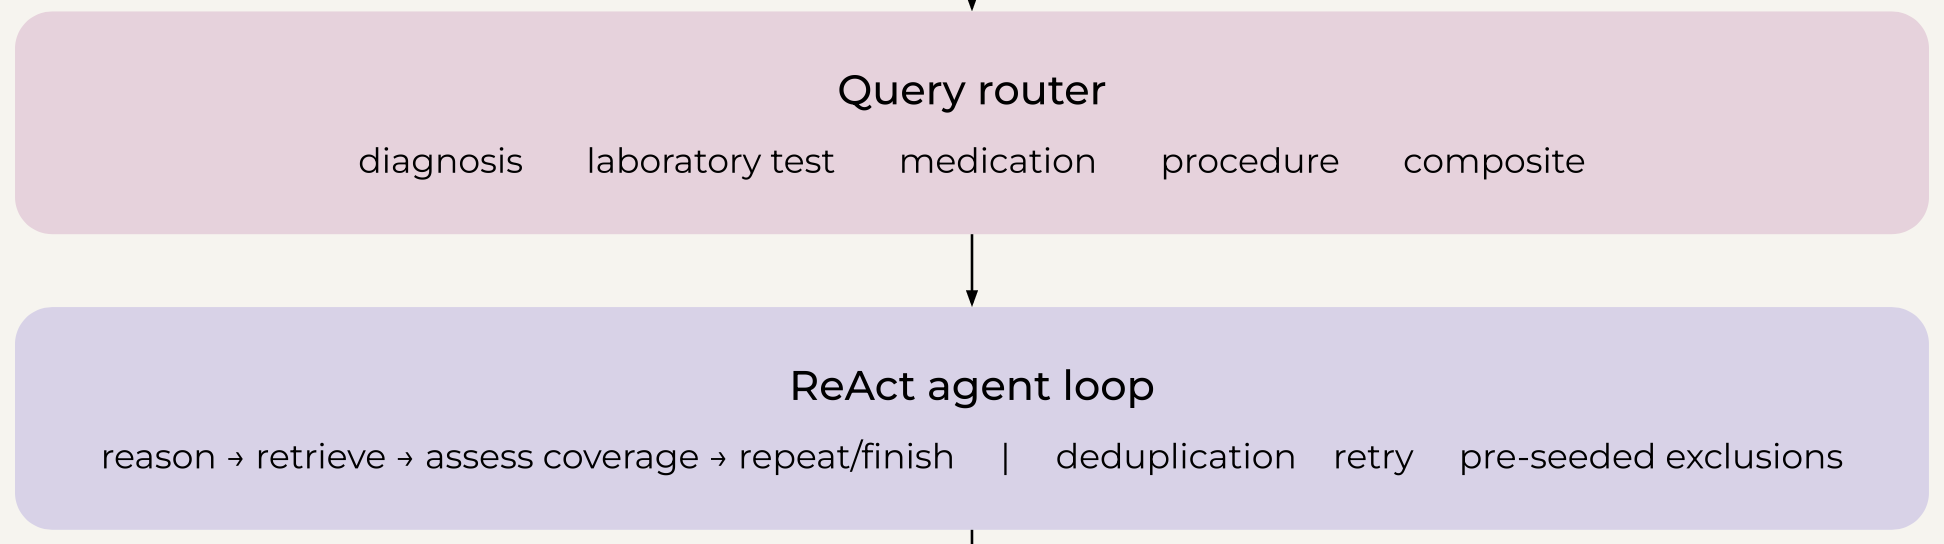

Five components implement the multi-step reasoning agent:

- `AGENT_SYSTEM_PROMPT` — the Searcher prompt. Teaches the agent how to translate SNOMED relationship axes into targeted query strings. Defines exactly two valid JSON response formats: `retrieve` (with a query and reasoning) and `generate` (with reasoning and an exclusions list).
- `build_agent_step_prompt()` — assembles the current agent state into the next reasoning step: the original research question, the routing classification block (query type, sub-concepts, priority axes, known exclusions), all previously used queries, and for each query: the total cluster count plus a brief summary of up to the first 10 clusters (cluster description + unique relationship axes). This summary is a secondary signal — the agent's primary decision driver is whether all sub-concepts from the routing plan have been queried, not the cluster descriptions themselves.
- `agent_step()` — a single `ollama.chat()` call that returns either a parsed `{action, query/reasoning}` decision or a parse error. On JSON decode failure it retries up to `max_retries` times; on the final failure it appends the bad response and a correction instruction to the conversation before returning `None`.
- `QUERY_ROUTER_PROMPT` / `classify_query()` — classifies the research question before the loop begins, returning a structured plan: query type (`diagnosis`, `laboratory_test`, `medication`, `procedure`, `composite`), a list of sub-concepts each with a single retrievable clinical entity and its primary SNOMED axes, explicit exclusions, complexity (`simple`, `moderate`, `complex`), and a one-sentence routing rationale. If classification fails, `classify_query()` returns `None` gracefully and the agent runs without a briefing.
- `run_agent()` — the full ReAct loop: classify >> reason >> retrieve >> assess >> repeat until FINISH.

In [ ]:
AGENT_SYSTEM_PROMPT = """You are a clinical coding agent helping define accurate and defensible clinical codelists for NICE (National Institute for Health and Care Excellence).

You have access to a retrieval tool that searches a knowledge base of NHS clinical code clusters and SNOMED codes.
The knowledge base is structured using the SNOMED CT taxonomy. Each step you receive a query classification in the user message — it tells you which axes to prioritise for
each sub-concept. Use it to formulate targeted query strings:
"- is_a (hierarchy): Search for the concept name directly."
"  e.g. query 'Liver disease' not 'Liver disease is_a'"
"- finding_site: Search for the anatomical structure name, not the disease name."
"  e.g. for 'hepatitis', query 'Liver structure' not 'hepatitis finding_site'"
"- ingredient: Search for the specific drug name, not the drug class."
"  e.g. for 'DOACs', query 'Apixaban' or 'Rivaroxaban' not 'DOAC ingredient'"
"- investigation: Search for what is being measured, not the test name."
"  e.g. for 'liver function test', query 'Alanine aminotransferase' not 'LFT investigation'"
"- causative_agent: Search for the organism or substance name, not the disease name."
"  e.g. for 'influenza', query 'Influenza virus' not 'influenza causative_agent'"
"- procedure_site: Search for the anatomical structure name, not the procedure name."
"  e.g. for 'knee replacement', query 'Knee joint structure' not 'knee replacement procedure_site'"
"- course: Search for the clinical course descriptor directly."
"  e.g. for 'chronic kidney disease', query 'Chronic' not 'chronic kidney disease course'"
"- method: Search for the procedure method name directly."
"  e.g. for 'surgical excision', query 'Excision' not 'surgical excision method'"
"- laterality: Search for the anatomical structure with its side."
"  e.g. for 'left knee replacement', query 'Left knee joint' not 'left laterality'"
"- associated_with: Search for the directly associated clinical concept."
"  e.g. for 'neuropathy associated with diabetes', query 'Diabetes mellitus' not 'neuropathy associated_with'"
"- pathological_process: Search for the pathological process name directly."
"  e.g. for 'rheumatoid arthritis', query 'Inflammatory' not 'rheumatoid arthritis pathological_process'"

CRITICAL: Never append axis names (is_a, finding_site, ingredient, investigation, procedure_site) to your query string.
The axis tells you WHAT to search for — use it to formulate the query, then search for the concept alone.

Your job is to identify all clinical concepts in a research question and retrieve clusters for each — ONE concept per step.

At each step you will see:
- The original research question
- Queries already used
- Clusters found so far

Respond with JSON in one of two formats:

FORMAT 1 — retrieve for another concept:
{"action": "retrieve", "query": "<specific clinical concept>", "reasoning": "<why needed>"}

FORMAT 2 — enough context, generate the codelist:
{"action": "generate", "reasoning": "<why coverage is sufficient>", "exclusions": ["<list of negated concepts explicitly mentioned in the query, or an empty list [] if none>"]}

Rules:
- One concept per step — never combine multiple conditions into one query
- Start with clinical conditions and diagnoses before treatments or medications
- Use the SNOMED taxonomy to your advantage: if a disease is missing, try searching for its 'Finding site' or 'Causative agent'.
- Be specific — "type 2 diabetes" not "diabetes" if the question specifies type 2
- Stop when all major concepts in the question are covered
- If a sub-concept from the classification block has returned zero new chunks across two different query attempts (e.g. the concept itself and a synonym),
mark it as exhausted and move on — do not keep retrying the same concept.
- Respond ONLY with valid JSON. Do not write any text, explanation, or reasoning outside the JSON object. Your entire response must start with { and end with }.
- Use synonyms & abbreviations - if your initial query returns poor or zero results, broaden your search by retrieving known clinical synonyms or standard medical abbreviations for the concept.
- Primary care prescribing limitation - be aware that in English primary care, prescriptions are coded using dm+d, not SNOMED CT. If the research question specifically asks for "prescriptions" or "medications issued", you can search for the active ingredient, but remember that SNOMED medication codes may not capture primary care prescribing events accurately."""


In [ ]:
# Build prompt
def build_agent_step_prompt(research_question, retrieved_so_far, seen_queries, routing_plan=None):
    # Summarise what has been retrieved so far — or note if nothing yet
    if not retrieved_so_far:
        context = "Nothing retrieved yet."
    else:
        lines = []
        for query, chunks in retrieved_so_far.items():

            chunk_summaries = []

            # Process the top ?? chunks for this query
            for chunk in chunks[:10]:
                desc = chunk["cluster_desc"]

                # Extract all unique relationship
                rels_found = set()
                for code in chunk.get("codes", []):
                    rels = code.get("relationships", {})
                    rels_found.update(rels.keys())

                if rels_found:
                    rels_str = f"[Relationships: {', '.join(sorted(rels_found))}]"
                else:
                    rels_str = "[No relationships.]"

                chunk_summaries.append(f"- {desc} {rels_str}")


            tops = ", ".join(chunk_summaries)
            lines.append(f"Query: '{query}' -> {len(chunks)} clusters\n Top: {tops}")

        context = "\n".join(lines)

    # Format already-used queries as a readable string
    seen_str = ", ".join(f"'{q}'" for q in seen_queries) if seen_queries else "none"

    # --- Routing plan block ---
    routing_block = ""
    if routing_plan and not isinstance(routing_plan, str):
        sub_concepts_str = "\n".join(
            f"  - [{c['type'].upper()}] '{c['concept']}' (prioritise axes: {', '.join(c['primary_axes'])})"
            for c in routing_plan.get("sub_concepts", [])
        )
        exclusions = routing_plan.get("explicit_exclusions", [])
        exclusions_str = (f"\nKnown exclusions (do NOT retrieve): {', '.join(exclusions)}"
                         if exclusions else "")
        routing_block = (
            f"\n--- Query classification ---\n"
            f"Type: {routing_plan.get('query_type','unknown')} | Complexity: {routing_plan.get('complexity','unknown')}\n"
            f"Reasoning: {routing_plan.get('routing_reasoning','')}\n"
            f"Sub-concepts to retrieve (priority order):\n{sub_concepts_str}{exclusions_str}\n"
            f"--- End classification ---\n"
        )


    # Build the prompt — LLM uses this to decide next action
    return (
        f"Research question: \n{research_question}\n"
        f"{routing_block}"
        f"Queries already used: \n{seen_str}\n"
        f"Retrieved so far: \n{context}\n"
        f"What should I retrieve next, or do I have enough to generate the codelist?"
    )

In [ ]:
def agent_step(research_question, retrieved_so_far, seen_queries, config, routing_plan=None, max_retries=2):
  # Retry loop — attempts up to max_retries times if json parsing fails
  for attempt in range(max_retries):

    # Build conversation with system prompt and current agent state
    conversation = [
        {"role": "system", "content": AGENT_SYSTEM_PROMPT},
        {"role": "user",   "content": build_agent_step_prompt(
            research_question, retrieved_so_far, seen_queries,
            routing_plan=routing_plan)},
    ]

    # Call LLM and get raw response
    response = ollama.chat(
        model=config["model"],
        messages=conversation,
        options={
            "temperature": config["temperature"],
            "num_ctx": config["num_ctx"],
            "num_predict": config["num_predict"],
        },
    )

    raw = response.message.content


    # Strip markdown fences
    clean = re.sub(r"```(?:json)?\s*", "", raw).strip()

    # Extract just the first json object — ignore any text before or after
    start = clean.find("{")
    end = clean.rfind("}") + 1
    if start != -1 and end > start:
        clean = clean[start:end]

    # Return parsed result or retry on failure
    try:
        return json.loads(clean), None
    except json.JSONDecodeError as e:
        if attempt == max_retries - 1:
            # Append the bad response and a correction instruction
            messages.append({"role": "assistant", "content": raw})
            messages.append({"role": "user", "content":
                "Your response was not valid JSON. "
                "Do not write any explanation or text outside the JSON. "
                "Respond again with ONLY a valid JSON object starting with { and ending with }."
            })
            return None, {"raw": raw, "error": str(e)}

In [ ]:
QUERY_ROUTER_PROMPT = """You are a clinical query classifier. Given a research question for NHS
clinical codelist generation, identify the query type, sub-concepts, and exclusions.

Query types:
- "diagnosis": patient has a disease or condition
- "laboratory_test": test, investigation or measurement
- "medication": drug, prescription or active ingredient
- "procedure": surgical or clinical procedure or intervention
- "composite": question spans multiple types above

Each sub-concept must be a single retrievable clinical entity — a specific disease,
drug ingredient, test, or procedure. Do not combine multiple conditions into one concept.
Do not use vague terms like "monitoring" or "management" as sub-concepts.

Primary axes by query type:
- diagnosis: is_a, finding_site, causative_agent, course, pathological_process, associated_with
- laboratory_test: investigation, finding_site, associated_with
- medication: ingredient, associated_with
- procedure: procedure_site, method, laterality, associated_with
- composite: is_a, finding_site, investigation, ingredient, associated_with

Respond ONLY with valid JSON. No markdown, no explanation:
{
  "query_type": "<diagnosis|laboratory_test|medication|procedure|composite>",
  "sub_concepts": [
    {
      "concept": "<specific clinical concept to retrieve>",
      "type": "<diagnosis|laboratory_test|medication|procedure>",
      "primary_axes": ["<choose from the axes listed above for this type>"]
    }
  ],
  "explicit_exclusions": ["<clinical concepts explicitly excluded from the patient population,
  e.g. in \'patients with diabetes excluding type 1\', the exclusion is \'type 1 diabetes\'.
  Do NOT list concepts that define the condition itself. Empty list if none.>"],
  "complexity": "<simple|moderate|complex>",
  "routing_reasoning": "<one sentence>"
}"""

In [ ]:
# Classify a research question before the agent loop
def classify_query(research_question, router_config):
    response = ollama.chat(
        model=router_config["model"],
        messages=[
            {"role": "system", "content": QUERY_ROUTER_PROMPT},
            {"role": "user",   "content": f"Research question: {research_question}"},
        ],
        options={"temperature": router_config["temperature"],
                 "num_ctx":     router_config["num_ctx"],
                 "num_predict": router_config["num_predict"]},
    )
    raw = response.message.content
    clean = re.sub(r"```(?:json)?\s*", "", raw).strip()
    start = clean.find("{"); end = clean.rfind("}") + 1
    if start != -1 and end > start:
        clean = clean[start:end]
    try:
        return json.loads(clean), None
    except json.JSONDecodeError as e:
        return None, str(e)  # agent runs without briefing


In [ ]:
def run_agent(research_question, retrieval_config, llm_config, agent_config, router_config, chunk_lookup, verbose=True):
    # Initialise agent memory and audit trail
    retrieved_so_far = {}
    seen_queries = set()
    agent_log = []
    found_exclusions = []
    step = 0

    if verbose:
        print(f"{'=' * 100}\n")
        print(f"Research question: {research_question}")
        print(f"{'=' * 100}\n")

    # Classify the query before the ReAct loop
    routing_plan, routing_error = classify_query(research_question, router_config)
    if verbose:
        if routing_error:
            print(f"Query routing failed ({routing_error}) — proceeding without briefing.\n")
        else:
            print(f"Query type: {routing_plan.get('query_type')} | Complexity: {routing_plan.get('complexity')}")
            print(f"Routing: {routing_plan.get('routing_reasoning')}")
            for c in routing_plan.get("sub_concepts", []):
                print(f"  [{c['type']}] '{c['concept']}' >> axes: {c['primary_axes']}")
            if routing_plan.get("explicit_exclusions"):
                print(f"  Exclusions detected early: {routing_plan['explicit_exclusions']}")
            print()


    # Pre-seed exclusions from the router (don't wait for the agent to find them)
    found_exclusions = routing_plan.get("explicit_exclusions", []) if routing_plan else []

    # Record the routing step in the audit log
    agent_log.append({"step": 0, "action": "classify",
                      "routing_plan": routing_plan, "routing_error": routing_error})

    # Resolve dynamic step ceiling from routing plan complexity
    complexity = routing_plan.get("complexity", "default") if routing_plan else "default"
    max_steps_map = agent_config.get("max_steps", {})
    max_steps = max_steps_map.get(complexity, max_steps_map.get("default", 10))

    if verbose:
        print(f"Max retrieval steps: {max_steps} (complexity: {complexity})\n")



    # Run reasoning loop until agent decides to stop
    while True:
        step += 1
        if verbose:
            print(f"--- Step: {step} ---\n")

        # Hard ceiling - force generate if max steps reached
        if step > max_steps:
            if verbose:
                print(f"Warning: Max steps ({max_steps}) reached for complexity '{complexity}' — forcing generate.\n")
            agent_log.append({"step": step, "action": "max_steps_reached",
                              "complexity": complexity, "max_steps": max_steps})
            break

        # Ask LLM to decide next action based on current state
        decision, parse_error = agent_step(
            research_question, retrieved_so_far, seen_queries,
            agent_config, routing_plan=routing_plan
        )


        # Stop if LLM returns invalid JSON
        if parse_error:
            agent_log.append({"step": step, "error": parse_error})
            if verbose:
                print(f"Warning: Parse error: {parse_error['error']}\n")
                print(f"Raw: {parse_error['raw'][:200]}\n")
            break

        # At every step either a decision or an error is appended to the log
        agent_log.append({"step": step, "decision": decision})
        action = decision.get("action")
        reasoning = decision.get("reasoning", "")

        if verbose:
            print(f"Action: {action}\n")
            print(f"Reasoning: {reasoning}\n")

        # When LLM has enough context exit loop and generate
        if action == "generate":
            # Merge agent exclusions with router-detected exclusions
            agent_exclusions = decision.get("exclusions", [])
            found_exclusions  = list(set(found_exclusions + agent_exclusions))

            if verbose:
                print(f"Agent ready to generate.\n")
                print(f"Queries used: \n{list(retrieved_so_far.keys())}\n")
                if found_exclusions:
                    print(f"Exclusions found: {found_exclusions}\n")
            break

        elif action == "retrieve":
            query = decision.get("query", "").strip()

            # Skip LLM returned an empty query
            if not query:
                if verbose: print("Warning: Empty query — skipping to next step")
                continue

            # Stop if this query has already been used — to prevent infinite loops
            if query.lower() in {q.lower() for q in seen_queries}:
                if verbose: print(f"Warning: '{query}' already used — stopping")
                break

            seen_queries.add(query)

            # Retrieve relevant chunks for this sub-query
            chunks = retrieve_with_graph_expansion(
                query,
                retrieval_config["retrieving"],
                chunk_lookup,
                tfidf_vectorizer, tfidf_matrix, dense_index, dense_ids, embedding_model,
                routing_plan=routing_plan,
                current_concept=query,
                verbose=verbose,
            )

            if verbose:
                print(f"Query: '{query}'")
                print(f"Retrieved: {len(chunks)} chunks")
                for chunk in chunks:
                    print(f">> {chunk['cluster_id']:<25} {chunk['cluster_desc']}")

            # Count new chunks not seen in previous steps
            new_ids = {chunk["chunk_id"] for chunk in chunks}
            existing_ids = {chunk["chunk_id"] for prev in retrieved_so_far.values() for chunk in prev}
            n_new = len(new_ids - existing_ids)

            if verbose:
                print(f"New unique chunks: {n_new}\n")

            # Stop if retrieval adds nothing new
            if n_new < agent_config["min_new_chunks"] and retrieved_so_far:
                if verbose:
                    print("Warning: No new chunks — Agent will decide if it needs more.")

            # Store results with query as the key
            retrieved_so_far[query] = chunks

        else:
            if verbose: print(f"Warning: Unknown action '{action}' — stopping")
            break

    # Merge all retrieved chunks — deduplicate by chunk_id, keep best score
    all_chunks_dict = {}
    for retrieved_chunks in retrieved_so_far.values():
        for chunk in retrieved_chunks:
            c_id = chunk["chunk_id"]
            if c_id not in all_chunks_dict or chunk["rrf_score"] > all_chunks_dict[c_id]["rrf_score"]:
                all_chunks_dict[c_id] = chunk


    # Retrieve parent concepts not yet seen
    expansion_queries = set()
    for chunk in all_chunks_dict.values():
        for code in chunk.get("codes", []):
            for parent in code.get("relationships", {}).get("is_a", []):
                if parent.lower() not in {q.lower() for q in seen_queries}:
                    expansion_queries.add(parent)

    for eq in list(expansion_queries)[:10]:   # cap to avoid explosion
        extra = retrieve_with_graph_expansion(eq, retrieval_config["retrieving"],
                                              chunk_lookup, tfidf_vectorizer,
                                              tfidf_matrix, dense_index, dense_ids,
                                              embedding_model, routing_plan=routing_plan)
        for chunk in extra:
            c_id = chunk["chunk_id"]
            if c_id not in all_chunks_dict:
                all_chunks_dict[c_id] = chunk


    # Sort the final unique chunks by their relevance score (highest first)
    ranked_chunks = sorted(all_chunks_dict.values(), key=lambda x: x["rrf_score"], reverse=True)

    # --- Code-level rescoring across ALL retrieved chunks before any trimming ---
    rescored_codes = rescore_codes(
        research_question,
        list(all_chunks_dict.values()),   # all chunks, not trimmed yet
        chunk_lookup,
        tfidf_vectorizer,
        embedding_model,
        retrieval_config,
    )

    # Token budget - leave room for prompt, question, and output
    token_budget = (
        llm_config["num_ctx"]
        - llm_config["num_predict"]
        - estimate_tokens(SYSTEM_PROMPT, llm_tokeniser)
        - estimate_tokens(research_question, llm_tokeniser)
        - 400   # buffer for exclusions block + JSON scaffolding
    )



    # --- Split rescored codes into token-budget-sized batches ---
    # Each batch is as large as the token budget allows, then a new LLM call
    # handles the next batch. Results are merged at the end.

    # Filter out noise-level codes once, before batching
    min_score = agent_config.get("min_blended_score", 0.15)
    filtered_codes = [c for c in rescored_codes if c["blended_score"] >= min_score]

    # Token budget per LLM call
    token_budget = (
        llm_config["num_ctx"]
        - llm_config["num_predict"]
        - estimate_tokens(SYSTEM_PROMPT, llm_tokeniser)
        - estimate_tokens(research_question, llm_tokeniser)
        - 400   # buffer for exclusions block + JSON scaffolding
    )

    # Build batches — each batch is a list of (code, profile_text) tuples
    def build_batches(codes, token_budget):
        batches = []
        current_batch = []
        tokens_used = 0

        for code in codes:
            profile_parts = [
                f"Candidate {len(current_batch)+1}: {code['snomed_code']} | {code['code_description']}",
                f"Cluster Relevance Score: {code['cluster_relevance_score']} | Code Relevance Score: {code['blended_score']}",
                f"Source Cluster: {code['cluster_id']} — {code['cluster_description']}",
            ]
            if code.get("synonyms"):
                profile_parts.append(f"Synonyms: {'; '.join(code['synonyms'])}")
            if code.get("code_relationships"):
                rel_parts = [f"{k.capitalize()}: {', '.join(v)}" for k, v in code["code_relationships"].items()]
                profile_parts.append(f"Taxonomy: [{'; '.join(rel_parts)}]")
            profile_text = "\n".join(profile_parts)
            profile_tokens = estimate_tokens(profile_text, llm_tokeniser)

            if tokens_used + profile_tokens > token_budget and current_batch:
                # Current batch is full — save it and start a new one
                batches.append(current_batch)
                current_batch = [(code, profile_text)]
                tokens_used = profile_tokens
            else:
                current_batch.append((code, profile_text))
                tokens_used += profile_tokens

        if current_batch:
            batches.append(current_batch)

        return batches

    batches = build_batches(filtered_codes, token_budget)

    if verbose:
        print(f"--- Generating final codelist ---\n")
        print(f"Unique chunks across all steps:  {len(all_chunks_dict)}\n")
        print(f"Rescored codes (all chunks):     {len(rescored_codes)}\n")
        print(f"Codes above noise threshold:     {len(filtered_codes)}\n")
        print(f"Token budget per LLM call:       {token_budget} tokens\n")
        print(f"LLM batches:                     {len(batches)}\n")
        for i, batch in enumerate(batches):
            print(f"  Batch {i+1}: {len(batch)} codes\n")

    # Return early if nothing survived rescoring
    if not batches:
        return {
            "research_question": research_question,
            "agent_log": agent_log,
            "retrieved_queries": list(retrieved_so_far.keys()),
            "n_chunks_total": 0,
            "error": "No codes survived rescoring — query may be too specific or outside knowledge base scope",
            "raw_response": None,
            "parsed_output": None,
        }

    # --- Run LLM on each batch and collect results ---
    # User prompt mirrors build_user_prompt() exactly, with one addition: {batch_header}.
    # When codes span multiple batches, the LLM is told it is reviewing a subset
    # so it does not assume the candidate list is exhaustive.
    # All other framing exclusions block, anti-hallucination instruction, JSON schema reminder is kept identical to the non-agentic path.
    exclusions_text = ""
    if found_exclusions:
        exclusions_text = (
            f"EXPLICIT EXCLUSIONS DETECTED: {', '.join(found_exclusions)}\n"
            f"CRITICAL: Any candidate code related to these exclusions MUST be marked 'flag_for_review'.\n\n"
        )

    all_recommended_codes = []
    all_flagged_for_exclusion = []
    all_summaries = []
    all_notes = []
    all_raw_responses = []
    any_parse_error = None

    for batch_idx, batch in enumerate(batches):
        if verbose:
            print(f"--- LLM batch {batch_idx + 1} / {len(batches)} ({len(batch)} codes) ---\n")

        context_str = "\n\n".join(profile_text for _, profile_text in batch)

        # Tell the LLM which batch this is so it understands it's part of a larger set
        batch_header = ""
        if len(batches) > 1:
            batch_header = (
                f"NOTE: This is batch {batch_idx + 1} of {len(batches)}. "
                f"You are reviewing a subset of the full candidate list. "
                f"Apply the same rigorous evaluation as you would to the full list.\n\n"
            )

        user_prompt = (
            f"Research question: {research_question}\n\n"
            f"{exclusions_text}"
            f"{batch_header}"
            f"Highly-Ranked Candidate Codes (Evaluated by deterministic retrieval):\n\n"
            f"{context_str}\n\n"
            f"IMPORTANT: Every snomed_code must be copied exactly from the candidate list above.\n"
            f"Do not use any other codes. Do not invent codes.\n"
            f"Respond ONLY with this exact JSON structure and nothing else:\n"
            f"{{\n"
            f'  "research_question": "...",\n'
            f'  "summary": "...",\n'
            f'  "recommended_codes": [...],\n'
            f'  "flagged_for_exclusion": [...],\n'
            f'  "notes": "..."\n'
            f"}}"
        )

        conversation = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_prompt},
        ]
        raw_response = ollama.chat(
            model=llm_config["model"],
            messages=conversation,
            options={
                "temperature": llm_config["temperature"],
                "num_ctx":     llm_config["num_ctx"],
                "num_predict": llm_config["num_predict"],
            },
        ).message.content

        all_raw_responses.append(raw_response)
        parsed, parse_error = parse_codelist_response(raw_response)

        if parse_error:
            any_parse_error = parse_error
            if verbose:
                print(f"Warning: parse error on batch {batch_idx + 1}: {parse_error}\n")
            continue

        all_recommended_codes.extend(parsed.get("recommended_codes", []))
        all_flagged_for_exclusion.extend(parsed.get("flagged_for_exclusion", []))
        all_summaries.append(parsed.get("summary", ""))
        all_notes.append(parsed.get("notes", ""))

    # --- Deduplicate recommended codes across batches (keep highest confidence) ---
    confidence_rank = {"include": 0, "uncertain": 1, "flag_for_review": 2}
    merged_codes = {}
    for code in all_recommended_codes:
        sc = code["snomed_code"]
        if sc not in merged_codes:
            merged_codes[sc] = code
        else:
            # Keep the more confident assignment
            existing_rank = confidence_rank.get(merged_codes[sc].get("confidence"), 99)
            new_rank = confidence_rank.get(code.get("confidence"), 99)
            if new_rank < existing_rank:
                merged_codes[sc] = code

    # Deduplicate flagged clusters
    seen_clusters = set()
    merged_flagged = []
    for entry in all_flagged_for_exclusion:
        if entry["cluster_id"] not in seen_clusters:
            seen_clusters.add(entry["cluster_id"])
            merged_flagged.append(entry)

    # Merge summaries and notes from all batches into one
    parsed_output = {
        "research_question": research_question,
        "summary": " | ".join(s for s in all_summaries if s),
        "recommended_codes": list(merged_codes.values()),
        "flagged_for_exclusion": merged_flagged,
        "notes": " | ".join(n for n in all_notes if n),
    }

    # Return full result including audit trail
    return {
        "research_question": research_question,
        "agent_log": agent_log,
        "complexity": complexity,
        "max_steps": max_steps,
        "retrieved_queries": list(retrieved_so_far.keys()),
        "n_retrieval_steps": step,
        "n_chunks_total": len(all_chunks_dict),
        "all_retrieved_chunks": list(all_chunks_dict.values()),
        "n_codes_rescored": len(rescored_codes),
        "n_codes_filtered": len(filtered_codes),
        "n_llm_batches": len(batches),
        "n_codes_to_llm": len(filtered_codes),
        "codes_passed_to_llm": [c for batch in batches for c, _ in batch],
        "chunks_passed_to_llm": [c for batch in batches for c, _ in batch],  # backward compat
        "raw_response": "\n\n---BATCH BREAK---\n\n".join(all_raw_responses),
        "parsed_output": parsed_output,
        "parse_error": any_parse_error,
    }


In [ ]:
def print_agent_result(result):

    print(f"{'=' * 100}\n")
    print(f"Research question: {result['research_question']}\n")
    print(f"Retrieval steps: {result.get('n_retrieval_steps', 'N/A')}\n")
    print(f"Queries used: {result.get('retrieved_queries', [])}\n")
    print(f"Chunks: {result.get('n_chunks_total', 0)} unique\n")

    passed_codes = result.get("codes_passed_to_llm", [])
    if passed_codes:
        print(f"Codes passed to LLM: {result.get('n_codes_to_llm', len(passed_codes))}\n")
        unique_clusters = {code["cluster_id"]: code.get("cluster_description", "") for code in passed_codes}
        print(f"Unique clusters: {len(unique_clusters)}\n")
        for cluster_id, cluster_desc in unique_clusters.items():
            print(f"  >> {cluster_id:<25} {cluster_desc}")
        print()


    print(f"{'=' * 100}\n")

    # Stop early if agent failed to retrieve anything
    if result.get("error"):
        print(f"Error: {result['error']}")
        return

    # Stop early if LLM response could not be parsed
    if result.get("parse_error"):
        print(f"JSON parse error: {result['parse_error']}")
        print(f"Raw:\n{result['raw_response']}")
        return

    output = result["parsed_output"]
    recommended = output.get("recommended_codes", [])

    # Print summary from LLM
    print(f"Summary: {output.get('summary', 'N/A')}\n")

    # Print recommended codes grouped by confidence flag
    print(f"{'-' * 70}\n")
    print(f"\nRecommended codes ({len(recommended)}):\n")
    for flag in ["include", "uncertain", "flag_for_review"]:
        flag_codes = [code for code in recommended if code.get("confidence") == flag]
        if not flag_codes:
            continue
        label = {
            "include": "Include",
            "uncertain": "Uncertain",
            "flag_for_review": "Flag for review",
        }[flag]
        print(f"{label} ({len(flag_codes)}):\n")
        for code in flag_codes:
            cluster_id = code.get("cluster_id", "Unknown Cluster")
            cluster_desc = code.get("cluster_description", code.get("cluster_desc", "No cluster description provided"))
            print(f"{code['snomed_code']:<15} {code['code_description']}\n")
            print(f"Source: {cluster_id} -- {cluster_desc}\n")
            print(f"Justification: {code.get('clinical_justification', 'No justification provided')}\n")

    # Print clusters the LLM decided not to use
    excluded = output.get("flagged_for_exclusion", [])
    if excluded:
        print(f"Excluded clusters ({len(excluded)}):\n")
        for e in excluded:
            print(f"{e['cluster_id']:<25} {e['clinical_justification']}\n")

    # Print any notes or limitations flagged by the LLM
    if output.get("notes"):
        print(f"Notes: {output['notes']}\n")

    # Print full agent reasoning trace for audit trail
    print(f"--- Agent reasoning trace ---\n")
    for entry in result.get("agent_log", []):
        s = entry["step"]
        if "error" in entry:
            print(f"Step {s}: ERROR -- {entry['error']['error']}\n")
        elif entry.get("action") == "classify":             # <-- handle step 0
            plan  = entry.get("routing_plan") or {}
            error = entry.get("routing_error")
            if error:
                print(f"Step {s}: CLASSIFY   routing failed — {error}\n")
            else:
                print(f"Step {s}: CLASSIFY   {plan.get('query_type','?')} | "
                      f"{plan.get('complexity','?')} | "
                      f"{plan.get('routing_reasoning','')}\n")
        else:
            d = entry["decision"]
            print(f"Step {s}: {d.get('action','?').upper():<10} {d.get('query', d.get('reasoning',''))}\n")

### Evaluation

For each benchmark, `evaluate_against_benchmark()` produces 3 diagnostic layers:

**Failure Mode Taxonomy:** each missed benchmark code is assigned a root cause — `kb_gap`, `retrieval_failure`, or `llm_rejection` — so failures can be attributed to the data, the retrieval step, or the LLM respectively.

  - **Layer 1 — Knowledge Base Coverage:** what fraction of benchmark codes exist anywhere in the knowledge base. This is the hard ceiling — a code absent from the knowledge base cannot be recommended regardless of retrieval or LLM quality. Low coverage signals a *data-scope* problem, not a pipeline failure. (`kb_gap`)

  - **Layer 2 — Retrieval vs Generation Diagnosis:** for each cluster containing a benchmark code, the function classifies it as: (a) never retrieved (`retrieval_failure`) or (b) retrieved and passed to the LLM but not recommended (`llm_rejection`). This pinpoints exactly *where* in the pipeline a failure occurred.


- **Layer 3 — Overall Precision, Recall & F1** strict exact-match metrics computed separately for all recommended codes, `include + uncertain`, and `include` only. The tiered view makes the precision-recall trade-off explicit: the `include-only` tier will have higher precision but lower recall.


**Limitations**

- The evaluation uses strict exact code ID comparison only. A code recommended by the agent that is semantically equivalent but differs in SNOMED release version will count as a false positive, and the benchmark code will count as a false negative. This likely underestimates true recall, particularly for queries where the benchmark was built on an older SNOMED release than the one used in our knowledge base.

- OpenCodelists benchmarks were built manually by clinical experts. A direct comparison will always be conservative — our goal is not to replicate them exactly, but to produce a defensible first-draft codelist that materially reduces the manual effort required.

- The cluster-level diagnosis distinguishes between *retrieved but dropped* and *never retrieved*. Clusters dropped are a pipeline failure, not a retrieval failure, and are reported separately.

In [ ]:
def evaluate_against_benchmark(agent_result, benchmark_df, eval_config, chunks, preferred_terms=None):

  benchmark_code_col = eval_config["benchmark_code_col"]
  benchmark_description_col = eval_config["benchmark_description_col"]

  # Stop early if the agent produced no output
  if not agent_result.get("parsed_output"):
      print("No parsed output — cannot evaluate")
      return None

  recommended = agent_result["parsed_output"].get("recommended_codes", [])

  # Stop early if the LLM recommended no codes
  if not recommended:
      print("No recommended codes — cannot evaluate")
      return None


  # Extract agent codes and benchmark codes as sets for comparison
  agent_df = pd.DataFrame(recommended)
  agent_codes_all = set(agent_df["snomed_code"].astype(str).str.strip())

  # Include + uncertain only (exclude noise)
  agent_codes_confident = set(
      agent_df[agent_df["confidence"].isin(["include", "uncertain"])]["snomed_code"]
      .astype(str).str.strip()
  )

  # Include only (strictest — final codelist quality)
  agent_codes_include = set(
      agent_df[agent_df["confidence"] == "include"]["snomed_code"]
      .astype(str).str.strip()
  )

  # Use all codes for the main evaluation (keeps existing behaviour)
  # but compute precision/recall for each tier
  agent_codes = agent_codes_all
  benchmark_codes = set(benchmark_df[benchmark_code_col].str.strip())

  # --- Knowledge base coverage:

  # Build a DataFrame of benchmark codes present in the knowledge base and compute coverage
  found_in_kb = []
  for chunk in chunks:
      for code in chunk["codes"]:
          if code["snomed_code"] in benchmark_codes:
              found_in_kb.append({
                  "snomed_code": code["snomed_code"],
                  "code_description": code["description"],
                  "cluster_id": chunk["cluster_id"],
                  "code_relationships": code.get("relationships", {}),
              })

  found_in_kb_df = pd.DataFrame(found_in_kb) if found_in_kb else pd.DataFrame()

  kb_codes = set(found_in_kb_df["snomed_code"]) if not found_in_kb_df.empty else set()
  kb_coverage = len(kb_codes) / len(benchmark_codes) if benchmark_codes else 0


  # Extract the unique cluster_ids the LLM actually received
  all_retrieved_chunks = agent_result.get("all_retrieved_chunks", [])
  clusters_retrieved = {chunk["cluster_id"] for chunk in all_retrieved_chunks}


  codes_to_llm = agent_result.get("codes_passed_to_llm", [])
  clusters_to_llm = {code["cluster_id"] for code in codes_to_llm}


  # For each benchmark cluster, was it retrieved and passed to the LLM?
  benchmark_clusters = set(found_in_kb_df["cluster_id"].unique()) if not found_in_kb_df.empty else set()



  # Three-way split of benchmark clusters
  clusters_sent_to_llm = benchmark_clusters & clusters_to_llm   # retrieval succeeded AND passed
  clusters_retrieved_not_sent = (benchmark_clusters & clusters_retrieved) - clusters_to_llm # retrieval succeeded but dropped
  clusters_not_retrieved = benchmark_clusters - clusters_retrieved  # retrieval failed


  all_accounted = (clusters_sent_to_llm | clusters_retrieved_not_sent | clusters_not_retrieved) == benchmark_clusters



  # Pipeline recall
  kb_recommended = agent_codes & kb_codes
  kb_missed = kb_codes - agent_codes
  pipeline_recall = len(kb_recommended) / len(kb_codes) if kb_codes else 0

  # Strict match (exact code comparison)
  true_positives_strict = agent_codes & benchmark_codes
  false_positives_strict = agent_codes - benchmark_codes
  false_negatives_strict = benchmark_codes - agent_codes

  # Standard precision, recall, F1 from strict match counts
  precision_strict = len(true_positives_strict) / len(agent_codes) if agent_codes else 0
  recall_strict = len(true_positives_strict) / len(benchmark_codes) if benchmark_codes else 0
  f1_strict = (2 * precision_strict * recall_strict / (precision_strict + recall_strict) if (precision_strict + recall_strict) else 0)


  # Tiered precision/recall by confidence level
  for label, codes in [
      ("All recommended",       agent_codes_all),
      ("Include + uncertain",   agent_codes_confident),
      ("Include only",          agent_codes_include),
  ]:
      tp = codes & benchmark_codes
      prec = len(tp) / len(codes) if codes else 0
      rec = len(tp) / len(benchmark_codes) if benchmark_codes else 0
      f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
      print(f"  {label:<25}  Precision: {prec:.1%}  Recall: {rec:.1%}  F1: {f1:.1%}  (n={len(codes)})")


  # Failure mode for missed benchmark codes
  taxonomy = {"retrieval_failure": [], "llm_rejection": [], "kb_gap": []}

  for code in sorted(false_negatives_strict):
      if code not in kb_codes:
          # Code does not exist anywhere in the knowledge base
          taxonomy["kb_gap"].append(code)
      else:
          # Code is in KB — find which cluster(s) contain it
          code_clusters = set(
              found_in_kb_df[found_in_kb_df["snomed_code"] == code]["cluster_id"]
          )
          if code_clusters & clusters_not_retrieved:
              # At least one cluster containing this code was never retrieved
              taxonomy["retrieval_failure"].append(code)
          else:
              # All clusters containing this code were retrieved — LLM rejected it
              taxonomy["llm_rejection"].append(code)

  n_missed = len(false_negatives_strict)

  # Print results
  print(f"{'=' * 70}")
  print(f"Research question: {agent_result['research_question']}")
  print(f"{'=' * 70}\n")

  print(f"\n--- Pipeline Performance (Knowledge base-available codes only) ---")
  print(f"Knowledge base codes recommended by agent: {len(kb_recommended):>4}  (pipeline recall: {pipeline_recall:.1%})")
  print(f"Knowledge base codes missed by pipeline: {len(kb_missed):>4}")


  print(f"\n--- Failure Mode (missed benchmark codes) ---")
  print(f"Total missed:          {n_missed:>4}")

  if n_missed > 0:
      n_ret = len(taxonomy["retrieval_failure"])
      n_llm = len(taxonomy["llm_rejection"])
      n_kb  = len(taxonomy["kb_gap"])
      print(f"  Retrieval failure:   {n_ret:>4}  ({n_ret/n_missed:>5.1%})  — cluster existed, never retrieved")
      print(f"  LLM rejection:       {n_llm:>4}  ({n_llm/n_missed:>5.1%})  — cluster retrieved, code not recommended")
      print(f"  Knowledge base gap:  {n_kb:>4}  ({n_kb/n_missed:>5.1%})  — code not in knowledge base")


      print(f"{'-' * 100}\n")


      if taxonomy["llm_rejection"]:
          print(f"\n  LLM-rejected codes (cluster was available — prompt issue):")
          for code in taxonomy["llm_rejection"][:10]:   # cap display at 10
              term = benchmark_df[
                  benchmark_df[benchmark_code_col].str.strip() == code
              ][benchmark_description_col].values
              desc = term[0] if len(term) > 0 else "N/A"
              cluster = found_in_kb_df[
                  found_in_kb_df["snomed_code"] == code
              ]["cluster_id"].values
              clust_str = cluster[0] if len(cluster) > 0 else "N/A"
              print(f"    {code:<20} {clust_str:<25} {desc[:60]}")
          if len(taxonomy["llm_rejection"]) > 10:
              print(f"    ... and {len(taxonomy['llm_rejection']) - 10} more")



  print(f"{'-' * 100}\n")

  if kb_missed:
      for code in sorted(kb_missed):
          cluster = found_in_kb_df[found_in_kb_df["snomed_code"] == code]["cluster_id"].values
          rels = found_in_kb_df[found_in_kb_df["snomed_code"] == code]["code_relationships"].values
          rel_str = str(rels[0]) if len(rels) > 0 and rels[0] else ""
          print(f"  {code:<20} {cluster[0] if len(cluster) > 0 else 'N/A':<25} {rel_str}")


  print(f"{'-' * 100}\n")


  if true_positives_strict:
      print(f"\nStrict matches ({len(true_positives_strict)}):")
      for code in sorted(true_positives_strict):
          print(f"  {code}")






  print(f"\n--- Evaluation Results ---")
  print(f"{'=' * 70}")
  print(f"Research question: {agent_result['research_question']}")
  print(f"{'=' * 70}\n")

  print(f"--- Knowledge Base Coverage ---")
  print(f"Benchmark codes:                     {len(benchmark_codes):>4}")
  print(f"Found in knowledge base:             {len(kb_codes):>4}  ({kb_coverage:.1%} of benchmark)")
  print(f"Not in knowledge base (hard limit):  {len(benchmark_codes - kb_codes):>4}")

  print(f"{'-' * 100}\n")

  # --- Cluster-level retrieval vs generation diagnosis ---
  print(f"--- Retrieval vs Generation Diagnosis ---")
  print(f"Benchmark clusters total:      {len(benchmark_clusters):>4}")
  print(f"Retrieved & passed to LLM:      {len(clusters_sent_to_llm):>4}"
        f"  {'✓' if clusters_sent_to_llm == benchmark_clusters else '✗'}")
  print(f"Retrieved but dropped (budget): {len(clusters_retrieved_not_sent):>4}"
        f"  {'— increase max_chunks_to_llm or token budget' if clusters_retrieved_not_sent else ''}")
  print(f"Never retrieved (retrieval gap):{len(clusters_not_retrieved):>4}")

  print(f"{'-' * 100}\n")


  def add_cluster_desc(cluster_id):
    # For split clusters use the _part1 sub-chunk as a fallback
    chunk = chunk_lookup.get(cluster_id) or chunk_lookup.get(f"{cluster_id}_part1")
    return chunk["cluster_desc"] if chunk else ""


  if clusters_sent_to_llm:
      print(f"\n  Clusters reached the LLM:")
      for cluster_id in sorted(clusters_sent_to_llm):
          n_in_cluster  = len(found_in_kb_df[found_in_kb_df["cluster_id"] == cluster_id])
          codes_in_clust = set(found_in_kb_df[found_in_kb_df["cluster_id"] == cluster_id]["snomed_code"])
          n_recommended  = len(codes_in_clust & agent_codes)
          verdict = "LLM missed" if n_recommended == 0 else f"LLM kept {n_recommended}/{n_in_cluster}"
          desc = add_cluster_desc(cluster_id)
          print(f"    {cluster_id:<55} {n_in_cluster} benchmark code(s) >> {verdict}\n    {desc[:50]}\n")


  if clusters_retrieved_not_sent:
      print(f"\n  Clusters retrieved but dropped before LLM (budget/threshold):")
      for cluster_id in sorted(clusters_retrieved_not_sent):
          n_in_cluster = len(found_in_kb_df[found_in_kb_df["cluster_id"] == cluster_id])
          desc = add_cluster_desc(cluster_id)
          print(f"    {cluster_id:<55} {n_in_cluster} benchmark code(s) — retrieved, not sent\n    {desc[:50]}\n")



  if clusters_not_retrieved:
      print(f"\n  Clusters never retrieved (retrieval failure):")
      for cluster_id in sorted(clusters_not_retrieved):
          n_benchmark_codes_in_cluster = len(
              found_in_kb_df[found_in_kb_df["cluster_id"] == cluster_id]
          )
          desc = add_cluster_desc(cluster_id)
          print(f"    {cluster_id:<55} {n_benchmark_codes_in_cluster} benchmark code(s) — never reached LLM \n    {desc[:50]}\n")


  if not found_in_kb_df.empty:
      print(f"\n  All clusters containing benchmark codes (knowledge base):")
      for cluster_id, group in found_in_kb_df.groupby("cluster_id"):
          if cluster_id in clusters_to_llm:
              marker = ">> LLM"
          elif cluster_id in clusters_retrieved:
              marker = "~ retrieved, not sent"
          else:
              marker = "✗ NOT retrieved"
          desc = add_cluster_desc(cluster_id)
          print(f"    {cluster_id:<55} {len(group):>3} code(s)   {marker}\n    {desc[:50]}\n")


  # Existing cluster listing (for reference)
  if not found_in_kb_df.empty:
      print(f"Clusters containing benchmark codes:")
      for cluster_id, group in found_in_kb_df.groupby("cluster_id"):
          print(f"  {cluster_id:<25} {len(group):>3} codes")

  print(f"{'-' * 100}\n")


  print(f"Agent recommended: {len(agent_codes):>4} codes")
  print(f"Benchmark contains: {len(benchmark_codes):>4} codes")
  print(f"{'=' * 70}")
  print(f"{'Metric':<25} {'Strict':>10}")
  print(f"{'=' * 70}")
  print(f"{'True positives':<25} {len(true_positives_strict):>10}")
  print(f"{'False positives':<25} {len(false_positives_strict):>10}")
  print(f"{'False negatives':<25} {len(false_negatives_strict):>10}")
  print(f"{'Precision':<25} {precision_strict:>9.1%}")
  print(f"{'Recall':<25} {recall_strict:>9.1%}")
  print(f"{'F1':<25} {f1_strict:>9.1%}")
  print(f"{'=' * 70}")

  return {
      "research_question": agent_result["research_question"],
      "agent_codes": len(agent_codes),
      "benchmark_codes": len(benchmark_codes),
      "kb_codes": len(kb_codes),
      "kb_coverage": kb_coverage,
      "pipeline_recall": pipeline_recall,
      "kb_recommended": sorted(kb_recommended),
      "kb_missed": sorted(kb_missed),
      "found_in_kb_df": found_in_kb_df,
      "true_positives": len(true_positives_strict),
      "false_positives": len(false_positives_strict),
      "false_negatives": len(false_negatives_strict),
      "precision": precision_strict,
      "recall": recall_strict,
      "f1": f1_strict,
      "matched": sorted(true_positives_strict),
      "missed": sorted(false_negatives_strict),
      "extra": sorted(false_positives_strict),
      "benchmark_clusters": sorted(benchmark_clusters),
      "clusters_sent_to_llm": sorted(clusters_sent_to_llm),
      "clusters_retrieved_not_sent": sorted(clusters_retrieved_not_sent),
      "clusters_not_retrieved": sorted(clusters_not_retrieved),
      "taxonomy": taxonomy,
      "n_retrieval_failure": len(taxonomy["retrieval_failure"]),
      "n_llm_rejection": len(taxonomy["llm_rejection"]),
      "n_kb_gap": len(taxonomy["kb_gap"]),
      "benchmark_codes_set": {str(c).strip() for c in benchmark_codes},
      "agent_codes_all":       agent_codes_all,
      "agent_codes_confident": agent_codes_confident,
      "agent_codes_include":   agent_codes_include,

  }

# ⭐ Research Questions & Benchmarks

To verify our results, we evaluate the agent's output against expert-curated codelists from [OpenCodelists](https://www.opencodelists.org/), maintained by the Bennett Institute for Applied Data Science (OpenSAFELY). These are peer-reviewed, version-controlled codelists used in published NHS research studies.


In [ ]:
research_questions = [
    "Prescribing of direct oral anticoagulants DOACs in patients of different ethnicities with mechanical or replaced heart valves and/or atrial fibrillation.",
    "Potentially inappropriate prescribing of DOACs to people with mechanical heart valves",
    "Comprehensive code lists covering: (1) all cancer diagnoses, (2) all ethnicity categories, (3) all opioid medications across all formulations, including long-acting opioids, and (4) care settings such as hospices, nursing homes, and residential care homes.",
    "Changes in opioid prescribing patterns across different formulations (e.g., oral tablets, transdermal patches), including high-dose long-acting opioids, among cancer patients across different ethnic groups and care settings (e.g., hospices, nursing homes, residential care homes)?",
    "Changes in opioid prescribing during the COVID-19 pandemic in England",
    "Frequency of urinary tract infection (UTI) occurrence among patients with type 2 diabetes in a primary care setting",
    "Frequency of acute respiratory illnesses among patients with asthma",
    "Patients with diabetes (excluding type 1)",
    "Chronic Kidney Disease",
    "Foot examination unsuitable for patient",
    "Covid Vaccination Given",
    "Liver Cirrhosis",
    "Patients who have had a possible diagnosis of Streptococcal sore throat.",
    "Radiotherapy treatment",
]

In [ ]:
benchmarks= {
    "Prescribing of direct oral anticoagulants DOACs in patients of different ethnicities with mechanical or replaced heart valves and/or atrial fibrillation.": f"{DRIVE_DATA_DIR}/benchmarks/Potentially_inappropriate_prescribing_of_DOACs_to_people_with_mechanical_heart_valves.csv",
    "Potentially inappropriate prescribing of DOACs to people with mechanical heart valves": f"{DRIVE_DATA_DIR}/benchmarks/Potentially_inappropriate_prescribing_of_DOACs_to_people_with_mechanical_heart_valves.csv",
    "Comprehensive code lists covering: (1) all cancer diagnoses, (2) all ethnicity categories, (3) all opioid medications across all formulations, including long-acting opioids, and (4) care settings such as hospices, nursing homes, and residential care homes.": f"{DRIVE_DATA_DIR}/benchmarks/Potentially_inappropriate_prescribing_of_DOACs_to_people_with_mechanical_heart_valves.csv",
    "Changes in opioid prescribing patterns across different formulations (e.g., oral tablets, transdermal patches), including high-dose long-acting opioids, among cancer patients across different ethnic groups and care settings (e.g., hospices, nursing homes, residential care homes)?": f"{DRIVE_DATA_DIR}/benchmarks/Changes_in_opioid_prescribing_during_the_COVID-19_pandemic_in_England.csv",
    "Changes in opioid prescribing during the COVID-19 pandemic in England": f"{DRIVE_DATA_DIR}/benchmarks/Changes_in_opioid_prescribing_during_the_COVID-19_pandemic_in_England.csv",
    "Frequency of urinary tract infection (UTI) occurrence among patients with type 2 diabetes in a primary care setting": f"{DRIVE_DATA_DIR}/benchmarks/UTI_T2D.csv",
    "Frequency of acute respiratory illnesses among patients with asthma": f"{DRIVE_DATA_DIR}/benchmarks/Asthma_RespInf.csv",
    "Patients with diabetes (excluding type 1)": f"{DRIVE_DATA_DIR}/benchmarks/nhsd-primary-care-domain-refsets-dmnontype1_cod-20250912.csv",
    "Chronic Kidney Disease":  f"{DRIVE_DATA_DIR}/benchmarks/opensafely-chronic-kidney-disease-snomed-2020-04-14.csv" ,
    "Foot examination unsuitable for patient": f"{DRIVE_DATA_DIR}/benchmarks/nhsd-primary-care-domain-refsets-fepu_cod-20250912.csv",
    "Covid Vaccination Given": f"{DRIVE_DATA_DIR}/benchmarks/opensafely-covid-19-vaccination-given-0f315647.csv",
    "Liver Cirrhosis": f"{DRIVE_DATA_DIR}/benchmarks/nhsd-liver-cirrhosis-64f239d0.csv",
    "Patients who have had a possible diagnosis of Streptococcal sore throat.": f"{DRIVE_DATA_DIR}/benchmarks/opensafely-group-a-streptococcal-sore-throat-2924ced0.csv",
    "Radiotherapy treatment": f"{DRIVE_DATA_DIR}/benchmarks/nhsd-primary-care-domain-refsets-radiotherap_cod-20250912.csv",
}

# Preparing Knowledge Base

To build the knowledge base, we used two primary datasets:

1. **[NHS Primary Care Domain (PCD) Reference Set](https://digital.nhs.uk/data-and-information/data-collections-and-data-sets/data-collections/quality-and-outcomes-framework-qof/quality-and-outcome-framework-qof-business-rules/primary-care-domain-reference-set-portal)** — pre-grouped clusters of SNOMED CT codes curated by NHS Digital for use in primary care quality indicators.

2. **[SNOMED CT Release files](https://isd.digital.nhs.uk/trud/users/guest/filters/2/categories/26)** — the UK clinical terminology standard: descriptions, preferred terms, synonyms, and the full relationship graph.

The PCD clusters provide a domain-scoped grouping of clinically relevant codes. SNOMED enriches each code with semantic metadata — synonyms, hierarchical parents, and clinical relationships (e.g. `finding_site`, `causative_agent`). Together they form a structured, domain-constrained knowledge base. Using SNOMED's relationship axes directly encodes clinical reasoning that would otherwise only exist inside an expert's head.

## PCD

In [ ]:
data_config = config["data"]

In [ ]:
print("DATA_DIR:", DRIVE_DATA_DIR)
print("RAW DIR EXISTS:", os.path.exists(f"{DRIVE_DATA_DIR}/raw"))
print()

raw_dir = f"{DRIVE_DATA_DIR}/raw"
if os.path.exists(raw_dir):
    print("Files in raw:")
    for f in sorted(os.listdir(raw_dir)):
        print("-", f)
else:
    print("raw folder not found")

The PCD Reference Set is distributed as a tab-separated file. Each row links a **SNOMED code** to a **cluster** (a named grouping of codes) and the **PCD Refset ID**, and **NHS service and ruleset** it belongs to. After loading, whitespace is stripped from all column names and values to prevent silent key-lookup failures downstream.

Key statistics are inspected to understand the scale and structure of the data before building the knowledge base.

In [ ]:
# Loading Data --- PCD
input = "pcd_input"
pcd_data = pd.read_csv(data_config["paths"][input], sep="\t", dtype=str)

In [ ]:
# Strip whitespace from column names and all values
pcd_data.columns = pcd_data.columns.str.strip()
for col in pcd_data.columns:
    pcd_data[col] = pcd_data[col].str.strip()

In [ ]:
pcd_data.head(3)

In [ ]:
pcd_data.shape

In [ ]:
pcd_data.info()

In [ ]:
pcd_data.columns

In [ ]:
pcd_data["Cluster_ID"].nunique()

In [ ]:
pcd_data["SNOMED_code"].nunique()

In [ ]:
pcd_data["Service_and_Ruleset"].nunique()

In [ ]:
# Distribution of codes per cluster
codes_per_cluster = pcd_data.groupby("Cluster_ID")["SNOMED_code"].nunique()
codes_per_cluster.describe()

In [ ]:
# Largest cluster
codes_per_cluster.idxmax(), codes_per_cluster.max()

In [ ]:
# Smallest cluster
codes_per_cluster.idxmin(), codes_per_cluster.min()

## SNOMED CT Enrichment

The PCD data contains only SNOMED concept IDs and short descriptions. To enable semantically rich retrieval, we enrich each code with three layers of SNOMED metadata:

- **Synonyms** — all active description terms for a concept, enabling the retrieval system to match informal, clinical and abbreviated phrasings.
- **Preferred Terms** — the single Fully Specified Name (typeId `900000000000003001`) used to represent each concept unambiguously in outputs.
- **Relationships** — structured clinical axes that capture clinical context not present in the concept's name alone.

In [ ]:
data_config = config["data"]

**SNOMED_Description**

In [ ]:
# Loading Data --- SNOMED
input = "snomed_desc_input"
snomed_desc_data = pd.read_csv(data_config["paths"][input], sep="\t", dtype=str)

In [ ]:
# Strip whitespace from column names and all values
snomed_desc_data.columns = snomed_desc_data.columns.str.strip()
for col in snomed_desc_data.columns:
    snomed_desc_data[col] = snomed_desc_data[col].str.strip()

In [ ]:
snomed_desc_data.head(3)

In [ ]:
snomed_desc_data.shape

In [ ]:
snomed_desc_data.info()

In [ ]:
snomed_desc_data.columns

We filter out inactive SNOMED descriptions to ensure every code and term in the knowledge base is valid in the current UK release. Using inactive codes would produce recommendations that NHS clinical systems no longer recognise.

In [ ]:
# Filter for active SNOMED codes
snomed_desc_data_active = snomed_desc_data[snomed_desc_data["active"] == "1"]

In [ ]:
# Harmonising the column names with PCD data
snomed_desc_data_active = snomed_desc_data_active.rename(columns={
    "conceptId": "SNOMED_code",
    "term": "SNOMED_code_description"
})

In [ ]:
snomed_desc_data_active.shape

In [ ]:
snomed_desc_data_active["SNOMED_code"].nunique()

In [ ]:
snomed_desc_data_active["SNOMED_code_description"].nunique()

In [ ]:
# Map SNOMED_code to a list of all its Synonyms
synonyms_dict = snomed_desc_data_active.groupby("SNOMED_code")["SNOMED_code_description"].apply(lambda x: list(set(x))).to_dict()

In [ ]:
synonyms_dict

In [ ]:
# # Save Synonyms
# with open(f"{DRIVE_DATA_DIR}/processed/synonyms_dict.json", "w", encoding="utf-8") as f:
#     json.dump(synonyms_dict, f, ensure_ascii=False, indent=2)

In [ ]:
# Map SNOMED_code to a single term (Fully Specified Name typeId = 900000000000013009)
term_mask = snomed_desc_data_active["typeId"] == "900000000000013009"
preferred_terms = (
    snomed_desc_data_active[term_mask]
    .groupby("SNOMED_code")["SNOMED_code_description"]
    .first()
    .to_dict()
)

In [ ]:
preferred_terms

In [ ]:
preferred_terms["129445006"]

In [ ]:
len(preferred_terms)

In [ ]:
# # Save Preferred Terms
# with open(f"{DRIVE_DATA_DIR}/processed/preferred_terms.json", "w", encoding="utf-8") as f:
#     json.dump(preferred_terms, f, ensure_ascii=False, indent=2)

**SNOMED_Relationship**

In [ ]:
# Loading Data --- SNOMED
input = "snomed_rel_input"
snomed_rel_data = pd.read_csv(data_config["paths"][input], sep="\t", dtype=str)

In [ ]:
# Strip whitespace from column names and all values
snomed_rel_data.columns = snomed_rel_data.columns.str.strip()
for col in snomed_rel_data.columns:
    snomed_rel_data[col] = snomed_rel_data[col].str.strip()

In [ ]:
snomed_rel_data.head(3)

In [ ]:
snomed_rel_data.shape

In [ ]:
snomed_rel_data.info()

In [ ]:
snomed_rel_data.columns

In [ ]:
snomed_rel_data["typeId"].nunique()

The raw SNOMED CT relationship file contains **169 unique relationship type IDs** in this release. The majority encode highly specific or rarely used clinical axioms. We selected 10 axes for the knowledge base (`CONFIGURATION >> data >> chunking >> relationships`), covering the most clinically informative dimensions:


*Key design choice:* selecting a subset of high-value axes keeps chunk texts within the embedding model's context window while maximising the clinical signal available to the retrieval system. Including all 169 axes would produce excessively long, noisy chunks.


*Key design choice:* For the dense embedding text (`text_dense`), this is further reduced to 6 axes — the subset that describes core clinical identity (hierarchy, anatomy, aetiology, substance, investigation). The remaining 4 axes (`procedure_site`, `method`, `laterality`, `course`) encode modifiers rather than primary clinical meaning and are retained in the full sparse text only, where broad term coverage is more valuable than semantic focus.


In [ ]:
# Filter for active relationships of the types we want
relationships = data_config["chunking"]["relationships"]

snomed_rel_filtered = snomed_rel_data[
    (snomed_rel_data["active"] == "1") &
    (snomed_rel_data["typeId"].isin(relationships.keys()))
].rename(columns={
    "sourceId": "SNOMED_code",
    "destinationId": "target_SNOMED_code",
})

In [ ]:
# Build one dict for each relationship type
# Each maps SNOMED_code >> list of target concept IDs
rel_dicts = {}

for type_id, rel_name in relationships.items():
    rel_dicts[rel_name] = (
        snomed_rel_filtered[snomed_rel_filtered["typeId"] == type_id]
        .groupby("SNOMED_code")["target_SNOMED_code"]
        .apply(list)
        .to_dict()
    )

In [ ]:
# # Save Relationships
# with open(f"{DRIVE_DATA_DIR}/processed/rel_dicts.json", "w", encoding="utf-8") as f:
#     json.dump(rel_dicts, f, ensure_ascii=False, indent=2)

In [ ]:
rel_type_names = list(data_config["chunking"].get("relationships", {}).values())
get_code_relationships("1085291000119101", rel_dicts, rel_type_names, preferred_terms)

In [ ]:
snomed_rel_filtered.shape

In [ ]:
snomed_rel_filtered["SNOMED_code"].nunique()

In [ ]:
snomed_rel_filtered["target_SNOMED_code"].nunique()

## Release Detection

SNOMED CT and the PCD Reference Set are updated on a regular release cycle. If the source files change between runs, the knowledge base and all downstream embeddings must be regenerated — using stale embeddings with updated source data would silently degrade retrieval quality and compromise clinical defensibility.

We implement a **SHA-256 file manifest**: at build time, the hash of each source file is recorded. On subsequent runs, the manifest is compared against the current files. If any hash differs, the pipeline prints a warning and flags that the knowledge base should be rebuilt. This prevents the silent data drift that would otherwise make audit trails unreliable.

In [ ]:
# Detect whether source files have changed
MANIFEST_PATH = f"{RESULTS_DIR}/data_release_manifest.json"

current_manifest = build_release_manifest()

if os.path.exists(MANIFEST_PATH):
    with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
        previous_manifest = json.load(f)
else:
    previous_manifest = None

manifest_changes = compare_manifests(previous_manifest, current_manifest)

print("Release detection summary:")

for key, info in manifest_changes.items():
    print(f"- {key}: {info['status']}")

In [ ]:
#Save current release manifest after successful validation
with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(current_manifest, f, indent=2)

print(f"Saved release manifest to: {MANIFEST_PATH}")

In [ ]:
print("Manifest exists:", os.path.exists(MANIFEST_PATH))
print("Manifest path:", MANIFEST_PATH)

## Building Chunks

Language models cannot process an entire database in a single call — both due to context-window limits and because flooding the model with irrelevant codes degrades generation quality. We address this by grouping enriched SNOMED codes into **chunks** aligned with the original PCD cluster structure.

Each chunk contains:
- The cluster ID and description
- The NHS service and ruleset association
- Up to N SNOMED codes, each with its preferred term, synonyms, and relationship metadata
- A `text` field (for sparse TF-IDF retrieval) and a `text_dense` field (for dense embedding retrieval)

Clusters with more than `codes_per_subchunk` codes are **split into sub-chunks** and numbered sequentially (e.g. `CLUSTER_1_of_3`). The split threshold was determined empirically — an initial limit of 300 codes per sub-chunk exceeded the embedding model's context window once relationship metadata was added. The threshold was reduced iteratively until no chunk exceeded the `max_chars` limit.

*Key design choice:* maintaining the original cluster boundary as the primary grouping means retrieved chunks already carry the clinical grouping logic encoded by NHS Digital domain experts, rather than requiring the system to re-learn it.


The SNOMED CT relationship file contains 169 unique relationship type IDs in this release. Of these, 11 axes are selected for the knowledge base (`CONFIGURATION >> data >> chunking >> relationships`) based on the SNOMED CT defined attributes most relevant to NHS primary care coding.

The full `text` (used for sparse TF-IDF) includes all 11 axes to maximise term coverage. (CONFIGURATION >> data >> chunking >> relationships)

For embedding-based retrieval, `text_dense `is restricted to the 6 axes that carry the most semantically distinctive signal — axes that describe *what* a concept is and *where/why* it occurs. The remaining axes tend to encode modifiers rather than core clinical identity.

Each of the 6 is a defined SNOMED CT attribute:

  **is_a** — subtype hierarchy; links a concept to its parent(s)

  **finding_site** — body structure affected by a clinical finding

  **causative_agent** — direct causative agent (organism, substance, or physical force)

  **ingredient** — active substance in a medicinal product

  **investigation** — investigation associated with a clinical finding

  **associated_with** — clinically relevant association without asserting causality

These six axes span the four main retrieval dimensions for clinical coding: hierarchy (is_a), anatomy (finding_site), aetiology (causative_agent, associated_with), and clinical action (investigation, ingredient).

In [ ]:
data_config = config["data"]

In [ ]:
# Load synonyms_dict
with open(f"{DRIVE_DATA_DIR}/processed/synonyms_dict.json", "r", encoding="utf-8") as f:
    synonyms_dict = json.load(f)

In [ ]:
# Load preferred_terms
with open(f"{DRIVE_DATA_DIR}/processed/preferred_terms.json", "r", encoding="utf-8") as f:
    preferred_terms = json.load(f)

In [ ]:
# Load relationships
with open(f"{DRIVE_DATA_DIR}/processed/rel_dicts.json", "r", encoding="utf-8") as f:
    rel_dicts = json.load(f)

In [ ]:
# Building Chunks
chunks = generate_chunks(
    pcd_data,
    data_config,
    preferred_terms,
    synonyms_dict=synonyms_dict,
    rel_dicts=rel_dicts,
)

In [ ]:
chunks[0]

In [ ]:
# Convert to DataFrame for inspection
chunks_df = pd.DataFrame([
    {
        "chunk_id": chunk["chunk_id"],
        "cluster_id": chunk["cluster_id"],
        "cluster_desc": chunk["cluster_desc"],
        "is_subchunk": chunk["is_subchunk"],
        "part": chunk["part"],
        "total_parts": chunk["total_parts"],
        "code_count": chunk["code_count"],
        "text_length": len(chunk["text"]),
        "text_dense_length": len(chunk.get("text_dense", "")),
    }
    for chunk in chunks
])


In [ ]:
chunks_df.head(3)

In [ ]:
chunks_df.shape

In [ ]:
chunks_df["code_count"].describe()

In [ ]:
chunks_df["text_length"].describe()

In [ ]:
# Verify no chunk exceeds the limit
chunks_df["text_length"].max()

In [ ]:
# Verify no chunk exceeds the limit
chunks_df["text_dense_length"].max()

*Development note:* the initial chunk size of 300 codes per sub-chunk exceeded the embedding model's context window once SNOMED relationship metadata was added. The limit was determined empirically and set to 50 codes, which is the maximum that fits within the 8192-token window with a safety buffer for formatting overhead.

In [ ]:
assert chunks_df["text_length"].max() <= data_config["chunking"]["max_chars"], \
    "Some chunks still exceed the embedding limit. Reduce codes_per_subchunk"

In [ ]:
# Preprocessing metrics for slides and reporting
prep_metrics = build_preprocessing_metrics(
    pcd_data=pcd_data,
    snomed_desc_data=snomed_desc_data,
    snomed_desc_data_active=snomed_desc_data_active,
    snomed_rel_data=snomed_rel_data,
    snomed_rel_filtered=snomed_rel_filtered,
    synonyms_dict=synonyms_dict,
    preferred_terms=preferred_terms,
    chunks_df=chunks_df,
    data_config=data_config,
)

prep_metrics

In [ ]:
# Count of standard vs sub-chunks
print(f"Standard chunks: {(~chunks_df['is_subchunk']).sum()}")
print(f"Sub-chunks: {chunks_df['is_subchunk'].sum()}")
print(f"Total: {len(chunks_df)}")

In [ ]:
# Show clusters that were split
split_clusters = (
    chunks_df[chunks_df["is_subchunk"]]
    .groupby("cluster_id")
    .agg(
        total_parts=("total_parts", "first"),
        total_codes=("code_count", "sum"),
        cluster_desc=("cluster_desc", "first"),
    )
    .sort_values("total_codes", ascending=False)
)

print(f"Clusters split ({len(split_clusters)}):")
print(split_clusters[["total_parts", "total_codes", "cluster_desc"]].to_string())

In [ ]:
# Check clusters matching an example keyword
keyword = data_config["check"]["keyword"]
n_preview = data_config["check"]["n_preview"]

keyword_chunks = chunks_df[
    chunks_df["cluster_desc"].str.contains(keyword, case=False, na=False)
]
print(f"Clusters matching '{keyword}'\n")

print(keyword_chunks[["cluster_id", "cluster_desc", "code_count"]]
      .head(n_preview)
      .to_string(index=False))

print(f"\n{len(keyword_chunks)} matching clusters in total")


In [ ]:
# Uncomment to regenerate chunks. Saved file is loaded in the Retrieval section below
# Regeneration is only needed if CONFIGURATION changes.

# # Save the output
# chunks_path = f"{DRIVE_DATA_DIR}/processed/pcd_snomed_enriched_50codes_chunks_dual_text_6axes.json"
# with open(chunks_path, "w", encoding="utf-8") as f:
#     json.dump(chunks, f, indent=2, ensure_ascii=False)

# print(f"Saved {len(chunks)} chunks")

In [ ]:
# sync_work(f"Updated enriched chunks with 50 codes per subchunk (the limit before hitting the model threshold) - enriched pipeline")

# Hybrid Retrieval System

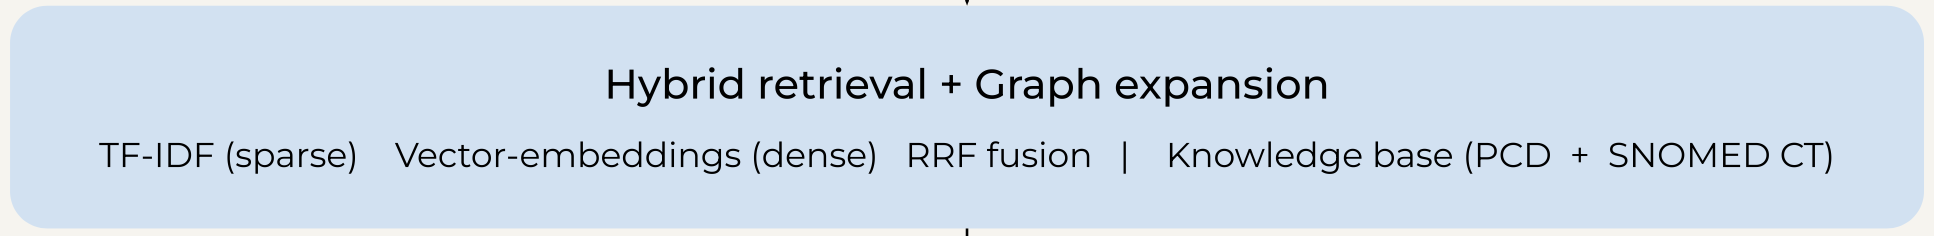

To answer complex clinical questions, the system must find the right data from a knowledge base of hundreds of enriched clusters. We chose a **Hybrid Retrieval Strategy** because clinical language is highly nuanced: the same concept can be expressed as a precise medical term ("atrial fibrillation"), an abbreviation ("AF"), or an informal synonym ("irregular heartbeat"). No single retrieval method handles all three well.

<br>

**Why hybrid?**

| Method | Strength | Limitation |
|--------|----------|------------|
| **Sparse (TF-IDF)** | Exact keyword match; fast and deterministic | Misses synonyms and paraphrases |
| **Dense (`nomic-embed-text-v1.5`)** | Captures semantic similarity; handles synonyms | Can miss rare, precise clinical terms |
| **Hybrid (RRF)** | Combines both signals; robust across query types | Slightly higher computational cost |


<br>


We use **Reciprocal Rank Fusion (RRF)** to combine the rankings — rather than combining raw scores (which are on incomparable scales), we combine ranks. This is simple, well-established, and works well in practice.

RRF combines sparse and dense rankings.
A chunk scores highly if it ranks well in either or both lists.

$ RRF score = 1/(k + sparse rank) + 1/(k + dense rank) $

$ k=60 $ is a standard smoothing constant.

This avoids the problem of TF-IDF and cosine similarity scores being on incomparable scales as ranks are always comparable.

In [ ]:
data_config = config["data"]

In [ ]:
retrieval_config = config["retrieval"]

In [ ]:
# Load Chunks
chunks_path = f"{DRIVE_DATA_DIR}/processed/pcd_snomed_enriched_50codes_chunks_dual_text_6axes.json"
with open(chunks_path, "r", encoding="utf-8") as f:
    chunks = json.load(f)

# Convert to DataFrame for inspection
chunks_df = pd.DataFrame([
    {
        "chunk_id": chunk["chunk_id"],
        "cluster_id": chunk["cluster_id"],
        "cluster_desc": chunk["cluster_desc"],
        "is_subchunk": chunk["is_subchunk"],
        "part": chunk["part"],
        "total_parts": chunk["total_parts"],
        "code_count": chunk["code_count"],
        "text_length": len(chunk["text"]),
        "text_dense_length": len(chunk.get("text_dense", "")),
    }
    for chunk in chunks
])


In [ ]:
chunks_df.head(3)

In [ ]:
chunks_df.shape

In [ ]:
chunks_df["text_length"].describe()

In [ ]:
chunks_df["text_dense_length"].describe()

In [ ]:
# Lookup dict for metadata access at retrieval time
chunk_lookup = {chunk["chunk_id"]: chunk for chunk in chunks}

In [ ]:
chunk_lookup['CVDPCAPU_COD']

In [ ]:
# Extract the texts that will be indexed - SPARSE
all_texts = [chunk["text"] for chunk in chunks]
# Extract the texts that will be indexed - DENSE
# fallback to "text" so chunk files without "text_dense" still work
all_texts_dense = [chunk.get("text_dense", chunk["text"]) for chunk in chunks]

all_ids = [chunk["chunk_id"] for chunk in chunks]

## Embedding

**Sparse Retrieval — TF-IDF**

TF-IDF (Term Frequency-Inverse Document Frequency) measures how distinctive a term is within a chunk relative to the whole corpus. A term that appears frequently in one chunk but rarely in others receives a high weight, making it a strong retrieval signal for exact clinical terminology.

*Key design choice:* `n-gram range` and `max_df`/`min_df` thresholds are set in `CONFIGURATION`. The n-gram upper bound captures multi-word clinical phrases (e.g. "type 2 diabetes mellitus").

In [ ]:
# Sparse retrieval (TF-IDF)
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=retrieval_config["tf_idf"]["ngram_range"],
    max_df=retrieval_config["tf_idf"]["max_df"],
    min_df=retrieval_config["tf_idf"]["min_df"],
    sublinear_tf=retrieval_config["tf_idf"]["sublinear_tf"],
)

In [ ]:
# Fit and transform all chunk texts into a sparse TF-IDF matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(all_texts)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)} terms")

**Dense Retrieval (Embeddings)**  
Embeddings map text to dense vector representations such that semantically similar passages are geometrically close. This allows the retrieval system to find a chunk about "atrial fibrillation" even when the query uses "AF" or "irregular heartbeat".


**Why `nomic-embed-text-v1.5`?**

- The primary reason: **context window**  
Our chunks contain up to 50 SNOMED codes with descriptions, synonyms, and relationship metadata. Standard embedding models (like all-MiniLM-L6-v2) have a 512 token limit and they would silently truncate most of the chunks, losing the clinical context that makes retrieval meaningful.

`nomic-embed-text-v1.5` is 8192 context length text encoder that surpasses OpenAI `text-embedding-ada-002` and `text-embedding-3-small` performance on short and long context tasks.

Other reasons:
- Requires **task instruction prefixes** (`search_document:` for indexing, `search_query:` for retrieval). This explicitly improves RAG performance by telling the model which mode it is operating in
- **Fully open source:** weights, training code, and training data are all public, which supports auditability and reproducibility.

In [ ]:
# Load once — outside all functions
embedding_model = SentenceTransformer(
    retrieval_config["embedding"]["model"],
    trust_remote_code=retrieval_config["embedding"]["trust_remote_code"],
    device=retrieval_config["embedding"]["device"]
)

In [ ]:
# # Build the dense index (Save the output)
# dense_index, dense_ids = build_dense_index(
#     all_texts_dense,
#     all_ids,
#     retrieval_config["embedding"],
#     embedding_model
# )

# print(f"Dense index shape: {dense_index.shape}")
# print(f"Successfully embedded: {len(dense_ids)}")
# print(f"Skipped: {len(all_texts) - len(dense_ids)}")

In [ ]:
# # Save dense index and ids
# np.save(f"{EMBDNG_DIR}/dense_index_50codes_6axes.npy", dense_index)

# with open(f"{EMBDNG_DIR}/dense_ids_50codes_6axes.json", "w") as f:
#     json.dump(dense_ids, f)

In [ ]:
# !git add {EMBDNG_DIR}/dense_index_50codes_6axes.npy
# !git commit -m "updated dense index - 6axes"
# !git push origin improved-pipeline

In [ ]:
# !git add {EMBDNG_DIR}/dense_ids_50codes_6axes.json
# !git commit -m "updated dense index - 6axes"
# !git push origin improved-pipeline

In [ ]:
# Load dense index and ids
dense_index = np.load(f"{EMBDNG_DIR}/dense_index_50codes_6axes.npy")

with open(f"{EMBDNG_DIR}/dense_ids_50codes_6axes.json") as f:
    dense_ids = json.load(f)

Reproducibility is achieved by saving the dense embeddings and loading it at runtime — so the knowledge base vectors are fixed across all runs.

## Retrieving

In [ ]:
data_config = config["data"]

In [ ]:
retrieval_config = config["retrieval"]

In [ ]:
# Run all retrieval methods on each test query
for query in retrieval_config["test_queries"]:
    sparse_results = retrieve_sparse(query, retrieval_config["retrieving"], chunk_lookup, tfidf_vectorizer, tfidf_matrix)
    dense_results  = retrieve_dense(query, retrieval_config["retrieving"], chunk_lookup, dense_index, dense_ids, embedding_model)
    hybrid_results = retrieve_hybrid(query, retrieval_config["retrieving"], chunk_lookup, tfidf_vectorizer, tfidf_matrix, dense_index, dense_ids, embedding_model)
    expanded_results = retrieve_with_graph_expansion(query, retrieval_config["retrieving"], chunk_lookup, tfidf_vectorizer, tfidf_matrix, dense_index, dense_ids, embedding_model)

    print(f"{'═' * 70}\n")
    print_results(query + " [SPARSE]",  sparse_results)
    print_results(query + " [DENSE]",   dense_results)
    print_results(query + " [HYBRID]",  hybrid_results)
    print_results(query + " [EXPANDED]", expanded_results)
    print(f"{'═' * 70}\n")

In [ ]:
# Test an input for LLM
hybrid_results

Inspecting a sample hybrid retrieval result and a chunk from the lookup to verify the structure before passing to the LLM.

In [ ]:
hybrid_results[0]

In [ ]:
chunk_lookup["CVDPCAPU_COD"]

# LLM

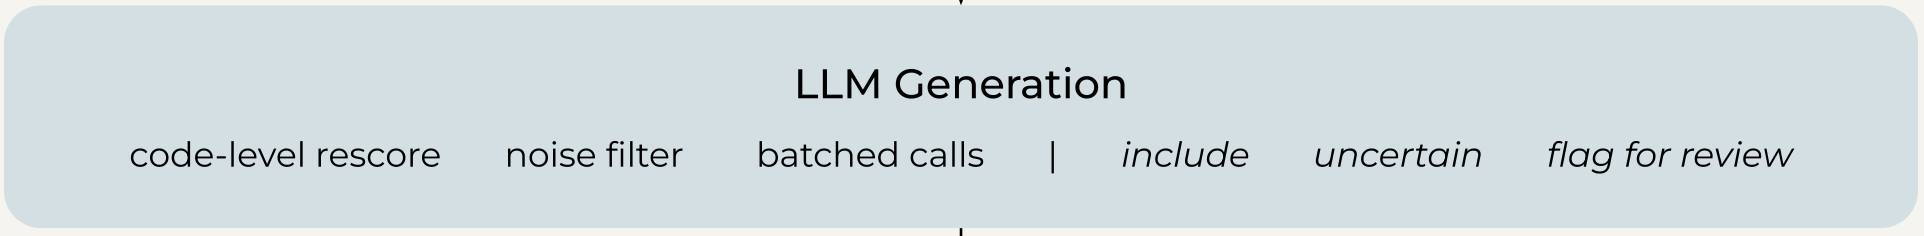

The LLM takes the list of rescored candidate codes from the retrieval system and, together with a structured system prompt, generates a justified clinical codelist.

For each research question the system produces:
- A list of **recommended SNOMED codes** with their exact descriptions, source cluster, synonyms, and relationship taxonomy — all copied exactly from the retrieved candidates.
- A **confidence flag** per code: `include` (unambiguous match), `uncertain` (plausibly relevant but context-dependent), or `flag_for_review` (retrieved chunk scored highly but this specific code is a mismatch or out of scope).
- A **clinical justification** for every code.
- A **`flagged_for_exclusion`** list for entire clusters that are false positives, with a written explanation.
- A **`notes`** field that must explicitly name any clinical concept from the research question that had no relevant codes in the retrieved candidates.

**Model: Microsoft Phi-4 (14B)**

For the generative step, we selected **Microsoft Phi-4** (14B parameters).


- **Instruction following**: Phi-4 consistently follows complex, multi-constraint system prompts, including the strict "only recommend codes from the provided context" constraint that makes outputs auditable.
- **Clinical reasoning**: achieves strong performance on medical reasoning benchmarks despite its relatively small size, outperforming much larger models on structured generation tasks.
- **Runs entirely locally** via Ollama. No patient-proximate data leaves the environment — a hard requirement for NHS clinical informatics workloads.


*Key design choice:*
- **`temperature=0`:** We set `temperature = 0`. Clinical codelists must be deterministic and reproducible. We do not want the model to be "creative." A deterministic output ensures that running the same query twice produces the same codelist — a prerequisite for clinical defensibility and regulatory audit.

  Although the knowledge base vectors are fixed across all runs, query embeddings are computed fresh each run, which introduces negligible variance. With LLM steps fully deterministic at temperature=0, and for practical purposes, the pipeline produces identical results across runs on the same codebase.

- **Strict Formatting:** The prompt forces the LLM to output a structured JSON object. This is essential for integrating the output directly into the next step.
- **Human-in-the-Loop:** We instruct the LLM to assign confidence flags (`include`, `uncertain`, `flag_for_review`). This aligns perfectly with real-world analyst workflows, highlighting exactly where the human expert needs to spend their time verifying the results.

**Prompt Design** - [*Reviewer*](https://colab.research.google.com/drive/1kEcwjSighP3DtwGx7dB-6QqYyeYe6l-S#scrollTo=3Wy1-fq8mZQy&line=1&uniqifier=1)

To ensure the LLM generates safe, auditable, and highly accurate codelists, we heavily engineered the `System Prompt`. Rather than asking the LLM to "search for codes" (which often leads to hallucinations), we positioned it as a **Senior Clinical Analyst** whose only job is to review and justify the codes already found by our hybrid retrieval system.

*Key design choices:*

- **Anti-Hallucination Constraints:** The model is strictly forbidden from inventing codes or relying on its underlying training data. It must copy the exact SNOMED ID from the retrieved text.
- **Code Relevance Score as a prior, not a decision**: each candidate is passed with both a cluster-level RRF score and a blended code-level score. The prompt instructs the model to treat scores above 0.7 as strong matches to evaluate for `include`, and scores below 0.3 as weak matches requiring scrutiny — but never to exclude a code on score alone.
- **Exclusion handling**: if the prompt contains an `EXPLICIT EXCLUSIONS DETECTED` block (pre-seeded from the query router), any code that directly identifies a patient as having the excluded condition must be flagged `flag_for_review`. Monitoring or procedure codes related to the excluded condition are not automatically flagged.
- **Structured & Auditable Output:** The prompt dictates a strict JSON response. It forces the LLM to assign a confidence flag (`include`, `uncertain`, `flag_for_review`) and write a human-readable clinical justification for every single code. This ensures the output is fully transparent and easily integrated into downstream data workflows.
- **`notes` field obligation**: the model must explicitly name any clinical concept from the research question for which no relevant codes were found in the candidates — forcing the model to surface retrieval gaps rather than silently omitting them.

- **Built-in Clinical Safeguards:** We explicitly programmed the prompt to avoid the most common real-world clinical coding errors:

  - **Cluster name trap**: the prompt explicitly warns the model not to reject a candidate code because its source cluster name seems unrelated. Each code must be evaluated on its own description, not its cluster's name.
  - **Context trap**: the model is instructed to distinguish between a code representing an active diagnosis versus "history of", "suspected", or "referral for" the condition — except when the research question explicitly targets vaccination or immunisation records.

In [ ]:
llm_config = config["llm"]

In [ ]:
retrieval_config = config["retrieval"]

In [ ]:
!ollama list

In [ ]:
# Tokeniser to estimate tokens
llm_tokeniser = AutoTokenizer.from_pretrained("microsoft/phi-4")

In [ ]:
# Test the LLM response
llm_output = get_codelist(retrieval_config["test_queries"][0], hybrid_results, llm_config, chunk_lookup, retrieval_config, exclusions=None)
llm_output

**Output Parsing**

The LLM is instructed to return only JSON, but may occasionally include markdown code fences or whitespace. We strip these before parsing. The parser returns a structured dictionary with `recommended_codes` and `flagged_for_exclusion` lists.

In [ ]:
# Test the parsed LLM response
parse_codelist_response(llm_output)

# RAG Pipeline


**Full RAG Pipeline**

This step combines our hybrid retrieval system and the LLM generation into a single, cohesive function.

How it works and why it matters:
* **End-to-end non-agentic execution:** It takes the research question, retrieves the most relevant clinical code chunks, and feeds them directly into the LLM to generate the final codelist.

  retrieve >> generate >> parse

* **Full auditability & verification:** Rather than just returning the final answer, the pipeline returns the structured output together with the exact retrieved chunks. This allows the user or clinical expert to inspect exactly what information the LLM used to make its decisions. This guarantees full transparency and prevents the AI from acting as a black box, which is critical for clinical governance.

In [ ]:
llm_config = config["llm"]

In [ ]:
!ollama list

In [ ]:
# Test the full RAG pipeline
test_queries = config["retrieval"]["test_queries"]

results = {}
for query in test_queries:
    print(f"Processing: {query}")
    results[query] = generate_codelist(query, retrieval_config, llm_config, chunk_lookup)
    print_codelist(results[query])


In [ ]:
# Flatten all results to a single DataFrame for inspection
all_codes_df = pd.concat(
    [codelist_to_df(r) for r in results.values()],
    ignore_index=True
)

In [ ]:
all_codes_df.head(10)

In [ ]:
all_codes_df.shape

In [ ]:
# Confidence flag distribution across all queries
all_codes_df["confidence"].value_counts()

In [ ]:
# Codes per research question
all_codes_df.groupby("research_question")["snomed_code"].count()

# ReAct-style Agentic Loop

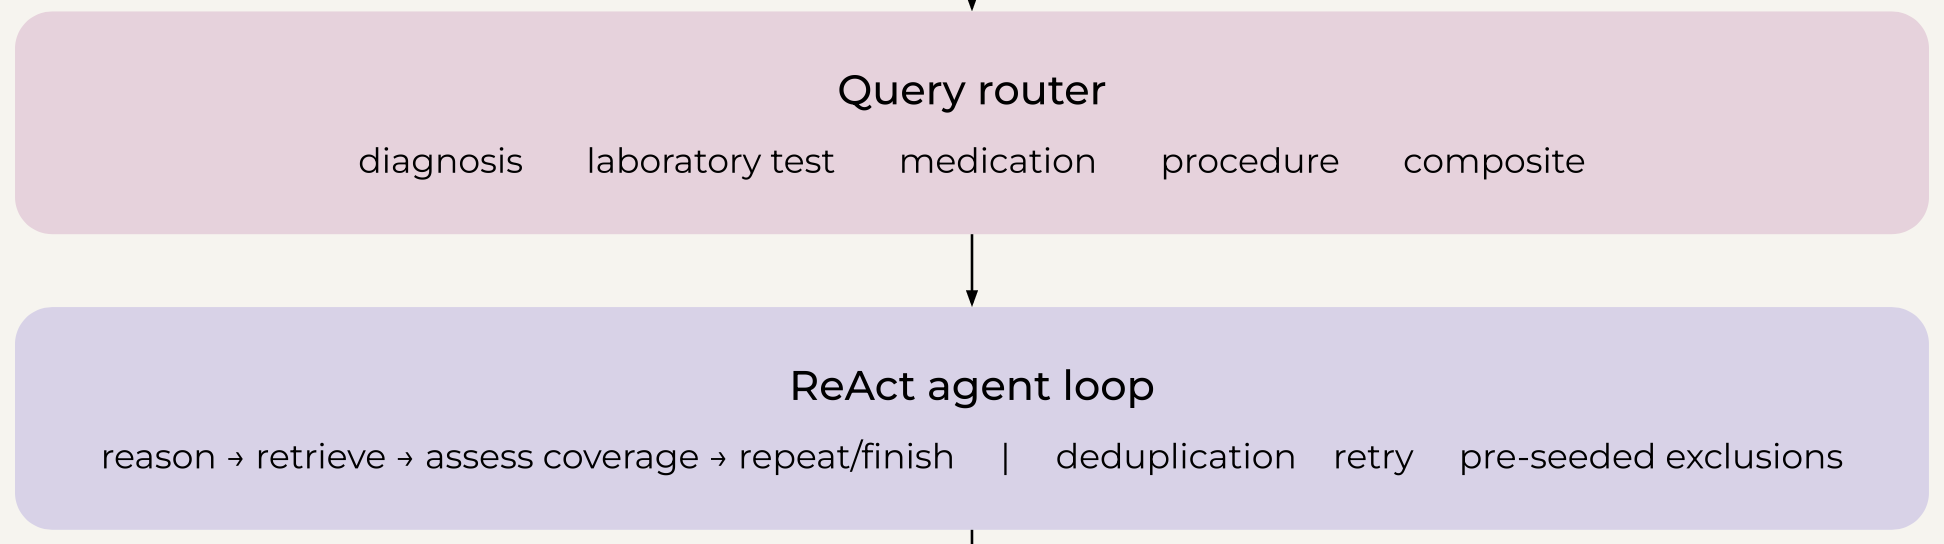

**From single-pass to iterative reasoning**

The single-pass RAG pipeline retrieves once and generates once. For complex, multi-concept clinical questions, this is insufficient: a research question about "DOACs in patients with AF and mechanical heart valves" spans at least three distinct concept clusters, and a single query vector may not retrieve all of them equally well.

We implemented a **ReAct (Reasoning + Acting)** agent that operates as an iterative search loop mirroring the workflow of a human clinical expert.

The LLM issues one targeted sub-query per concept, assesses what has been retrieved so far, and decides whether to retrieve more or generate. This is more effective because clinical concepts that share no lexical overlap can be retrieved independently with concept-specific queries, and the accumulated context grows step by step.


This loop is implemented from scratch rather than using a framework such as LangChain, giving us precise control over termination conditions, token budgeting, and audit logging.

The loop executes the following sequence:

**1. Query classification (step 0)**
Before the loop begins, `classify_query()` is called to produce a routing plan: query type, ordered sub-concepts with their primary SNOMED axes, explicit exclusions, and a complexity label. Exclusions identified by the router are pre-seeded into `found_exclusions` immediately — the agent does not need to rediscover them. The `complexity` label (`simple`, `moderate`, `complex`) is used to look up the corresponding `max_steps` ceiling from `agent_config`, so complex queries are automatically granted more retrieval steps.

**2. Reasoning loop (steps 1…N)**
At each step, `agent_step()` is called with the full current state (research question, routing plan, seen queries, retrieved clusters so far). The LLM responds with one of two actions:

- `retrieve`: a targeted sub-query is issued via `retrieve_with_graph_expansion()`. The number of **new** chunk IDs not seen in any previous step is counted. If fewer than `agent_config["min_new_chunks"]` new chunks are returned and the agent has already retrieved something, a warning is printed but the loop continues — the agent itself decides whether to keep searching.
- `generate`: the agent signals that coverage is sufficient. It also returns an `exclusions` list, which is merged with the router's pre-seeded exclusions into a single deduplicated `found_exclusions` list.

**3. Loop termination safeguards**
- **Hard step ceiling**: if `step > max_steps`, the loop breaks and generation is forced with whatever has been accumulated. The ceiling is complexity-dependent.
- **Query deduplication**: before issuing a retrieval, the query is checked against `seen_queries`. If already used, the loop breaks immediately.
- **Empty query guard**: if `agent_step()` returns an empty `query` string, the step is skipped with `continue`.
- **Parse error exit**: if `agent_step()` returns a `parse_error` after all retries, the loop breaks and generation proceeds with accumulated context.
- **Unknown action exit**: any action string other than `retrieve` or `generate` breaks the loop.

**4. Post-loop: parent concept expansion**
After the loop terminates, the `is_a` relationships of all codes in the accumulated chunks are inspected. Parent concept terms not already in `seen_queries` are collected and used for up to 10 additional `retrieve_with_graph_expansion()` calls, adding parent-level clusters that the agent may not have explicitly searched for.

**5. Code-level rescoring across all chunks**
`rescore_codes()` is run across all accumulated chunks. This ensures that a highly relevant individual code inside a lower-ranked chunk is not discarded by chunk-level trimming before the LLM ever sees it.

**6. Noise filtering and batching**
Codes with a `blended_score` below `agent_config["min_blended_score"]` (0.15) are discarded. The remaining codes are packed into token-budget-sized batches using `build_batches()`: codes are added in blended-score order until the next code would exceed the budget, at which point a new batch begins.

**7. Batched LLM generation**
Each batch is sent to the LLM as a separate `ollama.chat()` call using `SYSTEM_PROMPT`. Results from all batches are merged: `recommended_codes` are deduplicated by `snomed_code`, keeping the most confident assignment (ranked `include` > `uncertain` > `flag_for_review`). `flagged_for_exclusion` clusters are deduplicated by `cluster_id`.

**8. Audit trail**
Every step — classification, each retrieval decision, termination reason, token budget, batch sizes — is recorded in `agent_log` and returned in the result dictionary alongside the raw LLM responses, rescored code counts, and all retrieved chunks.

*Key design choices:*

**Reliability & loop control**
- **Complexity-dependent step ceiling**: rather than a single fixed `max_steps`, the ceiling is looked up from a map keyed by the router's complexity label. Simple queries get fewer steps; complex multi-concept queries get more.
- **Query deduplication**: if the agent tries to issue a query already in `seen_queries`, the loop breaks immediately — preventing the most common stuck-state pattern.
- **No new information guard**: if a retrieval step returns zero unique chunks, the agent is warned and decides whether to continue.
- **Retry with backoff**: `agent_step()` retries JSON parsing failures up to `max_retries` times before returning a graceful fallback, preventing a single malformed response from aborting the run.

**Retrieval quality**
- **Pre-seeded exclusions from the router**: explicit exclusions identified at classification time are injected into `found_exclusions` before the loop starts — the agent does not spend retrieval steps re-discovering them.
- **Code-level rescoring before any trimming**: `rescore_codes()` is applied to all accumulated chunks before batching, ensuring the ranking passed to the LLM reflects individual code relevance, not just chunk-level RRF scores.
- **Noise threshold before batching**: codes below `min_blended_score` are discarded before any LLM call, reducing noise without relying on the LLM to filter low-quality candidates.

**Generation**
- **Batched generation**: all codes above the noise threshold are packed into token-budget-sized batches, each sent as a separate LLM call. Confidence conflicts across batches are resolved by keeping the most confident assignment (`include` > `uncertain` > `flag_for_review`).
- **Full audit trail**: the result dictionary includes `agent_log`, `retrieved_queries`, `n_chunks_total`, `n_codes_rescored`, `n_codes_filtered`, `n_llm_batches`, `codes_passed_to_llm`, and raw LLM responses for every batch.

**Prompt Design** - [*Searcher*](https://colab.research.google.com/drive/1kEcwjSighP3DtwGx7dB-6QqYyeYe6l-S#scrollTo=KKGtdBDxNA-J&line=3&uniqifier=1)


The Searcher prompt teaches the agent how to translate SNOMED relationship axes into targeted query strings. The router assigns `primary_axes` per sub-concept — but those axis names alone do not tell the agent what to search for. The prompt provides a worked example for each axis, making the translation rule explicit:

- `is_a`: search for the concept name directly
- `finding_site`: search for the anatomical structure name, not the disease name
- `ingredient`: search for the specific drug name, not the drug class
- `investigation`: search for what is being measured, not the test name
- `causative_agent`: search for the organism or substance name, not the disease name
- `procedure_site`: search for the anatomical structure name, not the procedure name
- `course`: search for the clinical course descriptor directly
- `method`: search for the procedure method name directly
- `laterality`: search for the anatomical structure with its side
- `associated_with`: search for the directly associated clinical concept
- `pathological_process`: search for the pathological process name directly

The axis tells the agent *what* to search for — the query itself must contain only the clinical concept, because the retrieval system is a text similarity search, not a structured query engine.


The prompt requires agent to try synonyms or abbreviations if an initial query returns poor results.


Why a Custom ReAct Agent and not LangChain?

`LangChain` is a framework that handles agent logic automatically. It is useful for getting something working quickly but for this project we needed more control.

Why we built our own:

- **Auditability:** NICE needs to know exactly why each code was recommended. Our agent records every reasoning step in `agent_log`: what it searched for, what it found, what it excluded and why. LangChain hides most of this internally.
- **Control:** our retrieval layer is specifically designed for clinical coding (hybrid TF-IDF + embeddings + RRF). Wrapping it inside a framework would make it harder to inspect and debug.
- **Cost & Speed:** LangChain makes more LLM calls than necessary. In our solution the step cap is resolved dynamically from the router's complexity label. This logic is straightforward to implement explicitly within a custom solution.


The trade-off we accept:  
Our solution is more fragile. It can break if the model produces unexpected output. We handle this with retries and JSON repair logic, but a production system would need more robust error handling. A LangChain agent would probably handle edge cases more gracefully.





In [ ]:
retrieval_config = config["retrieval"]

In [ ]:
llm_config = config["llm"]

In [ ]:
agent_config = config["agent"]

In [ ]:
router_config = config["query_router"]

In [ ]:
# Tokeniser to estimate tokens
llm_tokeniser = AutoTokenizer.from_pretrained("microsoft/phi-4")

In [ ]:
!ollama list

In [ ]:
# Test the ReAct Loop
agent_results = {}


for question, question_path in benchmarks.items():
    agent_results[question] = run_agent(
        question, retrieval_config,
        llm_config, agent_config,
        router_config, chunk_lookup, verbose=True
    )
    print_agent_result(agent_results[question])
    # Save the agent's output for each question
    file_name = f"{question[:10]}...{question[-10:]}"
    with open(f"{RESULTS_DIR}/q_{file_name}.json", "w", encoding="utf-8") as f:
        json.dump({question: agent_results[question]}, f, ensure_ascii=False, indent=2)

In [ ]:
# # Save the agent's output for all questions
# with open(f"{RESULTS_DIR}/improved_agent_results_benchmarks_6axes_code_score_agent_final.json", "w", encoding="utf-8") as f:
#     json.dump(agent_results, f, ensure_ascii=False, indent=2)

In [ ]:
# !git add {RESULTS_DIR}/improved_agent_results_benchmarks_6axes_code_score_agent_final.json
# !git commit -m "Final results"
# !git push origin improved-pipeline

In [ ]:
# Load the agent's output
with open(f"{RESULTS_DIR}/improved_agent_results_benchmarks_6axes_code_score_agent_final.json", "r", encoding="utf-8") as f:
    agent_results = json.load(f)

In [ ]:
# Flatten to DataFrame
agent_codes_df = pd.concat(
    [codelist_to_df(r) for r in agent_results.values()], ignore_index=True)

In [ ]:
agent_codes_df.head(10)

In [ ]:
agent_codes_df.tail(10)

In [ ]:
agent_codes_df.shape

In [ ]:
all_snomed_codes = agent_codes_df[["research_question","snomed_code"]]
all_snomed_codes

# Evaluation & Verification

To verify our results, we evaluate the agent's output against expert-curated codelists from [OpenCodelists](https://www.opencodelists.org/), maintained by the Bennett Institute for Applied Data Science (OpenSAFELY). These are peer-reviewed, version-controlled codelists used in published NHS research studies.

For each benchmark, `evaluate_against_benchmark()` produces 3 diagnostic layers:

  - **Layer 1 — Knowledge Base Coverage:** what fraction of benchmark codes exist anywhere in the knowledge base. This is the hard ceiling — a code absent from the knowledge base cannot be recommended regardless of retrieval or LLM quality. Low coverage signals a *data-scope* problem, not a pipeline failure. (`kb_gap`)

  - **Layer 2 — Retrieval vs Generation Diagnosis**  
  For each benchmark cluster (a cluster that contains at least one benchmark code), the function classifies it into one of three states:
    - **Never retrieved** — retrieval failed entirely; the cluster never reached the LLM. (`retrieval_failure`)
    - **Retrieved & passed to LLM** — retrieval succeeded and the cluster's codes were passed to the LLM.
    - Cluster was retrieved but none of its codes survived the `min_blended_score` noise filter to be included in any LLM batch.


  - **Layer 3 — Overall Precision, Recall & F1** strict exact-match metrics computed separately for all recommended codes, `include + uncertain`, and `include` only. The tiered view makes the precision-recall trade-off explicit: the `include-only` tier will have higher precision but lower recall.
    - **All recommended** — every code the agent output, regardless of flag.
    - **Include + uncertain** — excludes `flag_for_review` codes (reduces noise).
    - **Include only** — the strictest tier; the final recommended codelist a clinical analyst would use.

This tiered view makes the precision-recall trade-off explicit: the `include-only` tier will have higher precision but lower recall than `all recommended`.


**Failure Mode Taxonomy:** Each missed benchmark code is assigned a root cause:
- `kb_gap` — code not present anywhere in the knowledge base
- `retrieval_failure` — code is in the knowledge base but its cluster was never retrieved
- `llm_rejection` — code's cluster was retrieved but the code was not recommended. This category currently also includes codes whose cluster was retrieved but dropped by the `min_blended_score` filter before reaching the LLM. Cross-referencing with Layer 2 helps separate the two cases.



**Why this framework?**  
A single recall number is not informative for a clinical system. 30% recall could mean the knowledge base is missing 70% of benchmark codes, or the pipeline is failing to find codes that are right there. These are very different problems with very different solutions. The layered framework identifies exactly which problem — and at which stage — is responsible for each missed code.


**Limitations**

- The evaluation uses strict exact code ID comparison only. A code recommended by the agent that is semantically equivalent but differs in SNOMED release version will count as a false positive, and the benchmark code will count as a false negative. This likely underestimates true recall, particularly for queries where the benchmark was built on an older SNOMED release than the one used in our knowledge base.

- OpenCodelists benchmarks were built manually by clinical experts. A direct comparison will always be conservative — our goal is not to replicate them exactly, but to produce a defensible first-draft codelist that materially reduces the manual effort required.


## Industry standards for evaluation metrics

While no specific insdustry requirements for the level of recall, precision and F1 were indetified, the literature research has shown that RAG and LLM-based systems which handle tasks related to clinical code retrieval typically aim for recall 70-90% to avoid missing critical codes and precision 60-85% to minimize false negatives (missed cases), and F1 65-85%

Yalcinkaya A. (2025) “Applying machine learning to enhance core outcome set development: automating the data extraction and classification of outcomes”, 7 Nov. Available at https://pmc.ncbi.nlm.nih.gov/articles/PMC12595633/

Park Y. (2026) "Development and Evaluation of SNOMED CT Automated Mapping Tool: Advancing Terminology Standardization and Semantic Interoperability", Feb. Available at https://pubmed.ncbi.nlm.nih.gov/41802230/

In a differed paper

[Sookyung.H (2025) "Comparative Analysis of ChatGPT-4 for Automated Mapping of Local Medical Terminologies to SNOMED CT" May. Available at https://pubmed.ncbi.nlm.nih.gov/40380580/]
it's shown that a system which matched hospital terms with SNOMED CT codes using RAG with ChatGPT-4, has a match rate (roughly equal to precision) of 96.2% for returning a valid SNOMED CT term, and 57.6% overall exact match rate.

In [ ]:
eval_config  = config["evaluation"]

In [ ]:
eval_results = {}

## Benchmark 1a, 1b, 1c (same questions different wordings)

**Benchmark 1a**

In [ ]:
# Benchmark 1a
i = 0
question, question_path = list(benchmarks.items())[i]
benchmark_df = pd.read_csv(question_path, dtype=str)
# Agent's output
agent_result = agent_results[question]

In [ ]:
print(question)

In [ ]:
benchmark_df.head()

In [ ]:
# Evaluation
eval_results[question] = evaluate_against_benchmark(
    agent_result,
    benchmark_df,
    eval_config,
    chunks,
    preferred_terms,
)

In [ ]:
# Benchmark 1b
i = 1
question, question_path = list(benchmarks.items())[i]
benchmark_df = pd.read_csv(question_path, dtype=str)
# Agent's output
agent_result = agent_results[question]

In [ ]:
print(question)

In [ ]:
benchmark_df.head()

In [ ]:
# Evaluation
eval_results[question] = evaluate_against_benchmark(
    agent_result,
    benchmark_df,
    eval_config,
    chunks,
    preferred_terms,
)

**Benchmark 1c**

In [ ]:
# Benchmark 1c
i = 2
question, question_path = list(benchmarks.items())[i]
benchmark_df = pd.read_csv(question_path, dtype=str)
# Agent's output
agent_result = agent_results[question]

In [ ]:
print(question)

In [ ]:
benchmark_df.head()

In [ ]:
benchmark_df = benchmark_df.rename(columns={
    "id": "code",
    "name": "term"
})

In [ ]:
# Evaluation
eval_results[question] = evaluate_against_benchmark(
    agent_result,
    benchmark_df,
    eval_config,
    chunks,
    preferred_terms,
)

In [ ]:
if eval_results[question]is None:
    print("Evaluation skipped: The agent did not return any recommended codes to evaluate.")
else:
    # Knowledge base coverage gap
    n_benchmark = eval_results[question]['benchmark_codes']
    n_in_kb     = eval_results[question]['kb_codes']
    n_missing   = n_benchmark - n_in_kb

    # List the missing codes
    found_codes     = set(eval_results[question]['found_in_kb_df']['snomed_code']) if not eval_results[question]['found_in_kb_df'].empty else set()
    missing_codes   = set(benchmark_df[eval_config['benchmark_code_col']].str.strip()) - found_codes

    if missing_codes:
        missing_df = benchmark_df[benchmark_df[eval_config['benchmark_code_col']].str.strip().isin(missing_codes)]
        missing_df = missing_df[[eval_config['benchmark_code_col'], eval_config['benchmark_description_col']]].reset_index(drop=True)
        print('Codes not in knowledge base:')
        print(missing_df.to_string(index=False))
    else:
        print('All benchmark codes are present in the knowledge base.')


    print(f'Benchmark codes total  : {n_benchmark}')
    print(f'Found in knowledge base: {n_in_kb}  ({eval_results[question]["kb_coverage"]:.1%})')
    print(f'Missing from KB        : {n_missing}  ({1 - eval_results[question]["kb_coverage"]:.1%})')
    print(f'Max achievable recall  : {eval_results[question]["kb_coverage"]:.1%}')
    print()


### 🔹 Insights

Even with temperature=0, LLMs are sensitive to input length and phrasing:

Context Weight: Question 1 is long, highly technical, and reads like a strict database query. This nudges the model into a rigid, analytical state, making it more likely to output strict code/JSON.

Conversational Trigger: Question 2 is shorter and reads more like a natural sentence ("...to people with..."). This shorter phrasing likely triggered the model's instruction-tuning bias, causing it to fall back into its default conversational mode ("To address the research question effectively, we need to...").

The Cut-off: Notice that the raw output just stops at (Direct Oral An. This usually means the model either crashed mid-generation or, because it wasted tokens on the preamble, it hit a generation snag.

## Benchmark 2a & 2b (same questions different wordings)

**Benchmark 2a**

In [ ]:
# Benchmark 2a
i = 3
question, question_path = list(benchmarks.items())[i]
benchmark_df = pd.read_csv(question_path, dtype=str)
# Agent's output
agent_result = agent_results[question]

In [ ]:
print(question)

In [ ]:
benchmark_df.head()

In [ ]:
benchmark_df = benchmark_df.rename(columns={
    "id": "code",
    "name": "term"
})

In [ ]:
# Evaluation
eval_results[question] = evaluate_against_benchmark(
    agent_result,
    benchmark_df,
    eval_config,
    chunks,
    preferred_terms,
)

**Benchmark 2b**

In [ ]:
# Benchmark 2b
i = 4
question, question_path = list(benchmarks.items())[i]
benchmark_df = pd.read_csv(question_path, dtype=str)
# Agent's output
agent_result = agent_results[question]

In [ ]:
print(question)

In [ ]:
benchmark_df.head()

In [ ]:
benchmark_df = benchmark_df.rename(columns={
    "id": "code",
    "name": "term"
})

In [ ]:
# Evaluation
eval_results[question] = evaluate_against_benchmark(
    agent_result,
    benchmark_df,
    eval_config,
    chunks,
    preferred_terms,
)

In [ ]:
if eval_results[question]is None:
    print("Evaluation skipped: The agent did not return any recommended codes to evaluate.")
else:
    # Knowledge base coverage gap
    n_benchmark = eval_results[question]['benchmark_codes']
    n_in_kb     = eval_results[question]['kb_codes']
    n_missing   = n_benchmark - n_in_kb

    # List the missing codes
    found_codes     = set(eval_results[question]['found_in_kb_df']['snomed_code']) if not eval_results[question]['found_in_kb_df'].empty else set()
    missing_codes   = set(benchmark_df[eval_config['benchmark_code_col']].str.strip()) - found_codes

    if missing_codes:
        missing_df = benchmark_df[benchmark_df[eval_config['benchmark_code_col']].str.strip().isin(missing_codes)]
        missing_df = missing_df[[eval_config['benchmark_code_col'], eval_config['benchmark_description_col']]].reset_index(drop=True)
        print('Codes not in knowledge base:')
        print(missing_df.to_string(index=False))
    else:
        print('All benchmark codes are present in the knowledge base.')


    print(f'Benchmark codes total  : {n_benchmark}')
    print(f'Found in knowledge base: {n_in_kb}  ({eval_results[question]["kb_coverage"]:.1%})')
    print(f'Missing from KB        : {n_missing}  ({1 - eval_results[question]["kb_coverage"]:.1%})')
    print(f'Max achievable recall  : {eval_results[question]["kb_coverage"]:.1%}')
    print()


## Benchmark 3 & 4 (frequency & population)

**Benchmark 3**

In [ ]:
# Benchmark 3
i = 5
question, question_path = list(benchmarks.items())[i]
benchmark_df = pd.read_csv(question_path, dtype=str)
# Agent's output
agent_result = agent_results[question]

In [ ]:
print(question)

In [ ]:
benchmark_df.head()

In [ ]:
# Evaluation
eval_results[question] = evaluate_against_benchmark(
    agent_result,
    benchmark_df,
    eval_config,
    chunks,
    preferred_terms,
)

In [ ]:
if eval_results[question]is None:
    print("Evaluation skipped: The agent did not return any recommended codes to evaluate.")
else:
    # Knowledge base coverage gap
    n_benchmark = eval_results[question]['benchmark_codes']
    n_in_kb     = eval_results[question]['kb_codes']
    n_missing   = n_benchmark - n_in_kb

    # List the missing codes
    found_codes     = set(eval_results[question]['found_in_kb_df']['snomed_code']) if not eval_results[question]['found_in_kb_df'].empty else set()
    missing_codes   = set(benchmark_df[eval_config['benchmark_code_col']].str.strip()) - found_codes

    if missing_codes:
        missing_df = benchmark_df[benchmark_df[eval_config['benchmark_code_col']].str.strip().isin(missing_codes)]
        missing_df = missing_df[[eval_config['benchmark_code_col'], eval_config['benchmark_description_col']]].reset_index(drop=True)
        print('Codes not in knowledge base:')
        print(missing_df.to_string(index=False))
    else:
        print('All benchmark codes are present in the knowledge base.')


    print(f'Benchmark codes total  : {n_benchmark}')
    print(f'Found in knowledge base: {n_in_kb}  ({eval_results[question]["kb_coverage"]:.1%})')
    print(f'Missing from KB        : {n_missing}  ({1 - eval_results[question]["kb_coverage"]:.1%})')
    print(f'Max achievable recall  : {eval_results[question]["kb_coverage"]:.1%}')
    print()


**Benchmark 4**

In [ ]:
# Benchmark 4
i = 6
question, question_path = list(benchmarks.items())[i]
benchmark_df = pd.read_csv(question_path, dtype=str)
# Agent's output
agent_result = agent_results[question]

In [ ]:
print(question)

In [ ]:
benchmark_df.head()

In [ ]:
# Evaluation
eval_results[question] = evaluate_against_benchmark(
    agent_result,
    benchmark_df,
    eval_config,
    chunks,
    preferred_terms,
)

In [ ]:
if eval_results[question]is None:
    print("Evaluation skipped: The agent did not return any recommended codes to evaluate.")
else:
    # Knowledge base coverage gap
    n_benchmark = eval_results[question]['benchmark_codes']
    n_in_kb     = eval_results[question]['kb_codes']
    n_missing   = n_benchmark - n_in_kb

    # List the missing codes
    found_codes     = set(eval_results[question]['found_in_kb_df']['snomed_code']) if not eval_results[question]['found_in_kb_df'].empty else set()
    missing_codes   = set(benchmark_df[eval_config['benchmark_code_col']].str.strip()) - found_codes

    if missing_codes:
        missing_df = benchmark_df[benchmark_df[eval_config['benchmark_code_col']].str.strip().isin(missing_codes)]
        missing_df = missing_df[[eval_config['benchmark_code_col'], eval_config['benchmark_description_col']]].reset_index(drop=True)
        print('Codes not in knowledge base:')
        print(missing_df.to_string(index=False))
    else:
        print('All benchmark codes are present in the knowledge base.')


    print(f'Benchmark codes total  : {n_benchmark}')
    print(f'Found in knowledge base: {n_in_kb}  ({eval_results[question]["kb_coverage"]:.1%})')
    print(f'Missing from KB        : {n_missing}  ({1 - eval_results[question]["kb_coverage"]:.1%})')
    print(f'Max achievable recall  : {eval_results[question]["kb_coverage"]:.1%}')
    print()


## Benchmark 5 (exclusion)

**Benchmark 5**

In [ ]:
# Benchmark 5
i = 7
question, question_path = list(benchmarks.items())[i]
benchmark_df = pd.read_csv(question_path, dtype=str)
# Agent's output
agent_result = agent_results[question]

In [ ]:
print(question)

In [ ]:
benchmark_df.head()

In [ ]:
# Evaluation
eval_results[question] = evaluate_against_benchmark(
    agent_result,
    benchmark_df,
    eval_config,
    chunks,
    preferred_terms,
)

In [ ]:
if eval_results[question]is None:
    print("Evaluation skipped: The agent did not return any recommended codes to evaluate.")
else:
    # Knowledge base coverage gap
    n_benchmark = eval_results[question]['benchmark_codes']
    n_in_kb     = eval_results[question]['kb_codes']
    n_missing   = n_benchmark - n_in_kb

    # List the missing codes
    found_codes     = set(eval_results[question]['found_in_kb_df']['snomed_code']) if not eval_results[question]['found_in_kb_df'].empty else set()
    missing_codes   = set(benchmark_df[eval_config['benchmark_code_col']].str.strip()) - found_codes

    if missing_codes:
        missing_df = benchmark_df[benchmark_df[eval_config['benchmark_code_col']].str.strip().isin(missing_codes)]
        missing_df = missing_df[[eval_config['benchmark_code_col'], eval_config['benchmark_description_col']]].reset_index(drop=True)
        print('Codes not in knowledge base:')
        print(missing_df.to_string(index=False))
    else:
        print('All benchmark codes are present in the knowledge base.')


    print(f'Benchmark codes total  : {n_benchmark}')
    print(f'Found in knowledge base: {n_in_kb}  ({eval_results[question]["kb_coverage"]:.1%})')
    print(f'Missing from KB        : {n_missing}  ({1 - eval_results[question]["kb_coverage"]:.1%})')
    print(f'Max achievable recall  : {eval_results[question]["kb_coverage"]:.1%}')
    print()


## Benchmark 6-14 (simple)

**Benchmark 9**

In [ ]:
# Benchmark 9
i = 8
question, question_path = list(benchmarks.items())[i]
benchmark_df = pd.read_csv(question_path, dtype=str)
# Agent's output
agent_result = agent_results[question]

In [ ]:
print(question)

In [ ]:
benchmark_df.head()

In [ ]:
benchmark_df = benchmark_df.rename(columns={
    "id": "code",
    "name": "term"
})

In [ ]:
# Evaluation
eval_results[question] = evaluate_against_benchmark(
    agent_result,
    benchmark_df,
    eval_config,
    chunks,
    preferred_terms,
)

In [ ]:
if eval_results[question]is None:
    print("Evaluation skipped: The agent did not return any recommended codes to evaluate.")
else:
    # Knowledge base coverage gap
    n_benchmark = eval_results[question]['benchmark_codes']
    n_in_kb     = eval_results[question]['kb_codes']
    n_missing   = n_benchmark - n_in_kb

    # List the missing codes
    found_codes     = set(eval_results[question]['found_in_kb_df']['snomed_code']) if not eval_results[question]['found_in_kb_df'].empty else set()
    missing_codes   = set(benchmark_df[eval_config['benchmark_code_col']].str.strip()) - found_codes

    if missing_codes:
        missing_df = benchmark_df[benchmark_df[eval_config['benchmark_code_col']].str.strip().isin(missing_codes)]
        missing_df = missing_df[[eval_config['benchmark_code_col'], eval_config['benchmark_description_col']]].reset_index(drop=True)
        print('Codes not in knowledge base:')
        print(missing_df.to_string(index=False))
    else:
        print('All benchmark codes are present in the knowledge base.')


    print(f'Benchmark codes total  : {n_benchmark}')
    print(f'Found in knowledge base: {n_in_kb}  ({eval_results[question]["kb_coverage"]:.1%})')
    print(f'Missing from KB        : {n_missing}  ({1 - eval_results[question]["kb_coverage"]:.1%})')
    print(f'Max achievable recall  : {eval_results[question]["kb_coverage"]:.1%}')
    print()


**Benchmark 10**

In [ ]:
# Benchmark 10
i = 9
question, question_path = list(benchmarks.items())[i]
benchmark_df = pd.read_csv(question_path, dtype=str)
# Agent's output
agent_result = agent_results[question]

In [ ]:
print(question)

In [ ]:
benchmark_df.head()

In [ ]:
# Evaluation
eval_results[question] = evaluate_against_benchmark(
    agent_result,
    benchmark_df,
    eval_config,
    chunks,
    preferred_terms,
)

In [ ]:
if eval_results[question]is None:
    print("Evaluation skipped: The agent did not return any recommended codes to evaluate.")
else:
    # Knowledge base coverage gap
    n_benchmark = eval_results[question]['benchmark_codes']
    n_in_kb     = eval_results[question]['kb_codes']
    n_missing   = n_benchmark - n_in_kb

    # List the missing codes
    found_codes     = set(eval_results[question]['found_in_kb_df']['snomed_code']) if not eval_results[question]['found_in_kb_df'].empty else set()
    missing_codes   = set(benchmark_df[eval_config['benchmark_code_col']].str.strip()) - found_codes

    if missing_codes:
        missing_df = benchmark_df[benchmark_df[eval_config['benchmark_code_col']].str.strip().isin(missing_codes)]
        missing_df = missing_df[[eval_config['benchmark_code_col'], eval_config['benchmark_description_col']]].reset_index(drop=True)
        print('Codes not in knowledge base:')
        print(missing_df.to_string(index=False))
    else:
        print('All benchmark codes are present in the knowledge base.')


    print(f'Benchmark codes total  : {n_benchmark}')
    print(f'Found in knowledge base: {n_in_kb}  ({eval_results[question]["kb_coverage"]:.1%})')
    print(f'Missing from KB        : {n_missing}  ({1 - eval_results[question]["kb_coverage"]:.1%})')
    print(f'Max achievable recall  : {eval_results[question]["kb_coverage"]:.1%}')
    print()


**Benchmark 11**

In [ ]:
# Benchmark 11
i = 10
question, question_path = list(benchmarks.items())[i]
benchmark_df = pd.read_csv(question_path, dtype=str)
# Agent's output
agent_result = agent_results[question]

In [ ]:
print(question)

In [ ]:
benchmark_df.head()

In [ ]:
# Evaluation
eval_results[question] = evaluate_against_benchmark(
    agent_result,
    benchmark_df,
    eval_config,
    chunks,
    preferred_terms,
)

In [ ]:
if eval_results[question]is None:
    print("Evaluation skipped: The agent did not return any recommended codes to evaluate.")
else:
    # Knowledge base coverage gap
    n_benchmark = eval_results[question]['benchmark_codes']
    n_in_kb     = eval_results[question]['kb_codes']
    n_missing   = n_benchmark - n_in_kb

    # List the missing codes
    found_codes     = set(eval_results[question]['found_in_kb_df']['snomed_code']) if not eval_results[question]['found_in_kb_df'].empty else set()
    missing_codes   = set(benchmark_df[eval_config['benchmark_code_col']].str.strip()) - found_codes

    if missing_codes:
        missing_df = benchmark_df[benchmark_df[eval_config['benchmark_code_col']].str.strip().isin(missing_codes)]
        missing_df = missing_df[[eval_config['benchmark_code_col'], eval_config['benchmark_description_col']]].reset_index(drop=True)
        print('Codes not in knowledge base:')
        print(missing_df.to_string(index=False))
    else:
        print('All benchmark codes are present in the knowledge base.')


    print(f'Benchmark codes total  : {n_benchmark}')
    print(f'Found in knowledge base: {n_in_kb}  ({eval_results[question]["kb_coverage"]:.1%})')
    print(f'Missing from KB        : {n_missing}  ({1 - eval_results[question]["kb_coverage"]:.1%})')
    print(f'Max achievable recall  : {eval_results[question]["kb_coverage"]:.1%}')
    print()


**Benchmark 12**

In [ ]:
# Benchmark 12
i = 11
question, question_path = list(benchmarks.items())[i]
benchmark_df = pd.read_csv(question_path, dtype=str)
# Agent's output
agent_result = agent_results[question]

In [ ]:
print(question)

In [ ]:
benchmark_df.head()

In [ ]:
# Evaluation
eval_results[question] = evaluate_against_benchmark(
    agent_result,
    benchmark_df,
    eval_config,
    chunks,
    preferred_terms,
)

In [ ]:
if eval_results[question]is None:
    print("Evaluation skipped: The agent did not return any recommended codes to evaluate.")
else:
    # Knowledge base coverage gap
    n_benchmark = eval_results[question]['benchmark_codes']
    n_in_kb     = eval_results[question]['kb_codes']
    n_missing   = n_benchmark - n_in_kb

    # List the missing codes
    found_codes     = set(eval_results[question]['found_in_kb_df']['snomed_code']) if not eval_results[question]['found_in_kb_df'].empty else set()
    missing_codes   = set(benchmark_df[eval_config['benchmark_code_col']].str.strip()) - found_codes

    if missing_codes:
        missing_df = benchmark_df[benchmark_df[eval_config['benchmark_code_col']].str.strip().isin(missing_codes)]
        missing_df = missing_df[[eval_config['benchmark_code_col'], eval_config['benchmark_description_col']]].reset_index(drop=True)
        print('Codes not in knowledge base:')
        print(missing_df.to_string(index=False))
    else:
        print('All benchmark codes are present in the knowledge base.')


    print(f'Benchmark codes total  : {n_benchmark}')
    print(f'Found in knowledge base: {n_in_kb}  ({eval_results[question]["kb_coverage"]:.1%})')
    print(f'Missing from KB        : {n_missing}  ({1 - eval_results[question]["kb_coverage"]:.1%})')
    print(f'Max achievable recall  : {eval_results[question]["kb_coverage"]:.1%}')
    print()


**Benchmark 13**

In [ ]:
# Benchmark 13
i = 12
question, question_path = list(benchmarks.items())[i]
benchmark_df = pd.read_csv(question_path, dtype=str)
# Agent's output
agent_result = agent_results[question]

In [ ]:
print(question)

In [ ]:
benchmark_df.head()

In [ ]:
# Evaluation
eval_results[question] = evaluate_against_benchmark(
    agent_result,
    benchmark_df,
    eval_config,
    chunks,
    preferred_terms,
)

In [ ]:
if eval_results[question]is None:
    print("Evaluation skipped: The agent did not return any recommended codes to evaluate.")
else:
    # Knowledge base coverage gap
    n_benchmark = eval_results[question]['benchmark_codes']
    n_in_kb     = eval_results[question]['kb_codes']
    n_missing   = n_benchmark - n_in_kb

    # List the missing codes
    found_codes     = set(eval_results[question]['found_in_kb_df']['snomed_code']) if not eval_results[question]['found_in_kb_df'].empty else set()
    missing_codes   = set(benchmark_df[eval_config['benchmark_code_col']].str.strip()) - found_codes

    if missing_codes:
        missing_df = benchmark_df[benchmark_df[eval_config['benchmark_code_col']].str.strip().isin(missing_codes)]
        missing_df = missing_df[[eval_config['benchmark_code_col'], eval_config['benchmark_description_col']]].reset_index(drop=True)
        print('Codes not in knowledge base:')
        print(missing_df.to_string(index=False))
    else:
        print('All benchmark codes are present in the knowledge base.')


    print(f'Benchmark codes total  : {n_benchmark}')
    print(f'Found in knowledge base: {n_in_kb}  ({eval_results[question]["kb_coverage"]:.1%})')
    print(f'Missing from KB        : {n_missing}  ({1 - eval_results[question]["kb_coverage"]:.1%})')
    print(f'Max achievable recall  : {eval_results[question]["kb_coverage"]:.1%}')
    print()


**Benchmark 14**

In [ ]:
# Benchmark 14
i = 13
question, question_path = list(benchmarks.items())[i]
benchmark_df = pd.read_csv(question_path, dtype=str)
# Agent's output
agent_result = agent_results[question]

In [ ]:
print(question)

In [ ]:
benchmark_df.head()

In [ ]:
# Evaluation
eval_results[question] = evaluate_against_benchmark(
    agent_result,
    benchmark_df,
    eval_config,
    chunks,
    preferred_terms,
)

In [ ]:
if eval_results[question]is None:
    print("Evaluation skipped: The agent did not return any recommended codes to evaluate.")
else:
    # Knowledge base coverage gap
    n_benchmark = eval_results[question]['benchmark_codes']
    n_in_kb     = eval_results[question]['kb_codes']
    n_missing   = n_benchmark - n_in_kb

    # List the missing codes
    found_codes     = set(eval_results[question]['found_in_kb_df']['snomed_code']) if not eval_results[question]['found_in_kb_df'].empty else set()
    missing_codes   = set(benchmark_df[eval_config['benchmark_code_col']].str.strip()) - found_codes

    if missing_codes:
        missing_df = benchmark_df[benchmark_df[eval_config['benchmark_code_col']].str.strip().isin(missing_codes)]
        missing_df = missing_df[[eval_config['benchmark_code_col'], eval_config['benchmark_description_col']]].reset_index(drop=True)
        print('Codes not in knowledge base:')
        print(missing_df.to_string(index=False))
    else:
        print('All benchmark codes are present in the knowledge base.')


    print(f'Benchmark codes total  : {n_benchmark}')
    print(f'Found in knowledge base: {n_in_kb}  ({eval_results[question]["kb_coverage"]:.1%})')
    print(f'Missing from KB        : {n_missing}  ({1 - eval_results[question]["kb_coverage"]:.1%})')
    print(f'Max achievable recall  : {eval_results[question]["kb_coverage"]:.1%}')
    print()


In [ ]:
# Cross-benchmark failure mode summary
summary_rows = []
for question, eval_result in eval_results.items():
    if eval_results[question] is None:
        continue
    n_missed  = eval_result["false_negatives"]
    n_total   = eval_result["benchmark_codes"]
    recall    = eval_result["recall"]
    precision = eval_result["precision"]

    # F1 score — harmonic mean of precision and recall
    if precision + recall > 0:
        f1 = 2 * (precision * recall) / (precision + recall)
    else:
        f1 = 0.0

    summary_rows.append({
        "Research question":   question[:55] + "…" if len(question) > 55 else question,
        "Benchmark codes":     n_total,
        "KB coverage":         f"{eval_result['kb_coverage']:.0%}",
        "Clusters retrieved":  f"{len(eval_result.get('clusters_sent_to_llm', []))}"
                               f" / {len(eval_result.get('benchmark_clusters', []))}",
        "Recall":              f"{recall:.1%}",
        "Precision":           f"{precision:.1%}",
        "F1":                  f"{f1:.1%}",
        "Missed":              n_missed,
        "Retrieval failure":   f"{eval_result['n_retrieval_failure']:>4}"
                               f" ({eval_result['n_retrieval_failure']/n_missed:.0%})"
                               if n_missed > 0 else "—",
        "LLM rejection":       f"{eval_result['n_llm_rejection']:>4}"
                               f" ({eval_result['n_llm_rejection']/n_missed:.0%})"
                               if n_missed > 0 else "—",
        "KB gap":              f"{eval_result['n_kb_gap']:>4}"
                               f" ({eval_result['n_kb_gap']/n_missed:.0%})"
                               if n_missed > 0 else "—",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Research question")

# Totals row
total_missed    = sum(r["false_negatives"] for r in eval_results.values() if r)
total_ret       = sum(r["n_retrieval_failure"] for r in eval_results.values() if r)
total_llm       = sum(r["n_llm_rejection"] for r in eval_results.values() if r)
total_kb        = sum(r["n_kb_gap"] for r in eval_results.values() if r)
total_benchmark = sum(r["benchmark_codes"] for r in eval_results.values() if r)

# Macro-averaged F1 across all benchmarks
all_f1s = []
for r in eval_results.values():
    if r:
        p, rec = r["precision"], r["recall"]
        all_f1s.append(2 * p * rec / (p + rec) if (p + rec) > 0 else 0.0)
macro_f1 = sum(all_f1s) / len(all_f1s) if all_f1s else 0.0

print("=" * 200)
print("CROSS-BENCHMARK FAILURE MODE SUMMARY")
print("=" * 200)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 220)
print(summary_df.to_string())
print("=" * 200)
print(f"TOTALS ACROSS ALL BENCHMARKS")
print(f"  Total benchmark codes: {total_benchmark:>6}")
print(f"  Total missed codes:    {total_missed:>6}")
print(f"  Macro-average F1:      {macro_f1:.1%}")
print(f"  Retrieval failure:     {total_ret:>6}  ({total_ret/total_missed:.1%})  ***  fix: improve retrieval")
print(f"  LLM rejection:         {total_llm:>6}  ({total_llm/total_missed:.1%})  ***  fix: improve prompts")
print(f"  Knowledge base gap:    {total_kb:>6}  ({total_kb/total_missed:.1%})  ***  fix: extend data sources")
print("=" * 200)

In [ ]:
# Cross-benchmark failure mode summary
summary_rows = []
for question, eval_result in eval_results.items():
    if eval_results[question] is None:
        continue
    n_missed  = eval_result["false_negatives"]
    n_total   = eval_result["benchmark_codes"]
    recall    = eval_result["recall"]
    precision = eval_result["precision"]

    # F1 — all recommended codes
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    # Include-only precision, recall, F1
    benchmark_codes = set(eval_result.get("benchmark_codes_set", []))
    inc_codes = eval_result.get("agent_codes_include", set())
    inc_tp    = inc_codes & benchmark_codes
    inc_prec  = len(inc_tp) / len(inc_codes)  if inc_codes       else 0.0
    inc_rec   = len(inc_tp) / len(benchmark_codes) if benchmark_codes else 0.0
    inc_f1    = 2 * inc_prec * inc_rec / (inc_prec + inc_rec) if (inc_prec + inc_rec) > 0 else 0.0

    summary_rows.append({
        "Research question":   question[:55] + "…" if len(question) > 55 else question,
        "Benchmark codes":     n_total,
        "KB coverage":         f"{eval_result['kb_coverage']:.0%}",
        "Clusters retrieved":  f"{len(eval_result.get('clusters_sent_to_llm', []))}"
                               f" / {len(eval_result.get('benchmark_clusters', []))}",
        # All-codes metrics
        "Recall (all)":        f"{recall:.1%}",
        "Precision (all)":     f"{precision:.1%}",
        "F1 (all)":            f"{f1:.1%}",
        # Include-only metrics
        "Recall (inc)":        f"{inc_rec:.1%}",
        "Precision (inc)":     f"{inc_prec:.1%}",
        "F1 (inc)":            f"{inc_f1:.1%}",
        # Failure modes
        "Missed":              n_missed,
        "Retrieval failure":   f"{eval_result['n_retrieval_failure']:>4}"
                               f" ({eval_result['n_retrieval_failure']/n_missed:.0%})"
                               if n_missed > 0 else "—",
        "LLM rejection":       f"{eval_result['n_llm_rejection']:>4}"
                               f" ({eval_result['n_llm_rejection']/n_missed:.0%})"
                               if n_missed > 0 else "—",
        "KB gap":              f"{eval_result['n_kb_gap']:>4}"
                               f" ({eval_result['n_kb_gap']/n_missed:.0%})"
                               if n_missed > 0 else "—",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Research question")

# Totals
total_missed    = sum(r["false_negatives"] for r in eval_results.values() if r)
total_ret       = sum(r["n_retrieval_failure"] for r in eval_results.values() if r)
total_llm       = sum(r["n_llm_rejection"] for r in eval_results.values() if r)
total_kb        = sum(r["n_kb_gap"] for r in eval_results.values() if r)
total_benchmark = sum(r["benchmark_codes"] for r in eval_results.values() if r)

# Macro-average F1 — all codes
all_f1s = []
for r in eval_results.values():
    if r:
        p, rec = r["precision"], r["recall"]
        all_f1s.append(2 * p * rec / (p + rec) if (p + rec) > 0 else 0.0)
macro_f1_all = sum(all_f1s) / len(all_f1s) if all_f1s else 0.0

# Macro-average F1 — include only
inc_f1s = []
for r in eval_results.values():
    if r:
        b_codes = set(r.get("benchmark_codes_set", []))
        i_codes = r.get("agent_codes_include", set())
        tp = i_codes & b_codes
        p  = len(tp) / len(i_codes)  if i_codes  else 0.0
        rc = len(tp) / len(b_codes)  if b_codes  else 0.0
        inc_f1s.append(2 * p * rc / (p + rc) if (p + rc) > 0 else 0.0)
macro_f1_inc = sum(inc_f1s) / len(inc_f1s) if inc_f1s else 0.0

print("=" * 120)
print("CROSS-BENCHMARK FAILURE MODE SUMMARY")
print("=" * 120)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 250)
print(summary_df.to_string())
print("=" * 120)
print(f"TOTALS ACROSS ALL BENCHMARKS")
print(f"  Total benchmark codes:      {total_benchmark:>6}")
print(f"  Total missed codes:         {total_missed:>6}")
print(f"  Macro-avg F1 (all codes):   {macro_f1_all:.1%}")
print(f"  Macro-avg F1 (include only):{macro_f1_inc:.1%}")
print(f"  Retrieval failure:          {total_ret:>6}  ({total_ret/total_missed:.1%})  ***  fix: improve retrieval")
print(f"  LLM rejection:              {total_llm:>6}  ({total_llm/total_missed:.1%})  ***  fix: improve prompts")
print(f"  Knowledge base gap:         {total_kb:>6}  ({total_kb/total_missed:.1%})  ***  fix: extend data sources")
print("=" * 120)

### 🔹 Summary of Key Findings
The system was evaluated across 14 research questions against expert-curated OpenCodelists benchmarks (20,578 total benchmark codes), using a three-layer evaluation framework:

**Overall Performance**

The system achieved a macro-average F1 of 10.4% (all codes) and 12.9% (include-only tier), with precision consistently outperforming recall. This reflects an intentional design bias toward precision — the system avoids hallucinating codes by constraining the LLM strictly to retrieved candidates.

**Knowledge Base Coverage**

KB coverage ranged widely: from 8% (UTI/Type 2 Diabetes) to 100% (Foot Examination, Diabetes, COVID Vaccination, Liver Cirrhosis, Radiotherapy). Coverage directly sets the recall ceiling — no pipeline improvement can recover codes absent from the knowledge base.

**Failure Mode Breakdown**

Of 20,371 missed codes: 41.9% were retrieval failures (cluster existed but not retrieved), 26.5% were LLM rejections (cluster retrieved but code not recommended), and 31.6% were knowledge base gaps (code not present at all).

**Standout Results**

- Foot Examination: 100% recall, 57.1% F1 (include-only)

- Radiotherapy: 98.2% precision

- Liver Cirrhosis: 69.6% precision, 31.1% F1

**Question Bundles — Same Concept, Different Wording**

Some of the 14 questions are different phrasings of the same underlying topic, mapped to the same benchmark:

- **DOAC bundle** (3 questions): broad ethnicity framing, narrow mechanical-valves framing, and a multi-condition framing — all evaluated against the same codelist.
- **Opioid bundle** (2 questions): a detailed formulation/demographics framing and a shorter COVID-period framing — both evaluated against the same codelist.

The simpler, more focused queries generally outperformed the longer, multi-concept ones — suggesting that query specificity matters more than query detail.

# Confidence Flag Analysis



Breakdown of LLM confidence flags across research questions.

The LLM assigns one of three flags to each recommended code:
- `include`: high confidence, directly relevant to the question
- `uncertain`: plausibly relevant but warrants clinical review
- `flag_for_review`: borderline; may be out of scope or ambiguous


In [ ]:
# Confidence flag distribution — overall and per query

# Overall counts
flag_counts  = agent_codes_df['confidence'].value_counts()
# Overall percentages
flag_pct     = agent_codes_df['confidence'].value_counts(normalize=True).mul(100).round(1)

flag_summary = pd.DataFrame({'count': flag_counts, 'pct (%)': flag_pct})
print('=== Overall confidence flag distribution ===')
print(flag_summary.to_string())
print()

# Per-query crosstab (truncate long questions for display)
short_q  = agent_codes_df['research_question'].str[:70] + '...'
crosstab = pd.crosstab(
    short_q,
    agent_codes_df['confidence'],
    margins=True,
    margins_name='Total'
)

# Ensure consistent column order
ordered_cols = [c for c in ['include', 'uncertain', 'flag_for_review'] if c in crosstab.columns]
ordered_cols += [c for c in crosstab.columns if c not in ordered_cols]
crosstab = crosstab[ordered_cols]
print('=== Confidence flag distribution by research question ===')
print(crosstab.to_string())


In [ ]:
# Cumulative Bar Chart — overall confidence flag distribution

flag_order  = ["include", "uncertain", "flag_for_review"]
flag_labels = ["Include", "Uncertain", "Flag for review"]

# Keeping your excellent colour mapping
colours = [palette_set2[0], palette_set2[5], palette_set2[1]]

# Get total counts across ALL queries at once
total_counts = agent_codes_df["confidence"].value_counts()
counts = [total_counts.get(flag, 0) for flag in flag_order]

# Set a fixed, compact figure size
fig, ax = plt.subplots(figsize=(4, 4))

# Plot a single set of vertical bars
bars = ax.bar(flag_labels, counts, color=colours, edgecolor="white", width=0.6)

# Add the labels on top of the bars
ax.bar_label(bars, padding=3, fontsize=8)

# Update axis labels and title
ax.set_ylabel("Total Number of Codes", fontsize=9)
ax.set_xlabel("Confidence Flag", fontsize=9)
ax.set_title("Overall Confidence Flag Distribution (All Queries)", fontsize=10, pad=15)

# Formatting cleanup (integer ticks on Y-axis, remove spines)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
# plt.savefig("overall_confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Bar chart — confidence flag distribution across research questions

flag_order  = ['include', 'uncertain', 'flag_for_review']
flag_labels = {'include': 'Include', 'uncertain': 'Uncertain', 'flag_for_review': 'Flag for review'}
colours     = {'include': palette_set2[0], 'uncertain': palette_set2[5], 'flag_for_review': palette_set2[1]}

queries_list = agent_codes_df['research_question'].unique()
short_labels = [q[:55] + '…' if len(q) > 55 else q for q in queries_list]

x     = np.arange(len(queries_list))
width = 0.25

fig, ax = plt.subplots(figsize=(max(8, len(queries_list) * 3.5), 5))

for i, flag in enumerate(flag_order):
    counts = [
        agent_codes_df[agent_codes_df['research_question'] == q]['confidence']
        .value_counts().get(flag, 0)
        for q in queries_list
    ]
    bars = ax.bar(x + i * width, counts, width,
                  label=flag_labels[flag], color=colours[flag], edgecolor='white')
    ax.bar_label(bars, padding=2, fontsize=9)

ax.set_xlabel('Research Question', fontsize=11)
ax.set_ylabel('Number of Codes', fontsize=11)
ax.set_title('Confidence Flag Distribution Across Research Questions',
             fontsize=12)
ax.set_xticks(x + width)
ax.set_xticklabels(short_labels, rotation=15, ha='right', fontsize=9)
ax.legend(title='Confidence Flag', fontsize=10)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
# plt.savefig('confidence_flag_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
# print('Chart saved to confidence_flag_distribution.png')


In [ ]:
# Separate Bar Charts — confidence flag distribution per research question

flag_order  = ["include", "uncertain", "flag_for_review"]
flag_labels = ["Include", "Uncertain", "Flag for review"]
colours     = [palette_set2[0], palette_set2[5], palette_set2[1]]

queries_list = agent_codes_df["research_question"].unique()

# Loop through each individual research question
for q in queries_list:

    # Filter the DataFrame for only this specific query
    subset = agent_codes_df[agent_codes_df["research_question"] == q]

    # Count the occurrences of each flag for this query
    counts = subset["confidence"].value_counts()
    flag_counts = [counts.get(flag, 0) for flag in flag_order]

    # Create a fresh figure and axis for this specific plot
    fig, ax = plt.subplots(figsize=(4, 4))

    # Plot the vertical bars
    bars = ax.bar(flag_labels, flag_counts, color=colours, edgecolor="white", width=0.6)
    ax.bar_label(bars, padding=3, fontsize=8)

    # Format the title (truncating slightly so it fits nicely on the chart)
    short_title = q[:70] + "…" if len(q) > 70 else q
    ax.set_title(f"Confidence Flags for Query:\n{short_title}", fontsize=10, pad=15)

    # Formatting
    ax.set_ylabel("Number of Codes", fontsize=9)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()

    # Save each plot with a unique filename based on its index
    # idx = list(queries_list).index(q)
    # plt.savefig(f"confidence_distribution_query_{idx}.png", dpi=150, bbox_inches="tight")

    # Display the plot
    plt.show()
    print("\n" + "-"*70 + "\n")

### 🔷 Insights

Across 14 research questions (9 standalone + 2 bundles with differently-worded queries), the pipeline recommended **610 codes** with the following distribution:

- **`include`**: 379 codes (62.1%) — the majority, confirming prompt constraints are working as intended.
- **`uncertain`**: 150 codes (24.6%) — mostly monitoring or overlap codes where clinical context is ambiguous.
- **`flag_for_review`**: 81 codes (13.3%) — elevated for broader or co-morbid queries (e.g. Asthma: 15, UTI/T2D: 5), and zero for clean, tightly scoped ones (e.g. Liver Cirrhosis, Radiotherapy).

Within each bundle, the simpler, more focused query produced a cleaner flag distribution than the longer, multi-concept version — consistent with the findings in the summary above.

# Code Usage

[OpenCodeCounts](https://www.opencodelists.org/codelist/nhsd-primary-care-domain-refsets/) (NHS Digital, 2024) provides the real-world recording frequency of each SNOMED CT concept in NHS primary care across England — how many times each code appears in GP patient records in a given year.

**Why this matters:**  
A code recommended by the pipeline may be clinically valid but functionally useless if it has never been recorded in NHS data. Usage frequency adds a real-world signal on top of semantic retrieval, helping the NICE analyst prioritise review of high-impact codes and flag low-usage codes as potential data quality issues or legacy terms.

**How it is used:**
- Each agent-recommended code is matched to its OpenCodeCounts record by `SNOMED_Concept_ID`.
- A `usage_count` column is added to `agent_codes_df`.
- Codes are labelled `Low`, `Middle`, or `High` usage using tertile boundaries on the positive-usage subset. Codes with no recorded usage are labelled `None`.


In [ ]:
data_config = config["data"]

In [ ]:
# Loading SNOMED code usage data
input = "snomed_code_usage"
print(DRIVE_DATA_DIR)
print(data_config["paths"][input])
snomed_code_usage_data = pd.read_csv(data_config["paths"][input], sep="\t", dtype=str)

In [ ]:
# Strip whitespace from column names and all values
snomed_code_usage_data.columns = snomed_code_usage_data.columns.str.strip()
for col in snomed_code_usage_data.columns:
    snomed_code_usage_data[col] = snomed_code_usage_data[col].str.strip()

In [ ]:
snomed_code_usage_data.head(3)

In [ ]:
snomed_code_usage_data.shape

In [ ]:
snomed_code_usage_data.info()

**Usage**

The number of times that the SNOMED_Concept_ID was added into any patient record within the reporting period, rounded to the nearerst 10. Usage of 1 to 4 is displayed as * (NHS Digital suppression policy).  We will change this to 1 to show that the code was used at least once.

In [ ]:
# Number of rows where usage == *
snomed_code_usage_data[snomed_code_usage_data["Usage"] == "*"].shape

In [ ]:
# If usage == * set to 1
snomed_code_usage_data.loc[snomed_code_usage_data["Usage"] == "*", "Usage"] = 1

In [ ]:
# Number of rows where usage == *
snomed_code_usage_data[snomed_code_usage_data["Usage"] == "*"].shape

In [ ]:
# Convert usage to int
snomed_code_usage_data["Usage"] = snomed_code_usage_data["Usage"].astype(int)

In [ ]:
# Add a column dividing the usage into quintiles based on its frequency of use
#snomed_code_usage_data["Usage_quintile"] = pd.qcut(
 #   snomed_code_usage_data["Usage"],
  #  q=5,
   # duplicates='drop')

In [ ]:
snomed_code_usage_data.head(10)

**OpenCodeCounts integration**

Each agent-recommended code is matched to its NHS usage frequency and classified into usage tiers (`Low`, `Middle`, `High`, or `None`). This enriched DataFrame is the final output of the pipeline - combining AI-generated clinical relevance scores, LLM confidence flags, and real-world NHS usage frequency in a single, auditable table ready for clinical review.

In [ ]:
# Merge agent_codes_df with snomed_code_usage_data to add usage frequency
agent_codes_df = agent_codes_df.merge(
    snomed_code_usage_data[['SNOMED_Concept_ID', 'Usage']],
    left_on='snomed_code',
    right_on='SNOMED_Concept_ID',
    how='left'
)

# Rename 'Usage' column to 'usage_count' and convert to integer
agent_codes_df['usage_count'] = agent_codes_df['Usage'].fillna(0).astype(int)

# Initialize usage_frequency column as 'None'
agent_codes_df['usage_frequency'] = 'None'

# For codes with usage > 0, classify into Low, Middle, High using quantiles
positive_usage_mask = agent_codes_df['usage_count'] > 0

# Only apply qcut if there are positive usage counts
if positive_usage_mask.any():

    # Define custom labels for 3 categories: Low, Middle, High
    agent_codes_df.loc[positive_usage_mask, 'usage_frequency'] = pd.qcut(
        agent_codes_df.loc[positive_usage_mask, 'usage_count'],
        q=3, # Aim for 3 categories: Low, Middle, High
        labels=['Low', 'Middle', 'High'], # Assign labels directly
        duplicates='drop' # Handle non-unique bin edges
    ).astype(str) # Convert to string type after qcut

# Drop the redundant 'SNOMED_Concept_ID' and original 'Usage' columns
agent_codes_df = agent_codes_df.drop(columns=['SNOMED_Concept_ID', 'Usage'])

print("Agent's recommended codes together with their usage information:")
display(agent_codes_df.head())

# Data Source Registry

In [ ]:
# Data source registry for reporting and auditability
print_data_source_registry(DATA_SOURCE_REGISTRY)

# Suggested Data Update Strategy



Check these things on the current data:

- what triggers an update

- what happens when new data arrives

- how the system updates without breaking everything

To ensure the knowledge base remains up-to-date, we propose a versioned ingestion approach:

- Use SNOMED CT **Snapshot releases** as a stable baseline
- Periodically ingest new SNOMED releases (monthly/quarterly)
- Compare new releases with previous versions using RF2 "Delta" files
- Identify changed concepts (descriptions, relationships)
- Rebuild only affected clusters and chunks rather than the full dataset

This approach ensures:

- scalability
- maintainability
- efficient updates without full recomputation

In [ ]:
#check current dataset version (trigger awareness) ---

print("PCD source:", config["data"]["source_label"]["pcd_input"])
print("SNOMED source:", config["data"]["source_label"]["snomed_input"])

In [ ]:
#simulate SNOMED update detection ---

# Taking a small sample of SNOMED codes
sample_codes = set(snomed_desc_data_active["SNOMED_code"].sample(1000))

# Simulate a draft"new version" by removing some and adding fake codes to check ow this catches
updated_codes = sample_codes.copy()

# simulate removed codes
removed = set(list(sample_codes)[:50])
updated_codes -= removed

# simulate added codes
added = {f"NEW_{i}" for i in range(50)}
updated_codes |= added

# simulate unchanged
unchanged = sample_codes & updated_codes

print("Simulated update:")
print("Added:", len(added))
print("Removed:", len(removed))
print("Unchanged:", len(unchanged))

In [ ]:
# identify affected clusters from changes ---

# Use simulated "changed" codes
changed_codes = added.union(removed)

# Find clusters affected by those codes
affected_clusters = pcd_data[
    pcd_data["SNOMED_code"].isin(changed_codes)
]["Cluster_ID"].unique()

print("Affected clusters:", len(affected_clusters))

In [ ]:
# Only rebuild affected clusters
pcd_subset = pcd_data[pcd_data["Cluster_ID"].isin(affected_clusters)]

print("Rows to recompute:", len(pcd_subset))
print("Total rows:", len(pcd_data))

In [ ]:
print(f"Percentage of data affected: {len(pcd_subset)/len(pcd_data)*100:.2f}%")

# ▶ Limitations and Future Directions


Our Agentic RAG pipeline shows promise for automating clinical codelist generation, but its current limitations guide future improvements:

**1. Knowledge Base (KB) Gaps (31.6% of missed codes):** A significant portion of missed codes are absent from our KB, setting a hard ceiling on recall. SNOMED release discrepancies also impact accuracy.
   - **Recommendation:** Expand the KB beyond the PCD Reference Set by integrating the full SNOMED CT UK Edition. Continuously monitor KB gaps to identify and integrate missing data sources.

**2. Retrieval System Limitations (41.9% of missed codes):** Relevant clusters are often not retrieved, indicating a need for more robust retrieval. The system is also sensitive to query phrasing.
   - **Recommendation:** Enhance retrieval accuracy by implementing contextual embeddings, fine-tuning models on clinical texts, and semantically expanding the graph using a wider array of SNOMED relationships (e.g., in a GraphRAG approach with Neo4j).

**3. LLM-Related Limitations (26.5% of missed codes):** The LLM sometimes rejects relevant retrieved codes, suggesting prompt or rescoring refinements.
   - **Recommendation:** Optimize LLM prompting through dynamic prompt tuning, refine exclusion handling with explicit examples, and ensure code-level rescoring accurately reflects relevance.

**4. Smarter Query Routing:** The current router can be improved for dynamic adaptation.
   - **Recommendation:** Develop a more intelligent router that adjusts retrieval parameters and prioritizes relationships based on query type. Train it on diverse query types for better classification.

**5. Temporal Reasoning:** The current system lacks temporal awareness.
   - **Recommendation:** Research methods for integrating temporal data structures to address queries involving time-bound events (e.g., 'conditions diagnosed within 6 months').

**6. Robust Version Management:** Continuous updates to SNOMED CT require diligent management.
   - **Recommendation:** Implement a comprehensive version management system to automatically detect new data releases, maintain auditable logs, and proactively flag superseded SNOMED codes.

**7. Demographic Cluster Injection:** Administrative clusters (ethnicity, care settings) are currently unreachable by semantic retrieval.
   - **Recommendation:** Treat these as fixed resources, automatically injecting full demographic code sets when a query involves such dimensions, rather than relying on semantic search. This ensures comprehensive coverage and transparent auditing.

By addressing these areas, the AI co-pilot can evolve into a more powerful and reliable tool, significantly enhancing clinical codelist development for NICE.

# 💡 Knowledge Graph/GraphRAG

A **Knowledge Graph** (or **GraphRAG**) approach using Neo4j could address the limitations related to complex relationships and improve retrieval precision, particularly for multi-hop reasoning and nuanced clinical queries.

**How it would work:**

1.  **Extract Entities and Relationships:** Instead of just chunking text, a GraphRAG approach would parse the enriched SNOMED CT and PCD data to identify key entities (e.g., diseases, drugs, anatomical sites, procedures) and the relationships between them. These relationships would be explicitly modeled as edges in a graph (e.g., `(Disease)-[:HAS_FINDING_SITE]->(AnatomicalSite)`).

2.  **Store in Neo4j:** The extracted entities and relationships would be stored in a Neo4j graph database. Each SNOMED code would be a node, and its associated metadata (description, synonyms, relationships) would be properties of that node or connected nodes.

3.  **Graph-Enhanced Retrieval:**
    *   **Query Expansion:** When a user submits a research question, it could first be used to identify relevant entities in the graph. The graph could then be traversed to find related concepts (e.g., all subtypes of a disease, all drugs for a condition, all related anatomical sites).
    *   **Contextual Reranking:** Instead of just returning isolated chunks, GraphRAG would retrieve subgraphs relevant to the query. This structured context would provide richer, more interconnected information to the LLM.
    *   **Relationship-Aware Prompting:** The LLM would receive not just text snippets, but also a representation of the relationships between entities, allowing for more precise reasoning, especially for queries involving causal links, contraindications, or multi-concept interactions.

4.  **Benefits:**
    *   **Improved Precision for Complex Queries:** Neo4j's graph traversal capabilities would excel at queries requiring reasoning across multiple clinical domains or hierarchical levels.
    *   **Enhanced Explainability:** The graph explicitly visualizes relationships, making the retrieval process more transparent and auditable. The LLM could directly reference graph paths in its justifications.
    *   **Reduced Hallucinations:** By providing highly structured, interconnected context from the graph, the LLM would be less likely to invent relationships or codes.
    *   **Dynamic Context Generation:** Instead of relying on pre-chunked text, the system could dynamically construct a relevant context based on graph traversal, adapting to the specific nuances of each query.

### Comparison: Vector-based Retrieval vs. GraphRAG

| Feature             | Current Vector-based Retrieval (TF-IDF + Embeddings) | Proposed GraphRAG (with Neo4j)                            |
|---------------------|----------------------------------------------------|-----------------------------------------------------------|
| **Data Model**      | Flat text chunks (with embedded relationships)     | Structured entities and explicit relationships in a graph |
| **Semantic Depth**  | Relies on embedding similarity; implicit relationships | Explicitly models relationships; multi-hop reasoning      |
| **Retrieval Query** | Keyword and semantic search                        | Pathfinding, pattern matching, contextual traversal       |
| **Context Provided to LLM** | Ranked list of text chunks                 | Subgraphs of interconnected entities and relationships    |
| **Explainability**  | Justification based on chunk content and scores    | Direct visualization of relationship paths; clearer provenance |
| **Handling Complex Queries** | Can struggle with nuanced, multi-concept relationships | Excels at complex, relational queries (e.g., causality, contraindications) |
| **Hallucination Risk** | Moderate (depends on prompt and context quality) | Lower (structured context reduces ambiguity)              |
| **Dynamic Context** | Static chunks                                      | Dynamically constructed context based on graph traversal  |
| **Integration of Metadata** | Flattened into text string                   | First-class entities and relationships                    |
| **Setup Complexity**| Moderate (embedding generation)                    | High (graph modeling, Neo4j setup)                        |

# Regulatory requirements for use in production

In order to be used in production, our pipeline must conform to the regulatory standards listed below:

IEC 82304-1:2016: applies to the safety and security of health software products designed to operate on general computing platforms and intended to be placed on the market without dedicated hardware, and its primary focus is on the requirements for manufacturers. It covers the entire lifecycle including design, development, validation, installation, maintenance, and disposal of health software products.

DCB0129: Mandatory clinical risk management standard for the manufacture of health IT systems, including databases

DCB0160: This standard provides a set of requirements suitably structured to promote and ensure the effective application of clinical risk management by those health organisations that are responsible for the deployment, use, maintenance or decommissioning of Health IT Systems within the health and care environment.

DCB0129: Mandatory clinical risk management standard for the manufacture of health IT systems, including databases

Data Security and Protection Toolkit (DSPT): The system must pass the online assessment via the DSPT. It is mandatory for any organisation accessing NHS patient data and systems.

# Summary of Findings and Conclusion

### Summary of Findings
Our Agentic RAG pipeline demonstrates significant potential in automating clinical codelist generation, aiming to enhance efficiency, consistency, and auditability for NICE. The evaluation across 14 diverse benchmarks provided critical insights into its performance and limitations:

*   **Overall Performance**: The macro-average F1 score for all recommended codes was **10.4%**, improving to **12.9%** for 'include-only' codes, indicating a higher precision for the most confident recommendations.
*   **Key Failure Modes**:
    *   **Retrieval Failure**: The most dominant failure mode, accounting for **41.9%** of missed benchmark codes. This indicates that relevant clusters existed in the knowledge base but were not effectively retrieved by the hybrid system. This highlights the need for improved query formulation, weighting, or graph expansion.
    *   **Knowledge Base Gap**: **31.6%** of missed codes were due to being entirely absent from our knowledge base (PCD Reference Set + SNOMED CT enrichment). This represents a hard ceiling on achievable recall and points to the need for extending data sources.
    *   **LLM Rejection**: **26.5%** of missed codes occurred when relevant codes were retrieved and passed to the LLM, but the LLM chose not to recommend them (or they were filtered by `min_blended_score`). This suggests opportunities for refining the LLM's system prompt and code-level rescoring.
*   **Confidence Flag Analysis**: The LLM demonstrated its ability to assign confidence flags, with **62.1%** of recommended codes marked as 'include', **24.6%** as 'uncertain', and **13.3%** as 'flag_for_review'. This structured output supports human-in-the-loop validation effectively.
*   **Demographic Clusters**: Challenges were observed with demographic-related questions, where administrative codes were difficult to retrieve using semantic similarity, underscoring the need for specialized handling like the proposed Demographic Cluster Injection.



### Conclusion
The project successfully developed an automated, Agentic RAG pipeline that acts as an AI co-pilot for clinical analysts, offering a transparent and auditable approach to codelist generation. While current recall metrics indicate room for improvement, particularly concerning knowledge base coverage and retrieval effectiveness, the pipeline's ability to provide justified, confidence-flagged recommendations is a crucial step towards transforming codelist generation into a more efficient and consistent process.

Addressing the identified limitations through strategies such as Demographic Cluster Injection and implementing a Knowledge Graph (GraphRAG) are critical next steps. These enhancements are expected to significantly boost retrieval accuracy, broaden knowledge base coverage, and ultimately lead to higher quality, more comprehensive clinical codelists, further empowering NICE's clinical analysts.

Additionaly, the next steps must include considerations for regulatory requirements for use in production listed above in order to ensure the pipeline passes regulatory scrutiny and can be integrated into NICE business processes.